# Análisis del impacto educacional del uso de IA

---

In [1]:
import os, sys
import polars as pl

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

data_filename = 'processed_forms_interactions_data.parquet'
data_path = os.path.join(project_path, 'data', 'combined', data_filename)

sys.path.append(project_path)
from src.utils.educational_impact.educational_impact_analysis import (
    group_stats,
    plot_cat_distribution,
    plot_cat_comparison,
    plot_quant_distribution,
    plot_quant_comparison,
    plot_quant_comparison_faceted,
    plot_quant_scatter
)

forms_interactions_df = pl.read_parquet(data_path)


---

## Vista de la tabla

In [2]:
forms_interactions_df

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_units_hake_gain,puntuacion_tc_retencion_units_hake_gain,puntuacion_tc_transferencia_units_hake_gain,puntuacion_tc_units_hake_gain_cat,puntuacion_tc_retencion_units_hake_gain_cat,puntuacion_tc_transferencia_units_hake_gain_cat,puntuacion_ta_hake_gain,puntuacion_ta_hake_gain_cat,puntuacion_ta_units_hake_gain,mejora_hake_gain,mejora_hake_gain_v2,mejora_units_hake_gain,niveles_mejora_hake_gain,niveles_mejora_hake_gain_v2,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_v2_pre,puntuacion_tc_retencion_cat_trad_scale_v2_pre,puntuacion_tc_transferencia_cat_trad_scale_v2_pre,puntuacion_tc_cat_trad_scale_post,puntuacion_tc_cat_trad_scale_v2_post,puntuacion_tc_retencion_cat_trad_scale_v2_post,puntuacion_tc_transferencia_cat_trad_scale_v2_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_v3,experimental_type_v4,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,grupo_segmented_v4,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,bool,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alta""","""Alta""","""Alta""",0.4,0.2,0.6,"""Alta""","""Media""","""Alta""",0.25,"""Alta""",0.2,true,"""Mejora""",true,"""Mejora-Alta""","""Mejora-Alta""","""bien""","""suspenso-suficiente-bien""","""notable-sobresaliente""","""suspenso-suficiente-bien""","""sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""18/02/2026 9:07:05""","""18/02/2026 9:43:17""",0.6,0.2,0.8,0.4,…,"""Media""","""Baja""",2.5,0,0,1,1,"""Profunda""","""Profunda""","""true""",0.0,2,0,"""ExpBA""","""ExpMA""","""ExpBA""","""ExpA""","""ExpUsed""","""ExpB""","""ExpBA""","""ExpMA""","""ExpBA""","""ExpA""","""ExpUsed""","""ExpB""",36.2,"""IES Ramiro de Maeztu (Madrid)""","""Calle Serrano 127, 28006 Madri…","""1ºBACHILLERATO""",40.44281,-3.687886,2807905002,"""Madrid""","""Madrid""",44450,104774,36918
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,"""Alta""","""Baja""","""Alta""",0.2,0.0,0.4,"""Media""","""Baja""","""Media""",0.135,"""Media""",0.07,true,"""Mejora""",true,"""Mejora-Alta""","""Mejora-Alta""","""notable""","""notable-sobresaliente""","""notable-sobresaliente""","""suspenso-suficiente-bien""","""sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""18/02/2026 9:05:17""","""18/02/2026 9:43:40""",0.8,0.48,1.0,0.6,…,"""Alta""","""Alta""",1.5,4,0,4,0,"""Superficial""","""Superficial""","""false""",0.5,2,2,"""ExpAB""","""ExpAB""","""ExpAB""","""ExpB""","""ExpUsed""","""ExpA""","""ExpAB""","""ExpAB""","""ExpAB""","""ExpB""","""ExpUsed""","""ExpA""",38.383333,"""IES Ramiro de Maeztu (Madrid)""","""Calle Serrano 127, 28006 Madri…","""1ºBACHILLERATO""",40.44281,-3.687886,2807905002,"""Madrid""","""Madrid""",44450,104774,36918
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alta""","""Alta""","""Alta""",0.4,0.4,0.4,"""Alta""","""Alta""","""Media""",-0.091,

In [3]:
forms_interactions_df.columns

['id',
 'centro',
 'grupo',
 'puntuacion_tc_hake_gain',
 'puntuacion_tc_retencion_hake_gain',
 'puntuacion_tc_transferencia_hake_gain',
 'puntuacion_tc_hake_gain_cat',
 'puntuacion_tc_retencion_hake_gain_cat',
 'puntuacion_tc_transferencia_hake_gain_cat',
 'puntuacion_tc_units_hake_gain',
 'puntuacion_tc_retencion_units_hake_gain',
 'puntuacion_tc_transferencia_units_hake_gain',
 'puntuacion_tc_units_hake_gain_cat',
 'puntuacion_tc_retencion_units_hake_gain_cat',
 'puntuacion_tc_transferencia_units_hake_gain_cat',
 'puntuacion_ta_hake_gain',
 'puntuacion_ta_hake_gain_cat',
 'puntuacion_ta_units_hake_gain',
 'mejora_hake_gain',
 'mejora_hake_gain_v2',
 'mejora_units_hake_gain',
 'niveles_mejora_hake_gain',
 'niveles_mejora_hake_gain_v2',
 'puntuacion_tc_cat_trad_scale_pre',
 'puntuacion_tc_cat_trad_scale_v2_pre',
 'puntuacion_tc_retencion_cat_trad_scale_v2_pre',
 'puntuacion_tc_transferencia_cat_trad_scale_v2_pre',
 'puntuacion_tc_cat_trad_scale_post',
 'puntuacion_tc_cat_trad_scale_v2_

---

## Detección de inconsistencias

### Grupo Control/Experimental vs Métricas Herramienta

In [4]:
forms_interactions_df['grupo'].value_counts()

grupo,count
str,u32
"""control""",97
"""experimental""",94


In [5]:
forms_interactions_df['chat_freq_use'].value_counts()

chat_freq_use,count
str,u32
"""Baja""",9
"""Alta""",29
"""No Usado""",29
"""Media""",24
null,100


In [6]:
forms_interactions_df['chat_freq_use'].value_counts().filter(pl.col('chat_freq_use').is_null())['count'][0]

100

In [7]:
forms_interactions_df['grupo'].value_counts().filter(pl.col('grupo') == 'control')['count'][0]

97

Todos los de control tienen null en la herramienta? --> Si --> No problema



In [8]:
forms_interactions_df.filter(
    pl.col('grupo') == 'control',
    pl.col('chat_freq_use').is_not_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_units_hake_gain,puntuacion_tc_retencion_units_hake_gain,puntuacion_tc_transferencia_units_hake_gain,puntuacion_tc_units_hake_gain_cat,puntuacion_tc_retencion_units_hake_gain_cat,puntuacion_tc_transferencia_units_hake_gain_cat,puntuacion_ta_hake_gain,puntuacion_ta_hake_gain_cat,puntuacion_ta_units_hake_gain,mejora_hake_gain,mejora_hake_gain_v2,mejora_units_hake_gain,niveles_mejora_hake_gain,niveles_mejora_hake_gain_v2,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_v2_pre,puntuacion_tc_retencion_cat_trad_scale_v2_pre,puntuacion_tc_transferencia_cat_trad_scale_v2_pre,puntuacion_tc_cat_trad_scale_post,puntuacion_tc_cat_trad_scale_v2_post,puntuacion_tc_retencion_cat_trad_scale_v2_post,puntuacion_tc_transferencia_cat_trad_scale_v2_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_v3,experimental_type_v4,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,grupo_segmented_v4,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,bool,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64


Hay alguno de experimental con null en la herramienta? --> Si --> Problema

In [9]:
forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_units_hake_gain,puntuacion_tc_retencion_units_hake_gain,puntuacion_tc_transferencia_units_hake_gain,puntuacion_tc_units_hake_gain_cat,puntuacion_tc_retencion_units_hake_gain_cat,puntuacion_tc_transferencia_units_hake_gain_cat,puntuacion_ta_hake_gain,puntuacion_ta_hake_gain_cat,puntuacion_ta_units_hake_gain,mejora_hake_gain,mejora_hake_gain_v2,mejora_units_hake_gain,niveles_mejora_hake_gain,niveles_mejora_hake_gain_v2,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_v2_pre,puntuacion_tc_retencion_cat_trad_scale_v2_pre,puntuacion_tc_transferencia_cat_trad_scale_v2_pre,puntuacion_tc_cat_trad_scale_post,puntuacion_tc_cat_trad_scale_v2_post,puntuacion_tc_retencion_cat_trad_scale_v2_post,puntuacion_tc_transferencia_cat_trad_scale_v2_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_v3,experimental_type_v4,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,grupo_segmented_v4,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,bool,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,0.0,"""Baja""","""Baja""","""Baja""",-0.1,0.0,0.0,"""Baja""","""Baja""","""Baja""",0.236,"""Alta""",0.17,false,"""Empeora""",false,"""Empeoramiento-Alto""","""Empeoramiento-Alto""","""sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""notable""","""notable-sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""11/03/2026 9:48:45""","""11/03/2026 10:27:34""",0.9,0.28,0.8,1.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,38.816667,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.5,"""Baja""","""Baja""","""Media""",0.0,-0.2,0.2,"""Baja""","""Baja""","""Baja""",0.231,"""Media""",0.12,false,"""No Mejora""",false,"""No Mejora""","""No Mejora""","""notable""","""notable-sobresaliente""","""notable-sobresaliente""","""suspenso-suficiente-bien""","""notable""","""notable-sobresaliente""","""suspenso-suficiente-bien""","""notable-sobresaliente""","""11/03/2026 9:50:39""","""11/03/2026 10:30:02""",0.7,0.48,0.8,0.6,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,39.383333,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.667,"""Baja""","""Baja""","""Baja""",-0.5,-0.6,-0.4,"""Baja""","""Baja""","""Baja""",0.055,"""Media""",0.03,false,"""Empeora""",false,"""Empeoramiento-Alto""","""Empeoramiento-Alto""","""bien""","""suspenso-suficiente-bien""","""notable-sobresaliente""","""suspenso-suficiente-bien"""

---

## Descripción general

In [10]:
forms_interactions_df.describe()

statistic,id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_units_hake_gain,puntuacion_tc_retencion_units_hake_gain,puntuacion_tc_transferencia_units_hake_gain,puntuacion_tc_units_hake_gain_cat,puntuacion_tc_retencion_units_hake_gain_cat,puntuacion_tc_transferencia_units_hake_gain_cat,puntuacion_ta_hake_gain,puntuacion_ta_hake_gain_cat,puntuacion_ta_units_hake_gain,mejora_hake_gain,mejora_hake_gain_v2,mejora_units_hake_gain,niveles_mejora_hake_gain,niveles_mejora_hake_gain_v2,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_v2_pre,puntuacion_tc_retencion_cat_trad_scale_v2_pre,puntuacion_tc_transferencia_cat_trad_scale_v2_pre,puntuacion_tc_cat_trad_scale_post,puntuacion_tc_cat_trad_scale_v2_post,puntuacion_tc_retencion_cat_trad_scale_v2_post,puntuacion_tc_transferencia_cat_trad_scale_v2_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_v3,experimental_type_v4,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,grupo_segmented_v4,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,f64,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,…,str,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,f64,str,str,f64,f64,f64
"""count""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,"""191""",191.0,191.0,"""191""",191.0,"""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""",191.0,191.0,191.0,…,"""91""","""91""",62.0,62.0,62.0,62.0,62.0,"""91""","""91""","""91""",62.0,51.0,51.0,"""91""","""91""","""91""","""91""","""91""","""91""","""188""","""188""","""188""","""188""","""188""","""188""",191.0,"""163""","""163""","""163""",163.0,163.0,163.0,"""163""","""163""",163.0,163.0,163.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,"""0""",0.0,0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,…,"""100""","""100""",129.0,129.0,129.0,129.0,129.0,"""100""","""100""","""100""",129.0,140.0,140.0,"""100""","""100""","""100""","""100""","""100""","""100""","""3""","""3""","""3""","""3""","""3""","""3""",0.0,"""28""","""28""","""28""",28.0,28.0,28.0,"""28""","""28""",28.0,28.0,28.0
"""mean""",null,null,null,0.312508,0.209445,0.417984,null,null,null,0.162304,0.125654,0.233508,null,null,null,0.087377,null,0.06534,0.717277,null,0.717277,null,null,null,null,null,null,null,null,null,null,null,null,0.60733,0.438901,0.684817,…,null,null,1.737468,1.306452,0.451613,1.080645,0.854839,null,null,null,0.367665,2.176471,0.176471,null,null,null,null,null,null,null,null,null,null,null,null,32.646248,null,null,null,40.399811,-3.678199,2.8075e9,null,null,26842.638037,59652.404908,21326.760736
"""std""",null,null,null,0.632694,0.839672,0.507239,null,null,null,0.21062,0.271684,0.261429,null,null,null,0.249136,null,0.136639,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.182234,0.128556,0.232447,…,null,null,0.70161,1.409438,1.096603,1.07579,1.099132,null,null,null,0.351898,1.260252,0.47774,null,null,null,null,null

---

## Análisis de resultados


### Definición de variables

In [11]:
quant_cols = [col for col, type in zip(forms_interactions_df.columns, forms_interactions_df.dtypes) if type in [pl.Float64, pl.Int64, pl.UInt32]] 
cat_cols = [col for col in forms_interactions_df.columns if col not in quant_cols]

context_cols = ['centro', 'grupo']

centros_cols = [ 
    'nombre',
    'direccion',
    'curso',
    'lat',
    'lon',
    'seccion_censal',
    'municipio',
    'provincia',
    'mediana_renta_uc_eur',
    'renta_media_hogar_eur',
    'renta_media_persona_eur'
]

time_cols = [col for col in forms_interactions_df.columns if 'temp' in col or 'time' in col]

group_segmented_cols = [ 
    'grupo_segmented_v1',
    'grupo_segmented_v2',
    'grupo_segmented_v3',
    'grupo_segmented_v4',
    'grupo_segmented_v5',
    'grupo_segmented_v6'
]

forms_cols = [col for col in forms_interactions_df.columns if 'puntuacion' in col or 'mejora' in col]
forms_quant_cols = [col for col in forms_cols if col in quant_cols]
forms_cat_cols = [col for col in forms_cols if col in cat_cols]

chats_cols = [col for col in forms_interactions_df.columns if col not in forms_cols + context_cols + centros_cols + time_cols + group_segmented_cols + ['id']]
chats_cat_cols = [col for col in chats_cols if col in cat_cols]
chats_quant_cols = [col for col in chats_cols if col in quant_cols]

### Variables de contexto

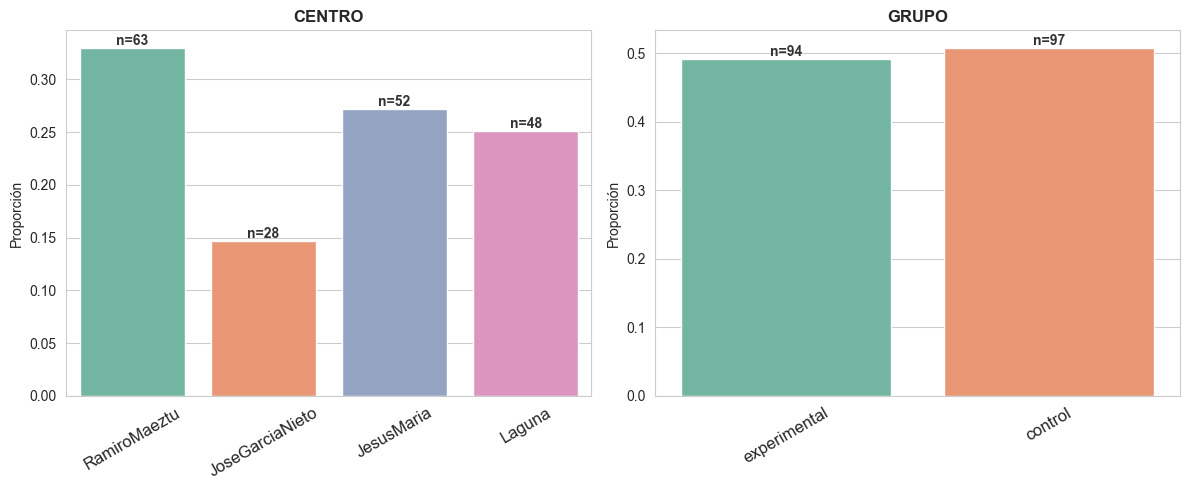

In [12]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = context_cols, 
    max_cols=3, 
    palette="Set2",
)

### Métricas de Rendimiento Forms

#### TC-Hake

In [13]:
hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' not in col and "tc" in col]
units_hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' in col and "tc" in col]

hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' not in col and 'mejora' not in col and "tc" in col]
units_hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' in col and 'mejora' not in col and "tc" in col]

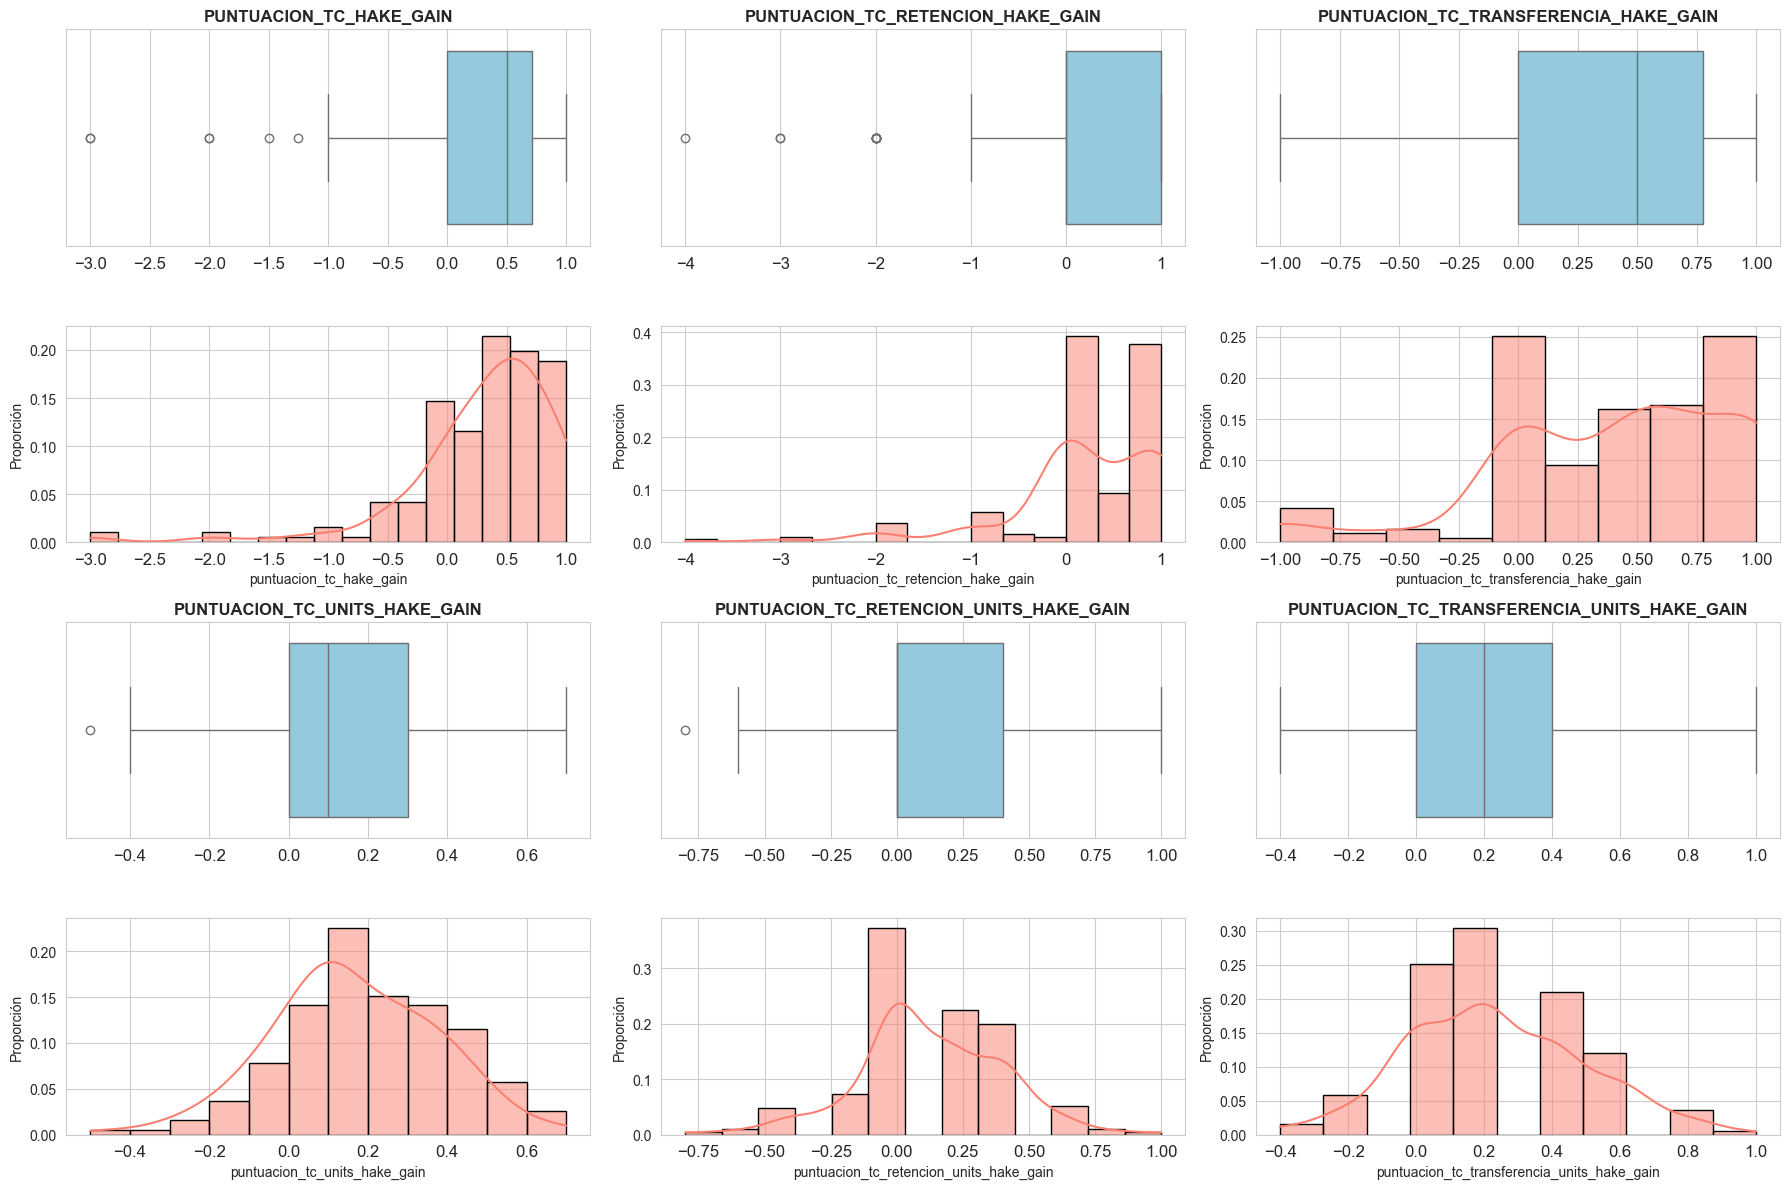

In [14]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = hake_gain_quant_cols + units_hake_gain_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

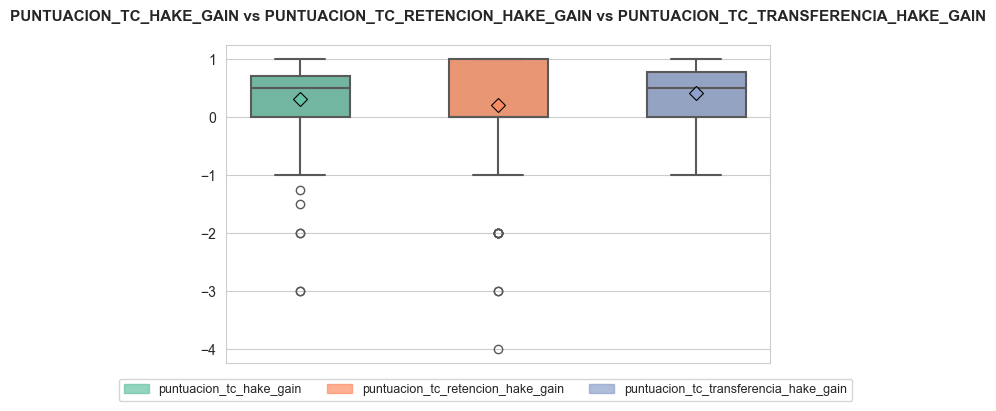

In [15]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    showfliers=True,
    title=False,
    labelbottom=False
)

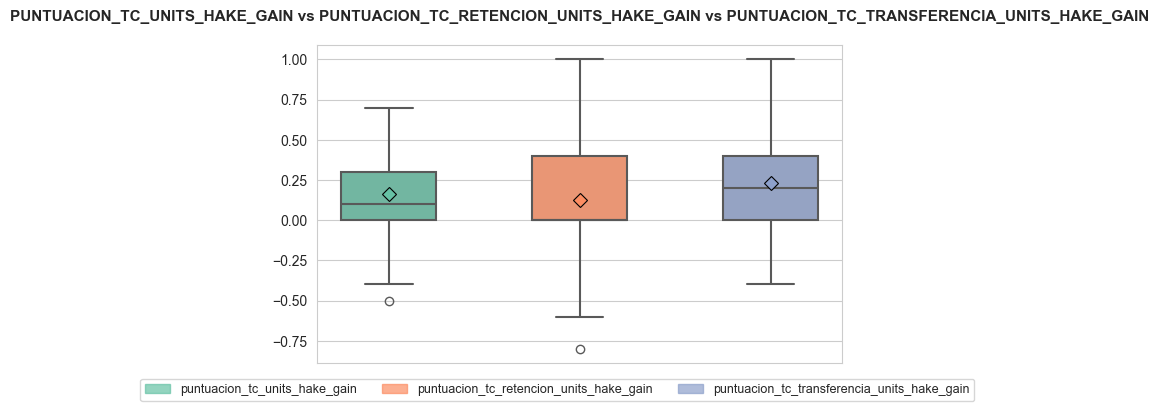

In [16]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        units_hake_gain_quant_cols
    ],
    showfliers=True,
    title=False,
    labelbottom=False
)

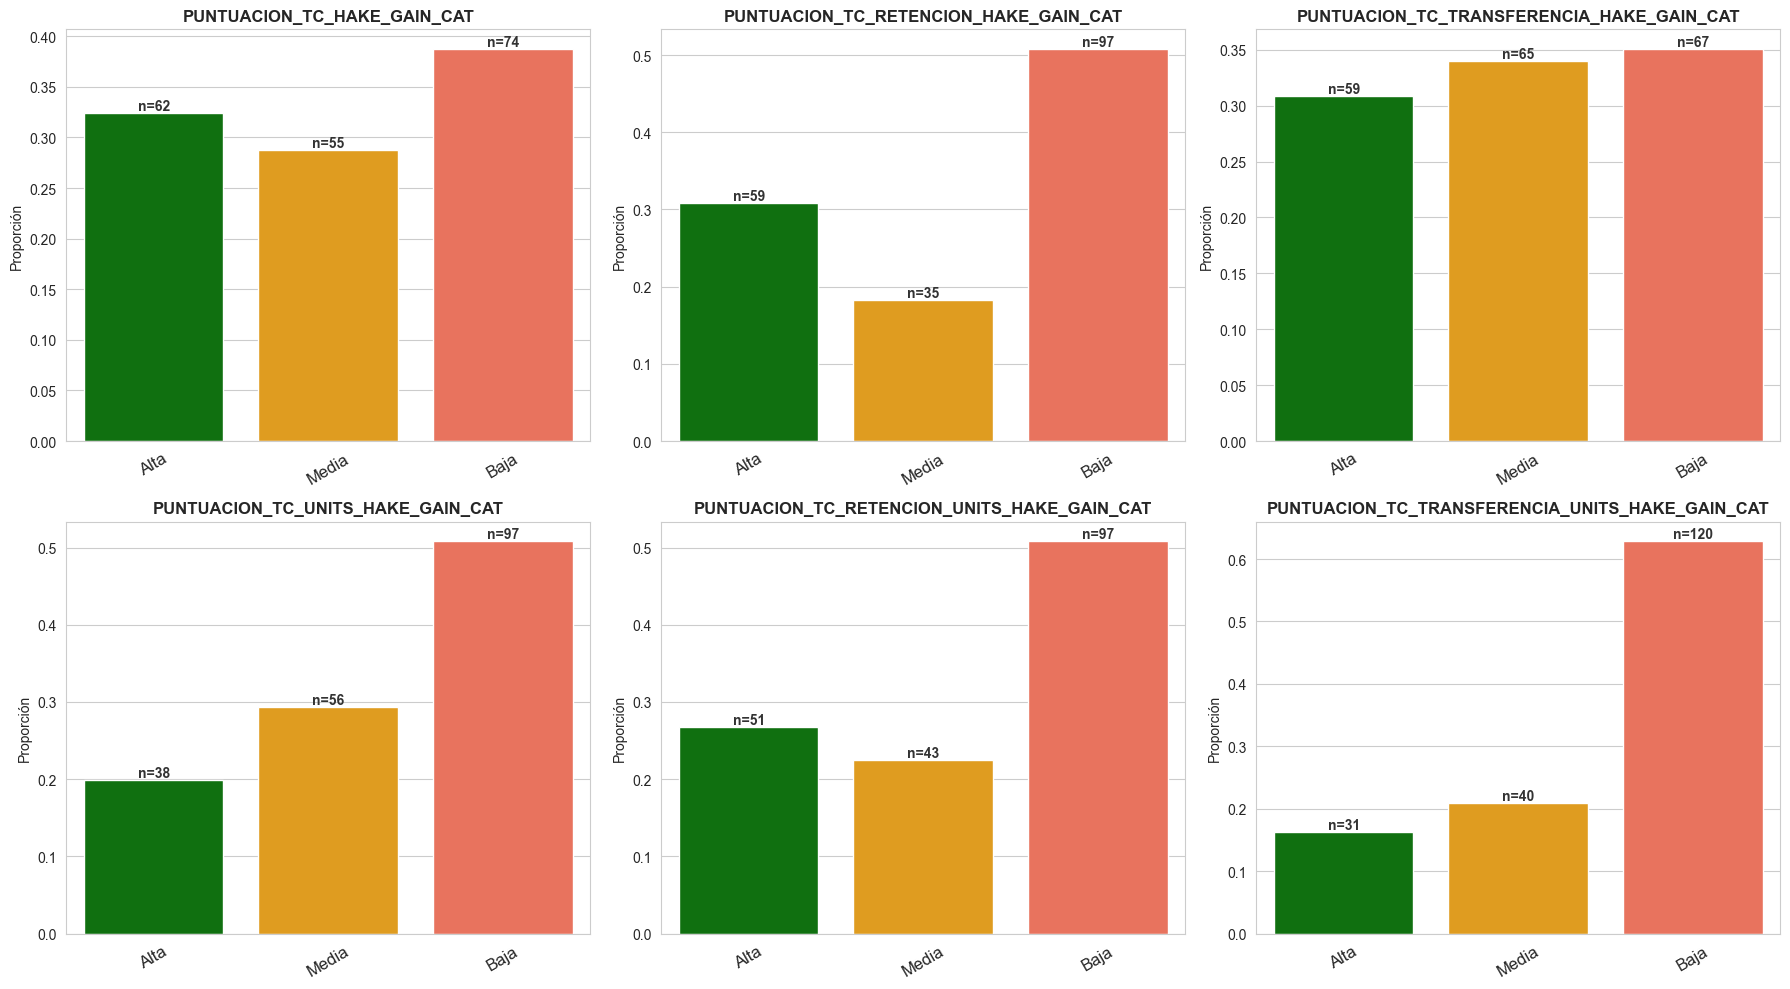

In [17]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = hake_gain_cat_cols + units_hake_gain_cat_cols, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
    max_cols=3
)

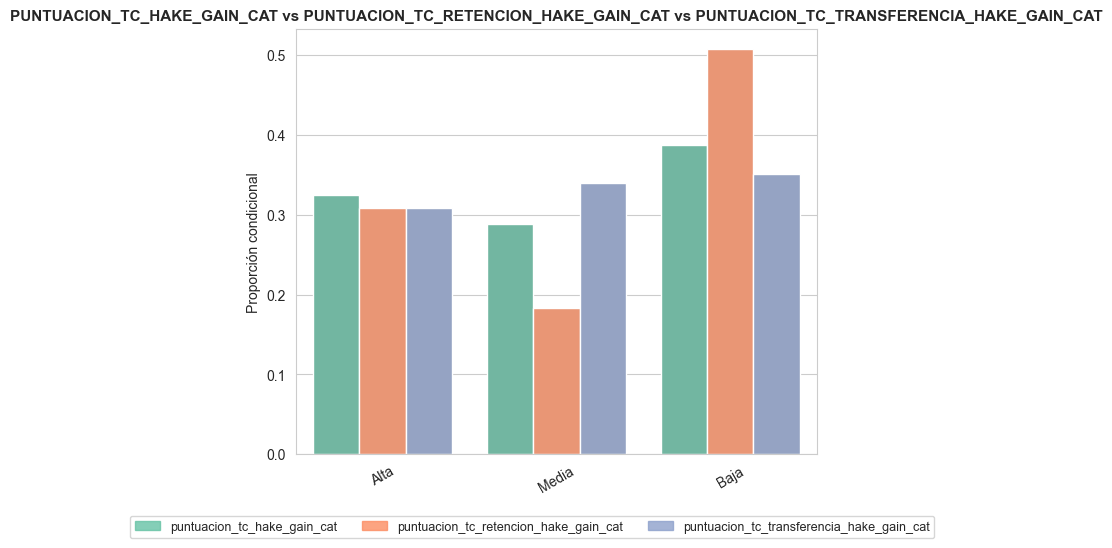

In [18]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        hake_gain_cat_cols
    ], 
    title=False,
    bbox_to_anchor=(0.5,-0.1),
    order=['Alta', 'Media', 'Baja']
)


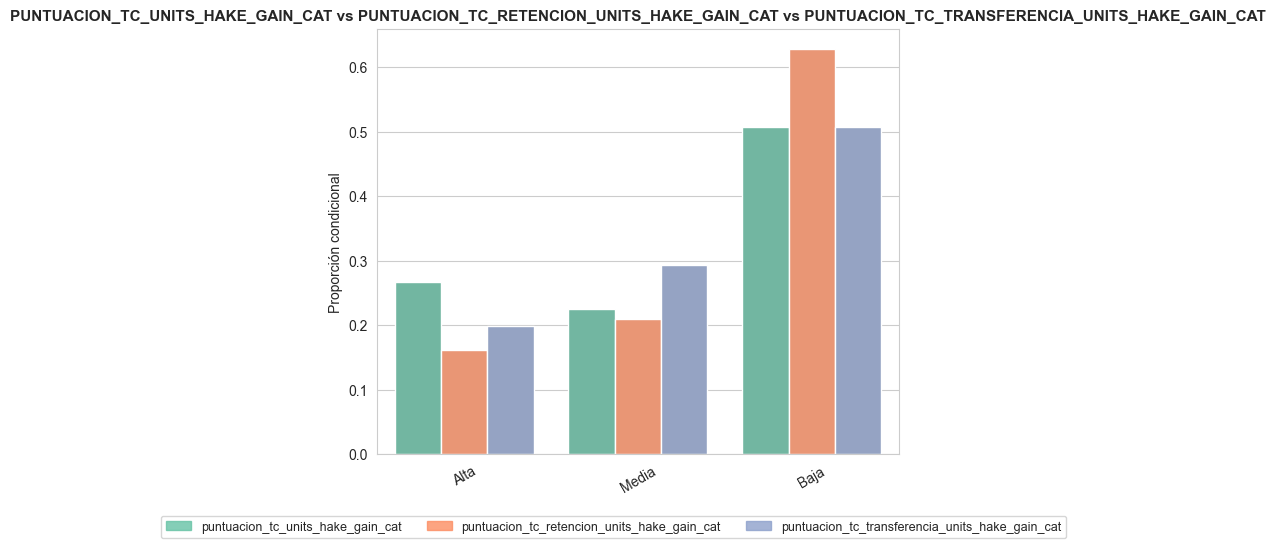

In [19]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        units_hake_gain_cat_cols
    ], 
    title=False,
    bbox_to_anchor=(0.5,-0.1),
    order=['Alta', 'Media', 'Baja']
)


#### TC-Pre-Post

In [20]:
tc_pre_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'pre' in col]
tc_pre_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'pre' in col and 'trad' not in col]

tc_post_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'post' in col]
tc_post_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'post' in col and  'trad' not in col] 

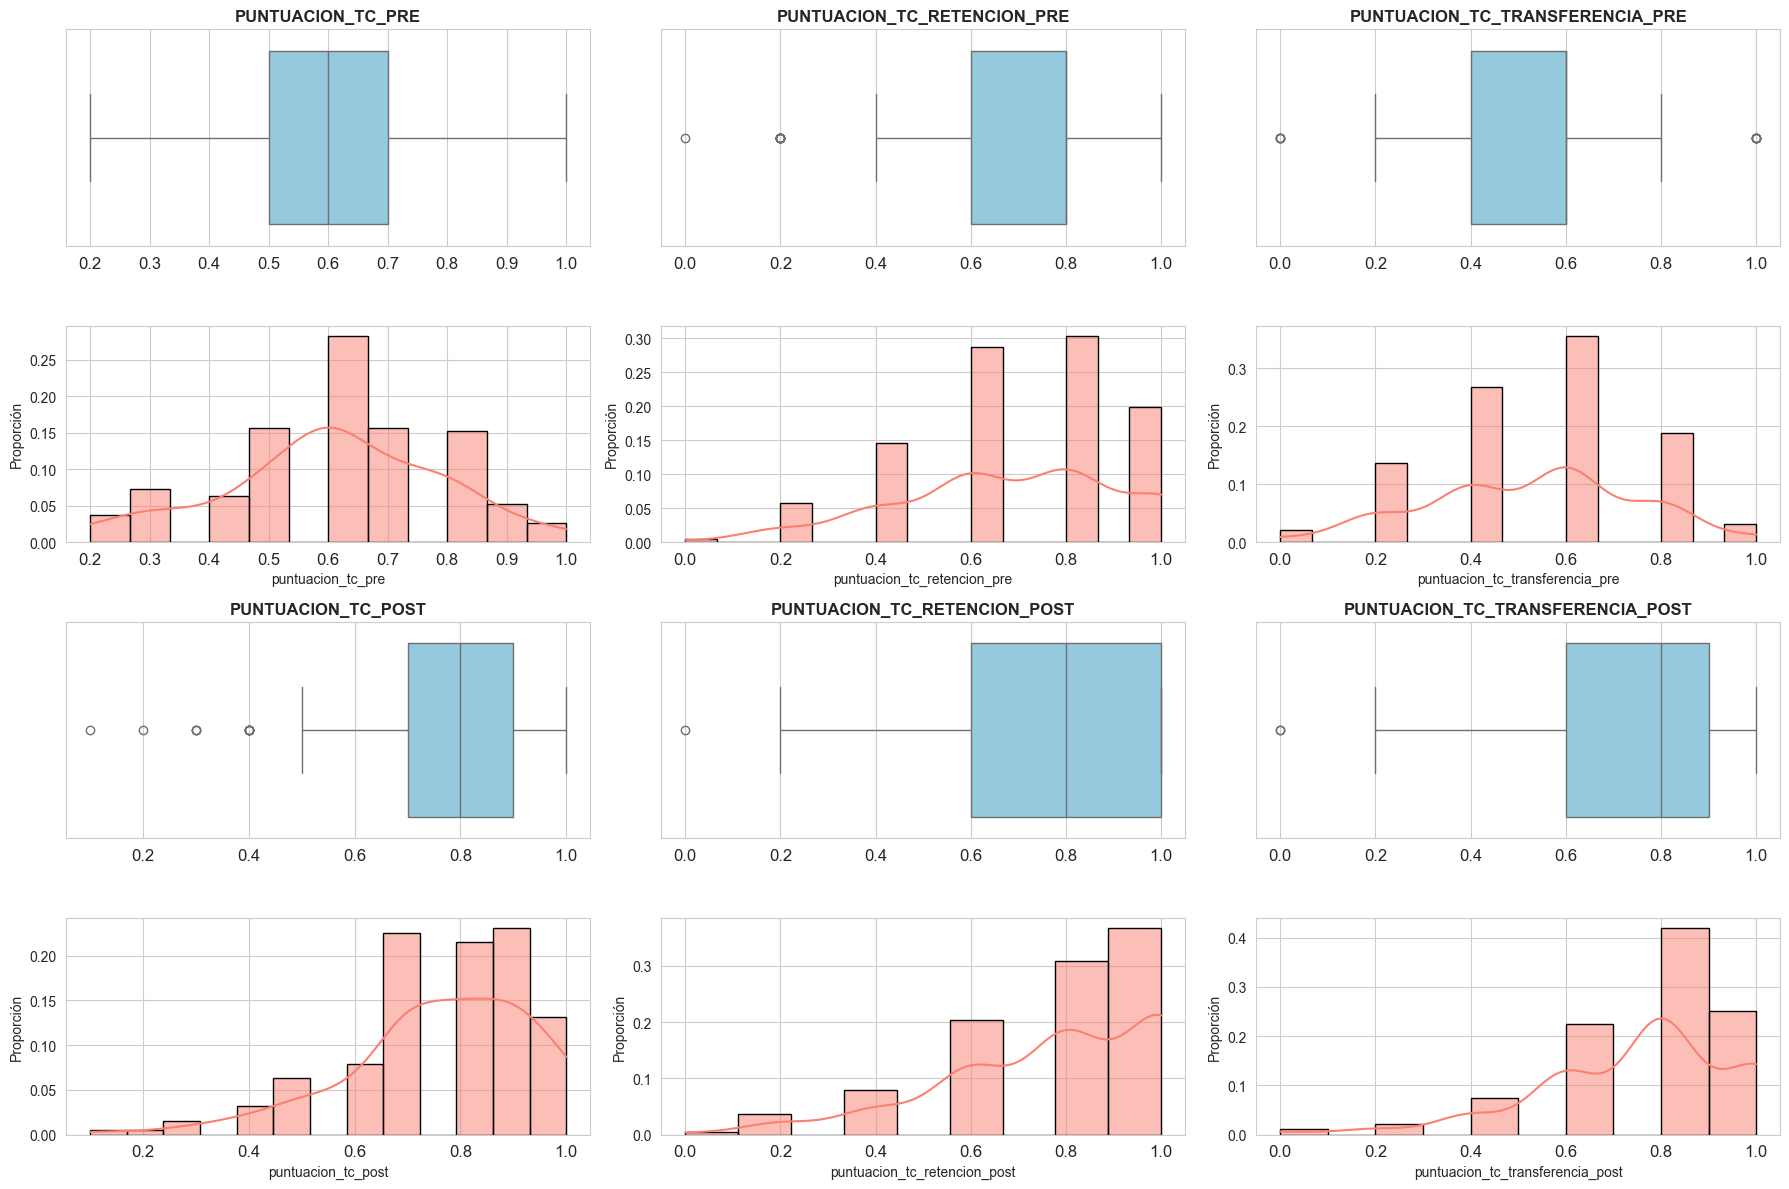

In [21]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = tc_pre_quant_cols + tc_post_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

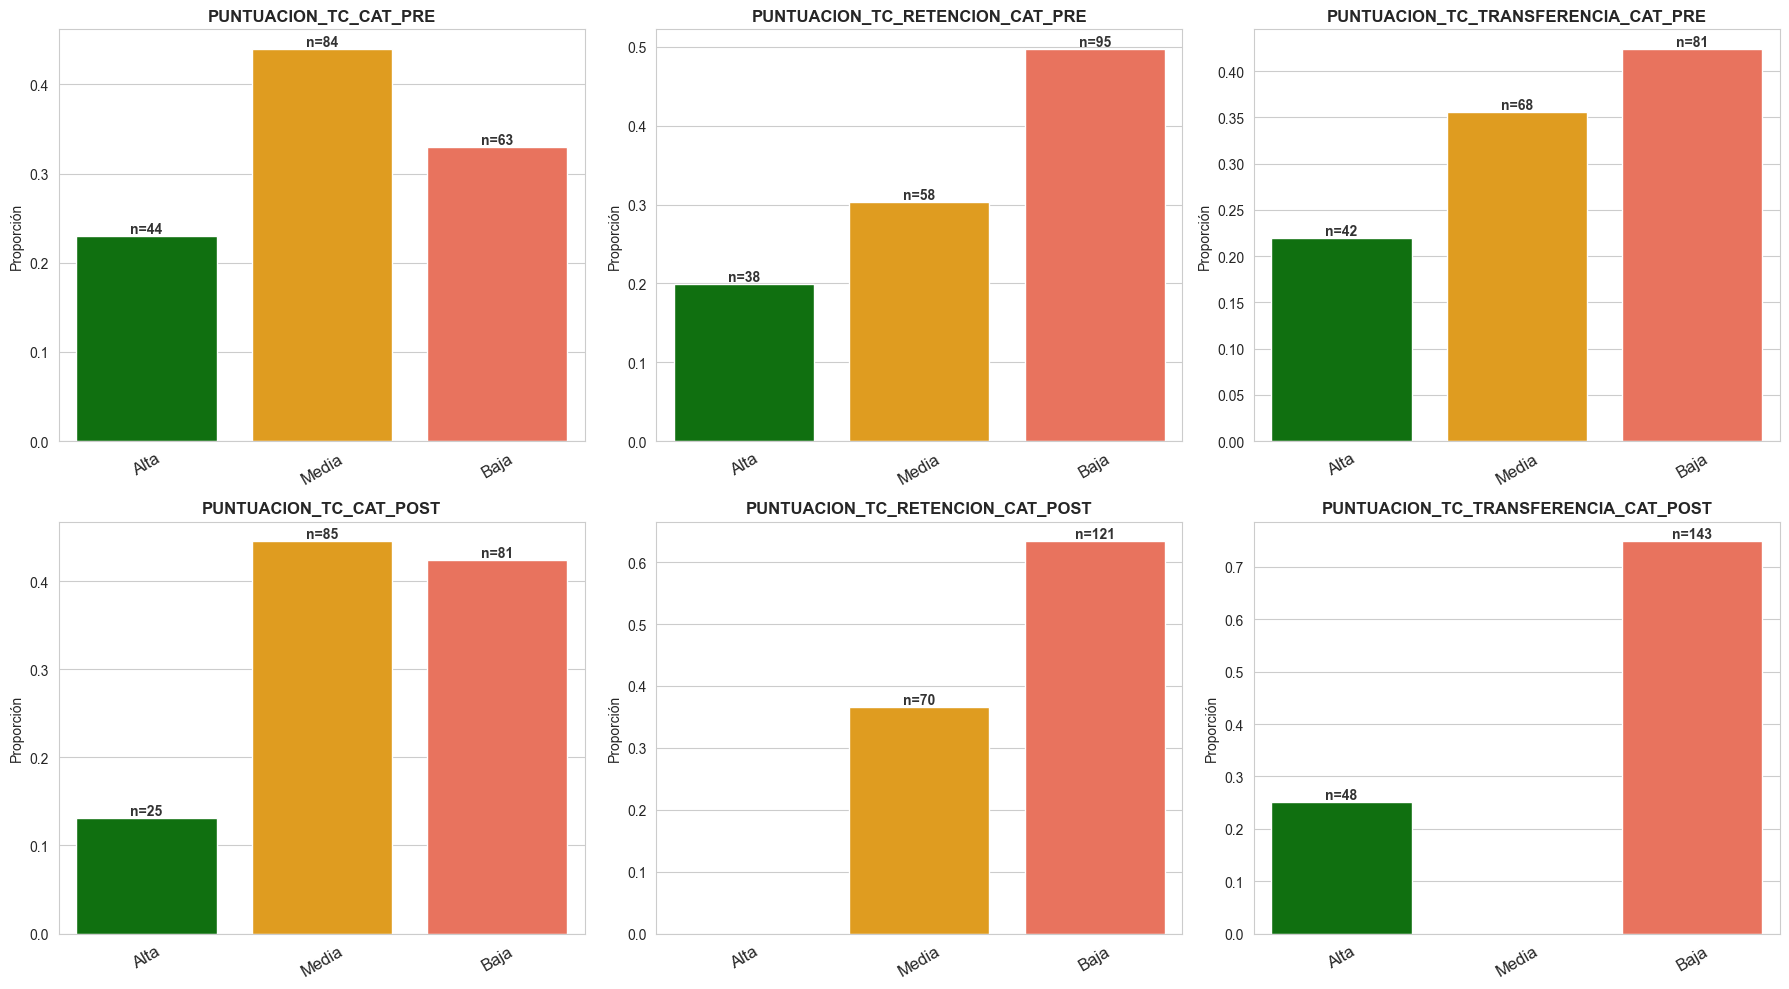

In [22]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = tc_pre_cat_cols + tc_post_cat_cols, 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'}
)

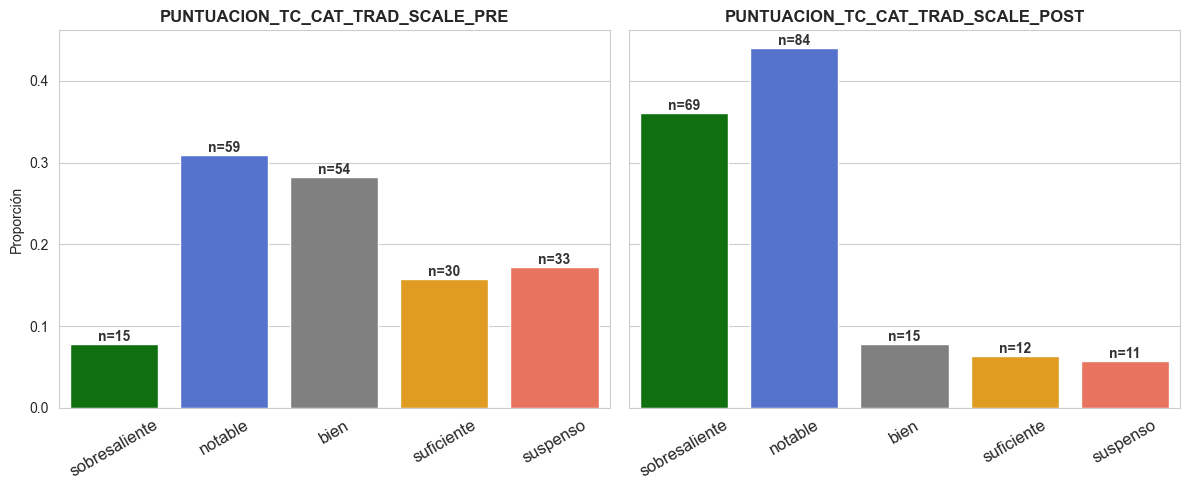

In [23]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = ['puntuacion_tc_cat_trad_scale_pre', 'puntuacion_tc_cat_trad_scale_post'], 
    max_cols=3, 
    order=['sobresaliente', 'notable', 'bien', 'suficiente', 'suspenso'],
    palette={'sobresaliente': 'green', 'notable': 'royalblue', 'bien': 'gray', 'suficiente': 'orange', 'suspenso': 'tomato'},
    sharey=True
)

#### TC-Pre-Post Mejora

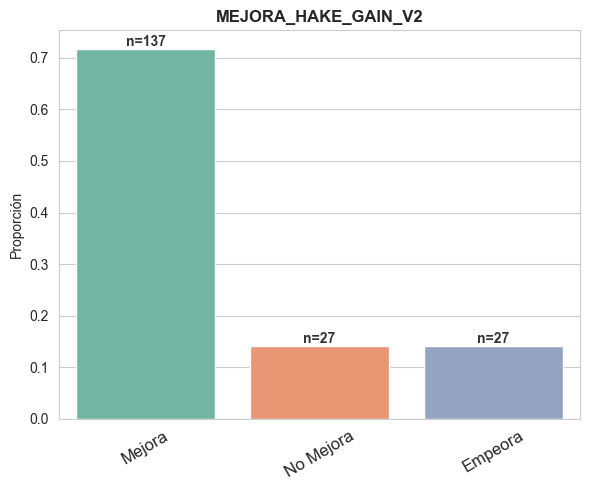

In [24]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = ['mejora_hake_gain_v2'], 
    max_cols=3, 
)

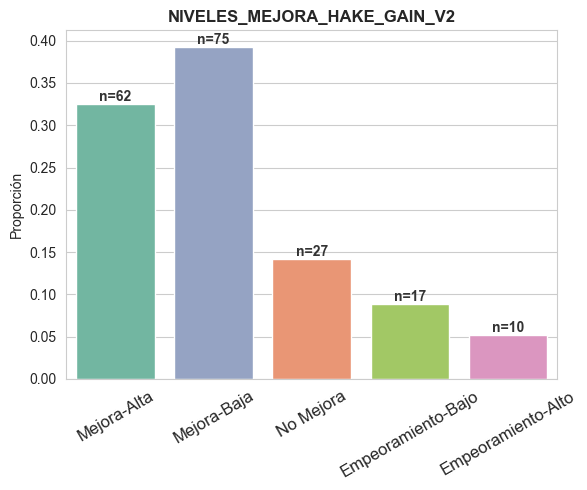

In [25]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = ['niveles_mejora_hake_gain_v2'], 
    max_cols=3, 
    order=['Mejora-Alta', 'Mejora-Baja', 'No Mejora', 'Empeoramiento-Bajo', 'Empeoramiento-Alto'],
)

#### TA-Pre-Post

In [26]:
ta_quant_cols = [col for col in forms_quant_cols if 'ta_' in col]
ta_cat_cols = [col for col in forms_cat_cols if 'ta_' in col]

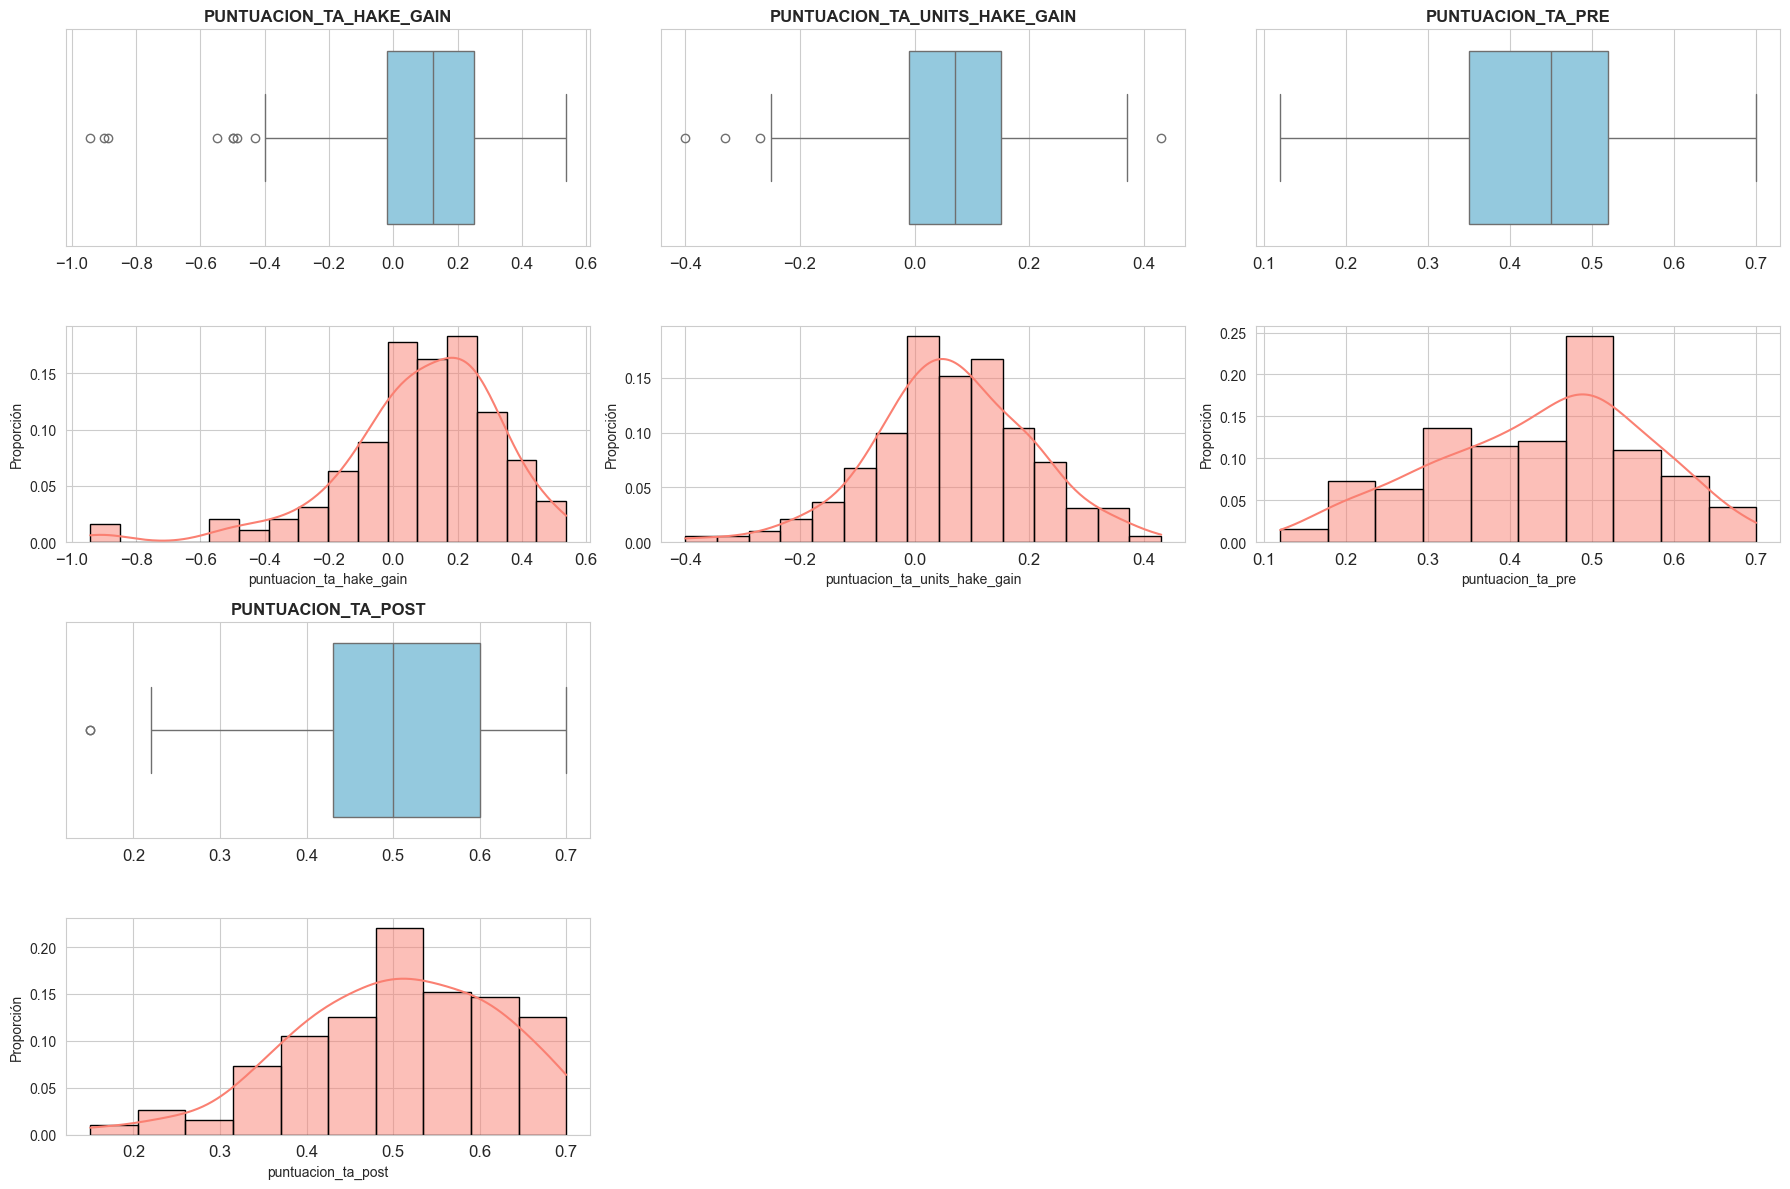

In [27]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = ta_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

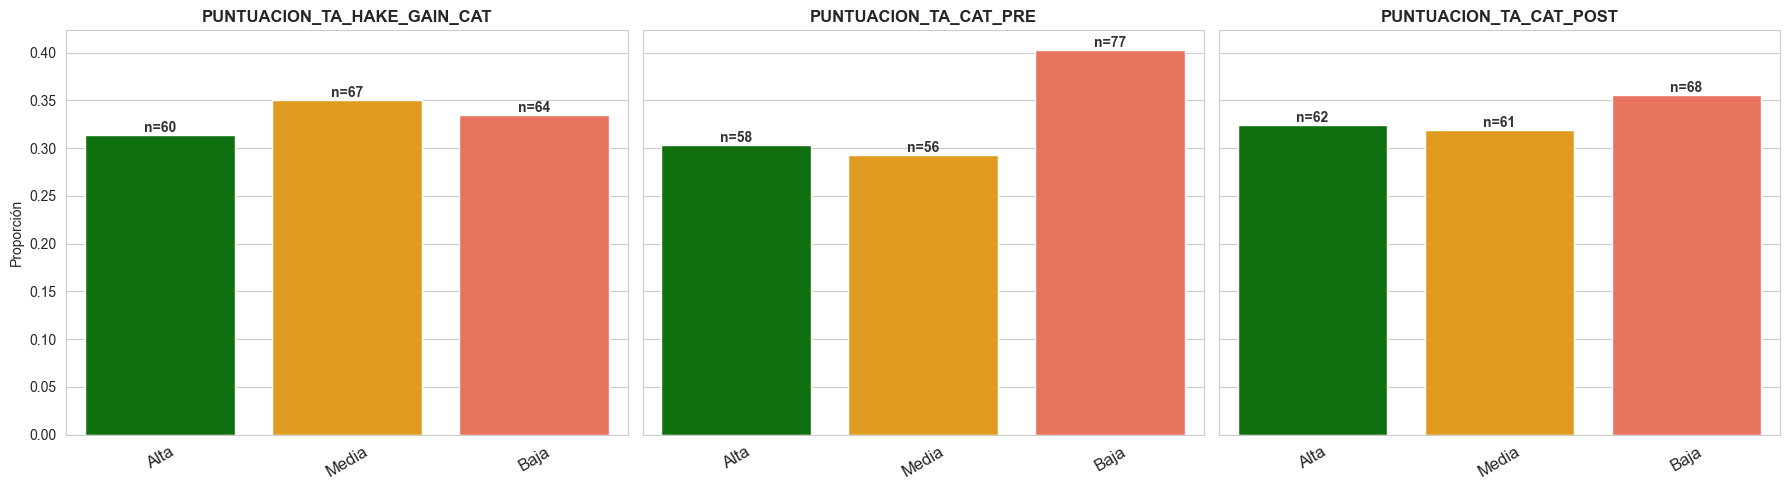

In [28]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = ta_cat_cols, 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
    sharey=True
)

#### TCC-Post

In [29]:
tcc_quant_cols = [col for col in forms_quant_cols if 'tcc_' in col]
tcc_cat_cols = [col for col in forms_cat_cols if 'tcc_' in col]

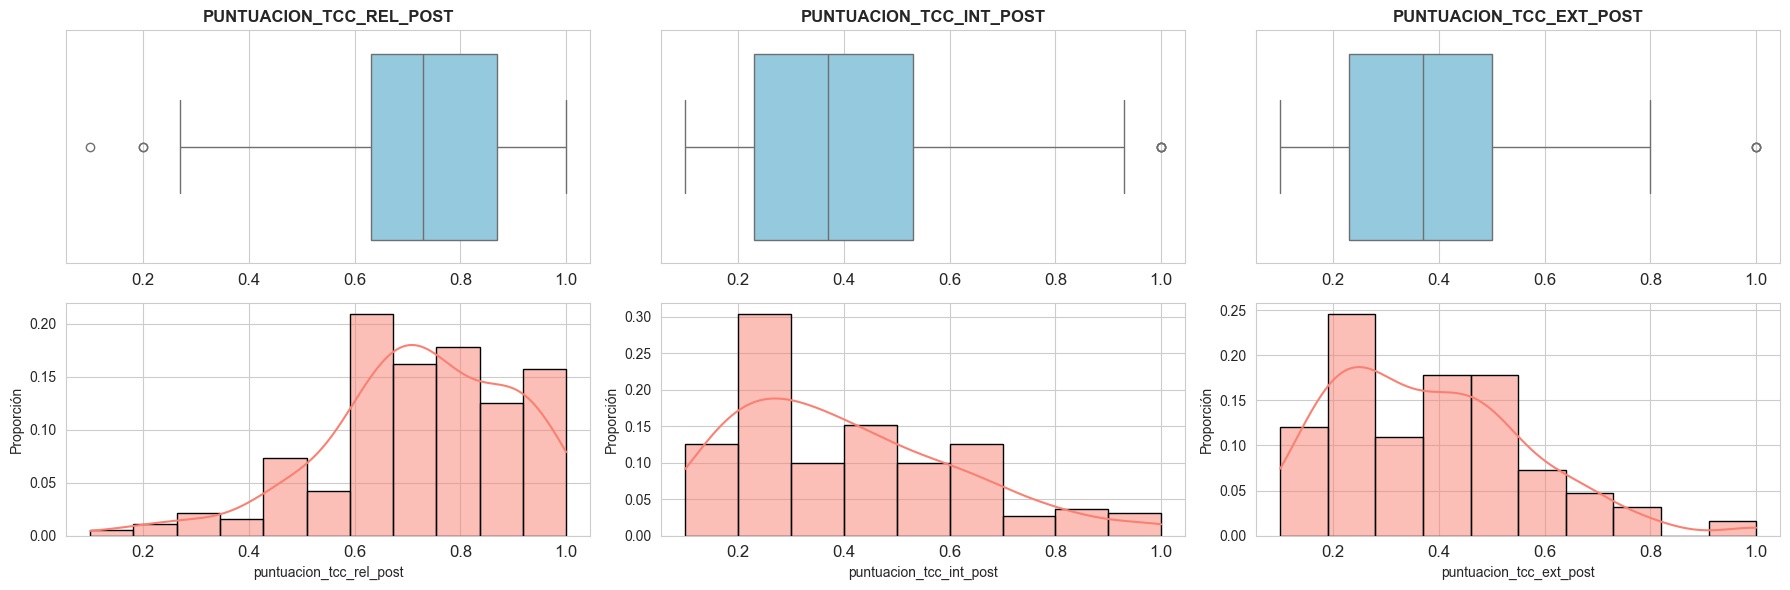

In [30]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = tcc_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

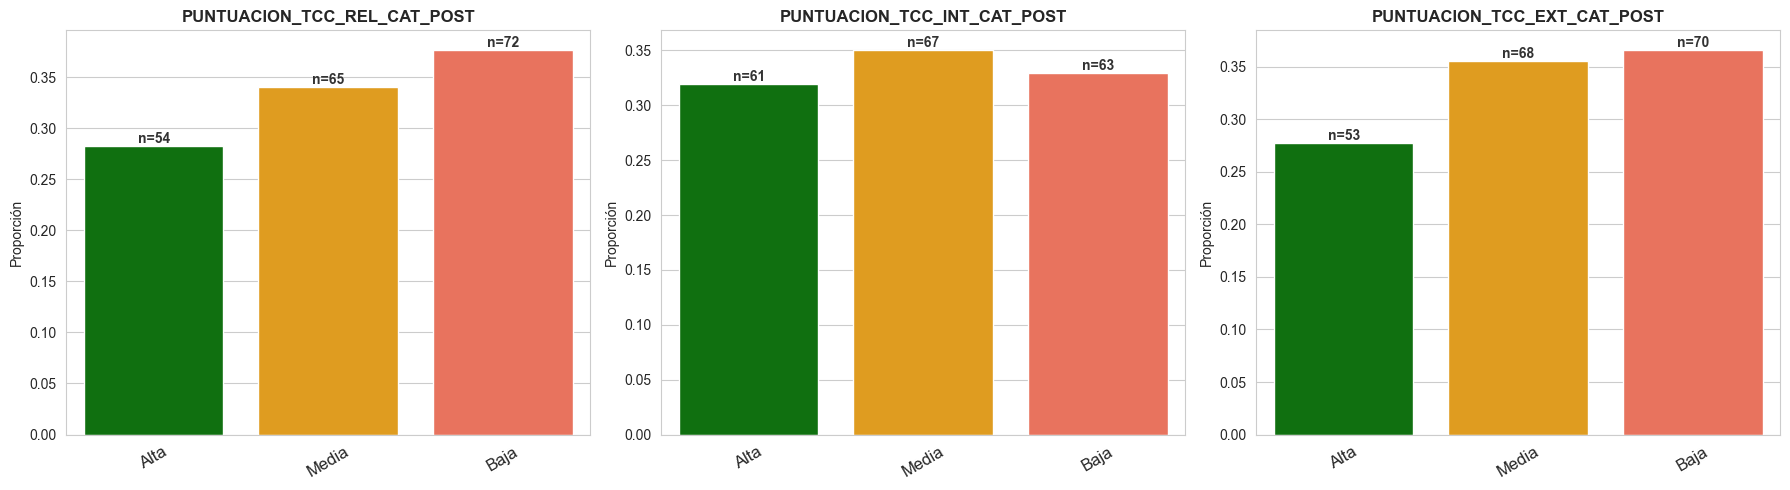

In [31]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = tcc_cat_cols, 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
)

### Métricas Interacciones Herramienta

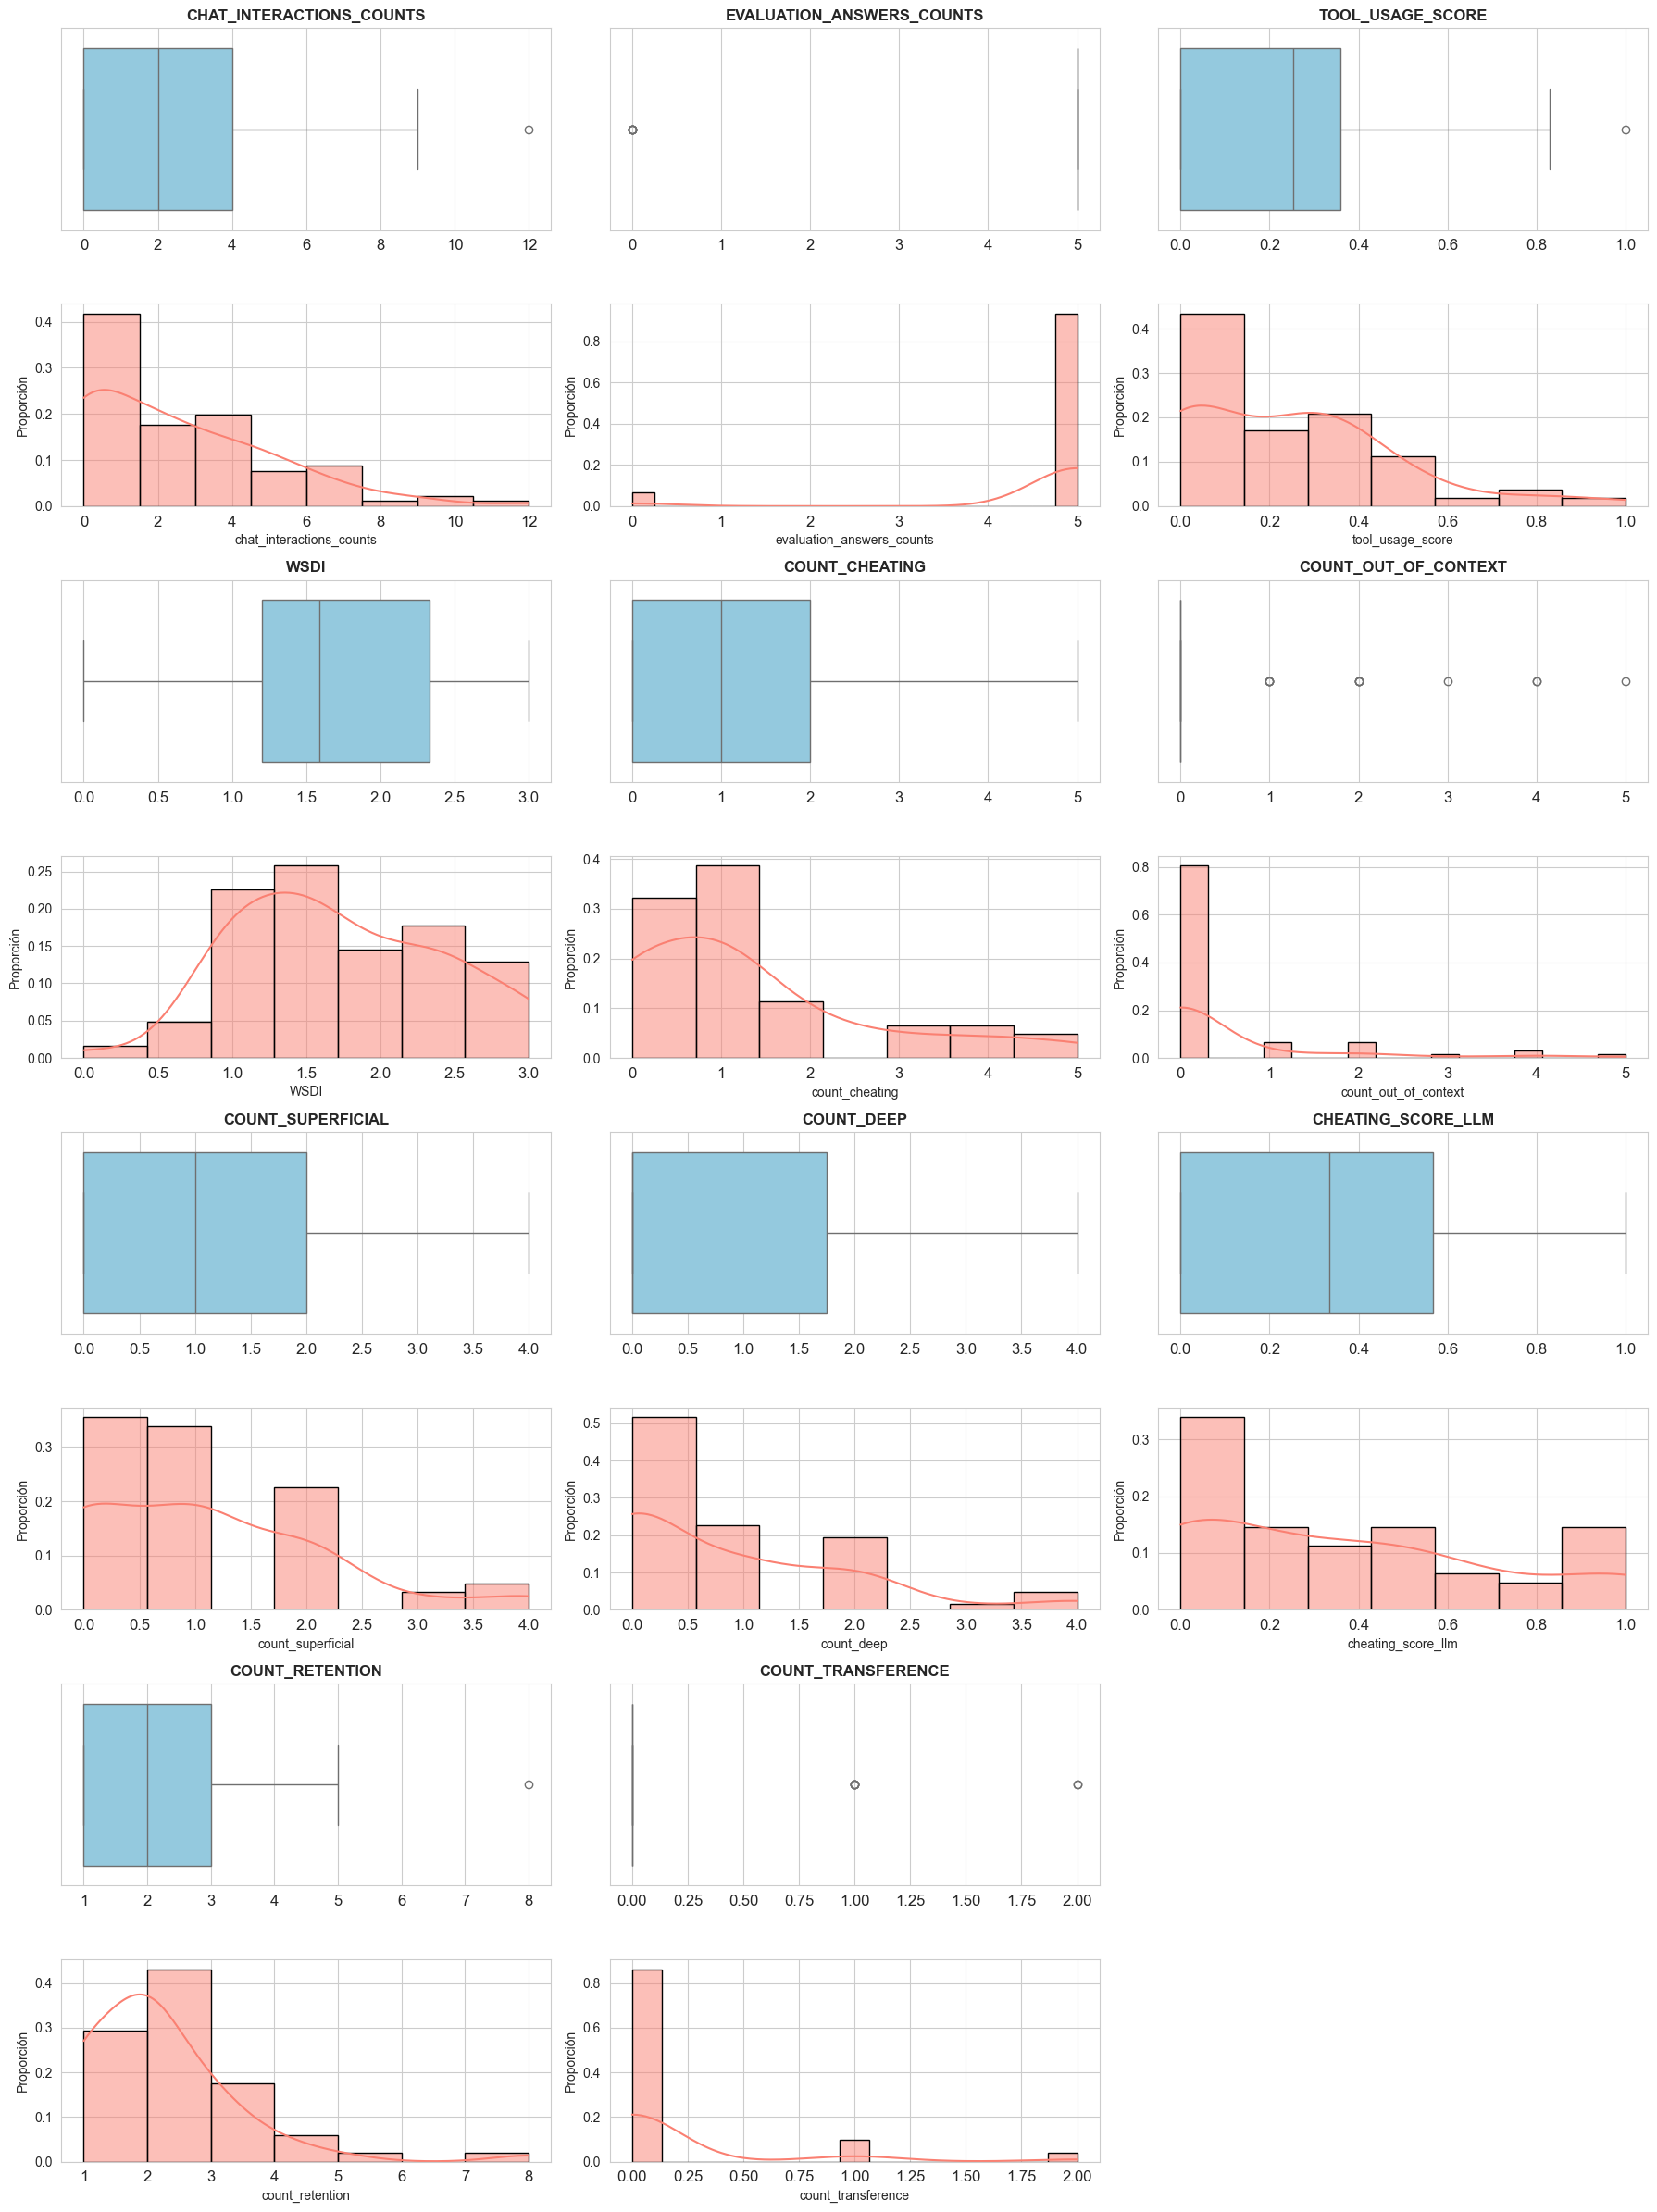

In [32]:
plot_quant_distribution(
    df = forms_interactions_df.filter(
        pl.col('grupo') == 'experimental'
    ), 
    quant_cols = chats_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon")


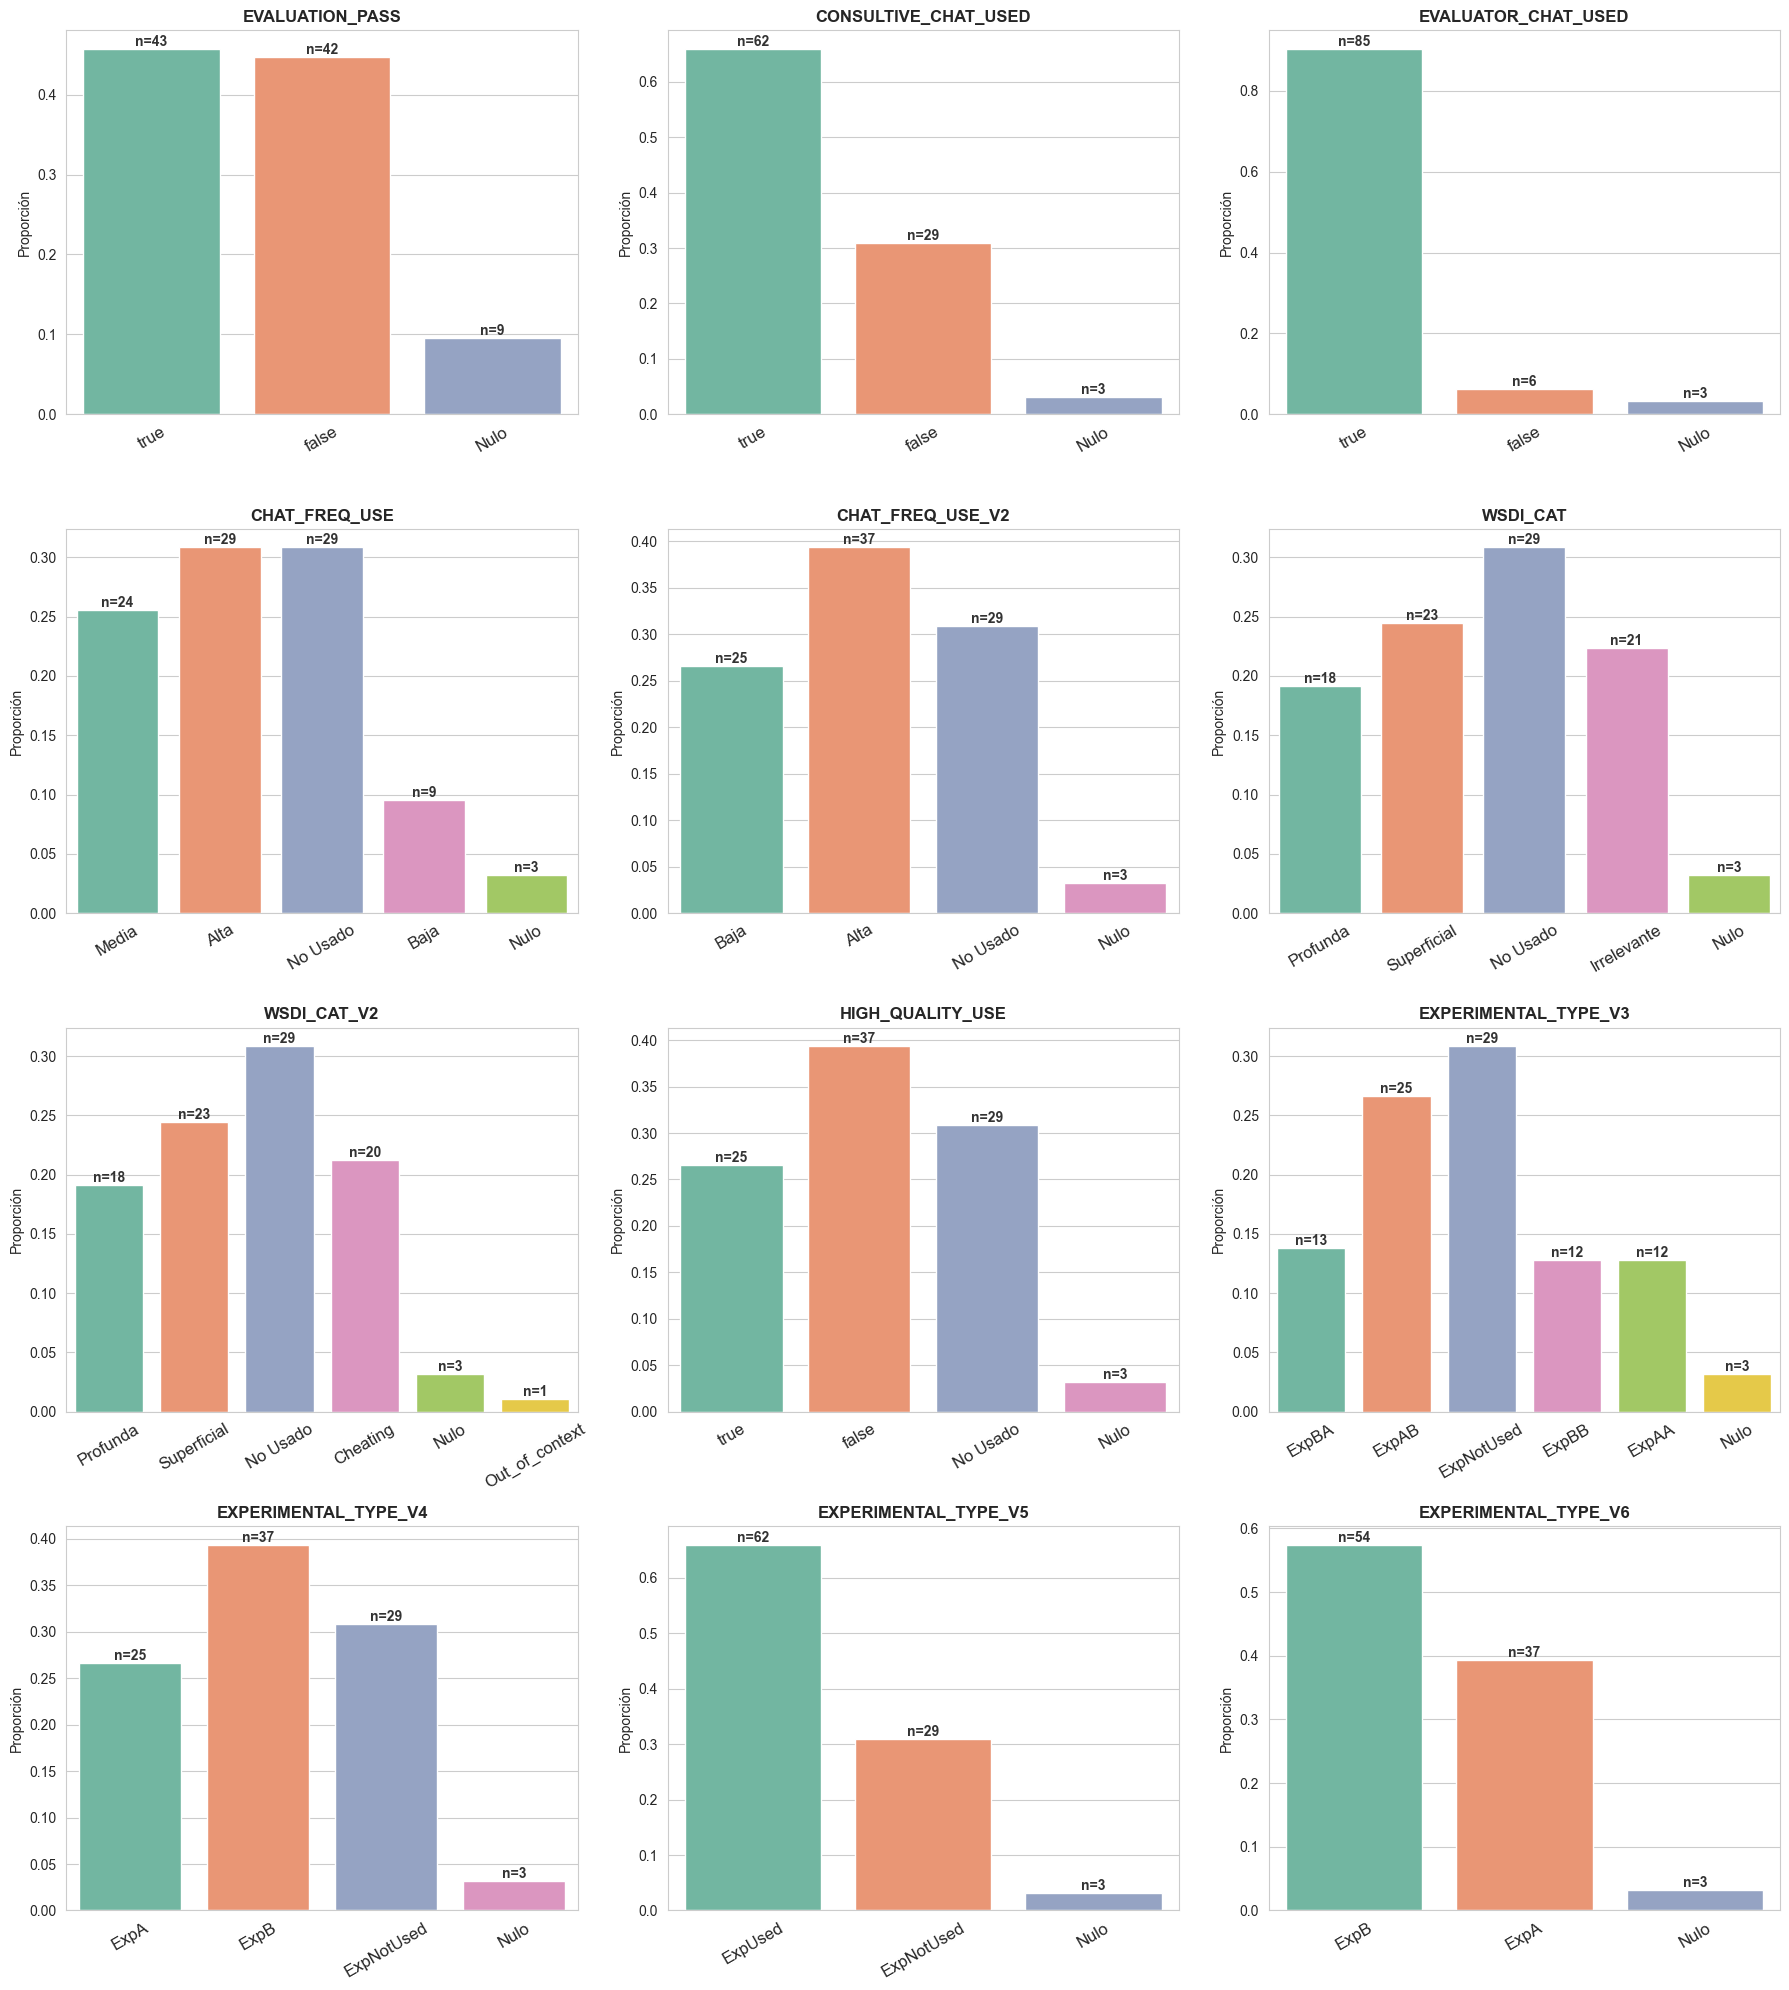

In [33]:
plot_cat_distribution(
    df = forms_interactions_df.filter(
        pl.col('grupo') == 'experimental'
    ), 
    cat_cols = [x for x in chats_cat_cols if x not in ['experimental_type_v1', 'experimental_type_v2']], 
    max_cols=3, 
    palette="Set2"
)

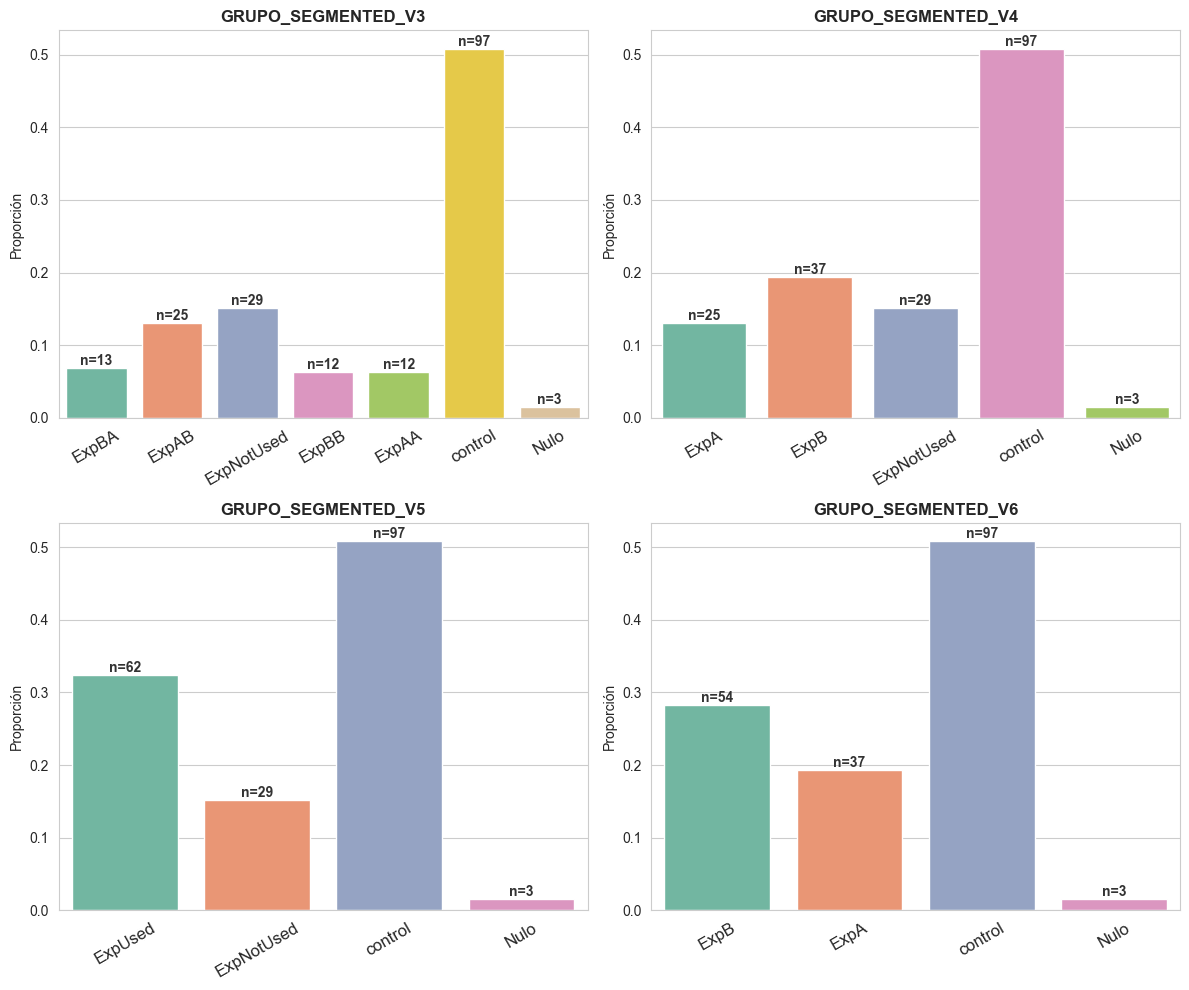

In [ ]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [
        "grupo",
        'grupo_segmented_v3',
        'grupo_segmented_v4',
        'grupo_segmented_v5',
        'grupo_segmented_v6'
    ], 
    max_cols=2, 
    palette="Set2"
)

### Análisis Cruzado 

#### Filtrado de participantes problematicos

In [35]:
q25 = forms_interactions_df['puntuacion_tc_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['puntuacion_tc_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('puntuacion_tc_hake_gain') < outliers_lower_bound
)['id', 'grupo', 'puntuacion_tc_pre', 'puntuacion_tc_post', 'puntuacion_tc_units_hake_gain', 'puntuacion_tc_hake_gain']

id,grupo,puntuacion_tc_pre,puntuacion_tc_post,puntuacion_tc_units_hake_gain,puntuacion_tc_hake_gain
str,str,f64,f64,f64,f64
"""RamiroMaeztu-86g""","""experimental""",0.8,0.5,-0.3,-1.5
"""RamiroMaeztu-4bc""","""experimental""",0.9,0.6,-0.3,-3.0
"""JesusMaria-ub4""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-yxb""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25
"""Laguna-chk""","""experimental""",0.9,0.6,-0.3,-3.0


In [36]:
q25 = forms_interactions_df['puntuacion_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['puntuacion_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('puntuacion_tc_units_hake_gain') < outliers_lower_bound
)['id', 'grupo', 'puntuacion_tc_pre', 'puntuacion_tc_post', 'puntuacion_tc_units_hake_gain', 'puntuacion_tc_hake_gain']

id,grupo,puntuacion_tc_pre,puntuacion_tc_post,puntuacion_tc_units_hake_gain,puntuacion_tc_hake_gain
str,str,f64,f64,f64,f64
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25


In [37]:
forms_interactions_df.filter(
    pl.col('puntuacion_tc_pre') == 1
)['id', 'grupo', 'puntuacion_tc_pre', 'puntuacion_tc_post', 'puntuacion_tc_units_hake_gain', 'puntuacion_tc_hake_gain']

id,grupo,puntuacion_tc_pre,puntuacion_tc_post,puntuacion_tc_units_hake_gain,puntuacion_tc_hake_gain
str,str,f64,f64,f64,f64
"""JoseGarciaNieto-lp9""","""control""",1.0,0.9,0.0,0.0
"""JesusMaria-86o""","""control""",1.0,1.0,0.0,0.0
"""Laguna-o61""","""experimental""",1.0,0.5,0.0,0.0
"""Laguna-yno""","""experimental""",1.0,0.8,0.0,0.0
"""Laguna-9wq""","""experimental""",1.0,0.9,0.0,0.0


In [38]:
forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id', 'grupo', 'puntuacion_tc_pre', 'puntuacion_tc_post', 'puntuacion_tc_units_hake_gain', 'puntuacion_tc_hake_gain', 'chat_freq_use']

id,grupo,puntuacion_tc_pre,puntuacion_tc_post,puntuacion_tc_units_hake_gain,puntuacion_tc_hake_gain,chat_freq_use
str,str,f64,f64,f64,f64,str
"""JesusMaria-nre""","""experimental""",0.9,0.8,-0.1,-1.0,null
"""JesusMaria-3ci""","""experimental""",0.7,0.7,0.0,0.0,null
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25,null


In [ ]:
problematic_ids = forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id'].to_list()

q25 = forms_interactions_df['puntuacion_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['puntuacion_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr
problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('puntuacion_tc_units_hake_gain') < outliers_lower_bound
)['id'].to_list()

problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('puntuacion_tc_pre') == 1
)['id'].to_list()

problematic_ids = list(set(problematic_ids))

forms_interactions_df = forms_interactions_df.filter(~pl.col('id').is_in(problematic_ids))

no_efecto_techo_df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)).filter(
    pl.col("puntuacion_tc_cat_trad_scale_v2_pre") == "suspenso-suficiente-bien"	
)

In [40]:
problematic_ids

['JesusMaria-86o',
 'Laguna-yno',
 'Laguna-o61',
 'JoseGarciaNieto-lp9',
 'JesusMaria-nre',
 'JesusMaria-3ci',
 'JesusMaria-33y',
 'Laguna-9wq']

In [41]:
len(problematic_ids)

8

#### TC-Hake - Grupos (Control-Experimental)

In [42]:
for col in hake_gain_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df, 
            cols =  [col], 
            group_by = 'grupo'
        ).sort('grupo')
    )

PUNTUACION_TC_HAKE_GAIN


grupo,puntuacion_tc_hake_gain_mean,puntuacion_tc_hake_gain_std,puntuacion_tc_hake_gain_q25,puntuacion_tc_hake_gain_median,puntuacion_tc_hake_gain_q75,puntuacion_tc_hake_gain_min,puntuacion_tc_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.413747,0.55716,0.25,0.5,0.75,-2.0,1.0
"""experimental""",0.257193,0.685516,0.0,0.4,0.6,-3.0,1.0


PUNTUACION_TC_RETENCION_HAKE_GAIN


grupo,puntuacion_tc_retencion_hake_gain_mean,puntuacion_tc_retencion_hake_gain_std,puntuacion_tc_retencion_hake_gain_q25,puntuacion_tc_retencion_hake_gain_median,puntuacion_tc_retencion_hake_gain_q75,puntuacion_tc_retencion_hake_gain_min,puntuacion_tc_retencion_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.307926,0.810249,0.0,0.5,1.0,-4.0,1.0
"""experimental""",0.167625,0.824526,0.0,0.0,1.0,-3.0,1.0


PUNTUACION_TC_TRANSFERENCIA_HAKE_GAIN


grupo,puntuacion_tc_transferencia_hake_gain_mean,puntuacion_tc_transferencia_hake_gain_std,puntuacion_tc_transferencia_hake_gain_q25,puntuacion_tc_transferencia_hake_gain_median,puntuacion_tc_transferencia_hake_gain_q75,puntuacion_tc_transferencia_hake_gain_min,puntuacion_tc_transferencia_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.491779,0.48097,0.0,0.5,1.0,-1.0,1.0
"""experimental""",0.378216,0.52797,0.0,0.5,0.75,-1.0,1.0


In [43]:
for col in units_hake_gain_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df, 
            cols =  [col], 
            group_by = 'grupo'
        ).sort('grupo')
    )

PUNTUACION_TC_UNITS_HAKE_GAIN


grupo,puntuacion_tc_units_hake_gain_mean,puntuacion_tc_units_hake_gain_std,puntuacion_tc_units_hake_gain_q25,puntuacion_tc_units_hake_gain_median,puntuacion_tc_units_hake_gain_q75,puntuacion_tc_units_hake_gain_min,puntuacion_tc_units_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.195789,0.206241,0.1,0.2,0.3,-0.2,0.7
"""experimental""",0.147727,0.204533,0.0,0.1,0.3,-0.4,0.7


PUNTUACION_TC_RETENCION_UNITS_HAKE_GAIN


grupo,puntuacion_tc_retencion_units_hake_gain_mean,puntuacion_tc_retencion_units_hake_gain_std,puntuacion_tc_retencion_units_hake_gain_q25,puntuacion_tc_retencion_units_hake_gain_median,puntuacion_tc_retencion_units_hake_gain_q75,puntuacion_tc_retencion_units_hake_gain_min,puntuacion_tc_retencion_units_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.16,0.265137,0.0,0.2,0.4,-0.8,0.8
"""experimental""",0.109091,0.274443,0.0,0.0,0.2,-0.6,1.0


PUNTUACION_TC_TRANSFERENCIA_UNITS_HAKE_GAIN


grupo,puntuacion_tc_transferencia_units_hake_gain_mean,puntuacion_tc_transferencia_units_hake_gain_std,puntuacion_tc_transferencia_units_hake_gain_q25,puntuacion_tc_transferencia_units_hake_gain_median,puntuacion_tc_transferencia_units_hake_gain_q75,puntuacion_tc_transferencia_units_hake_gain_min,puntuacion_tc_transferencia_units_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.267368,0.251989,0.0,0.2,0.4,-0.2,1.0
"""experimental""",0.220455,0.26616,0.0,0.2,0.4,-0.4,0.8


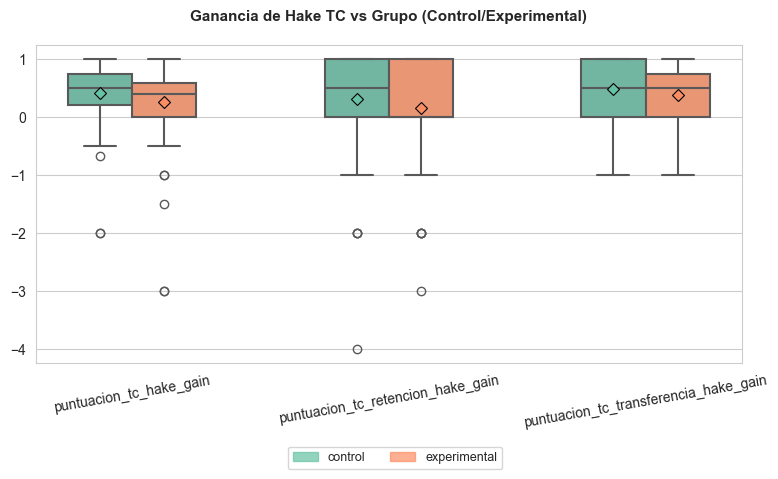

In [44]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo',
    showfliers=True,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control/Experimental)',
    figsize=(8,4)
)

- Diferencias no significativas (a simple vista) pero si que se observa una ligera ganancia de hake superior en el control respecto experimental, y esta diferencia se mantienen tanto en retencion como en transferencia.

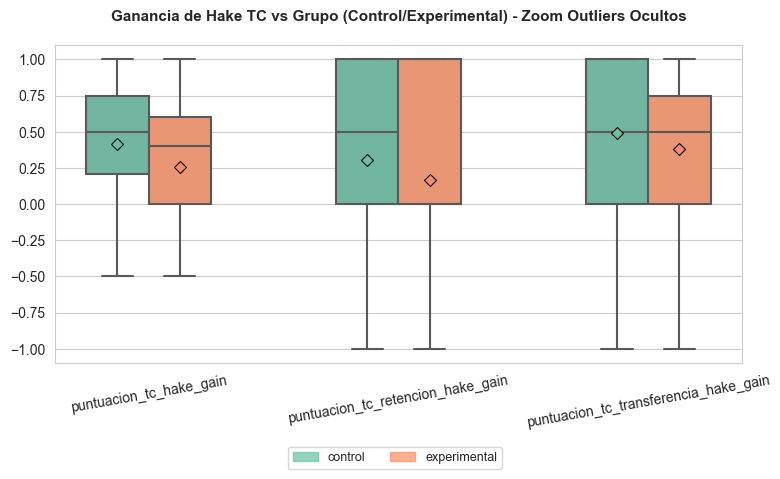

In [45]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control/Experimental) - Zoom Outliers Ocultos',
    figsize=(8,4)
)

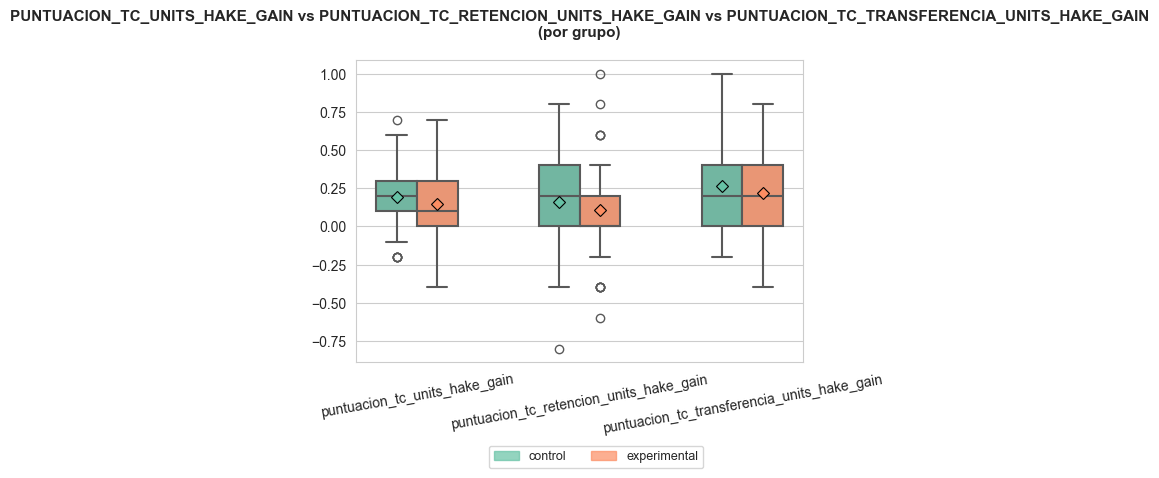

In [46]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        units_hake_gain_quant_cols
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

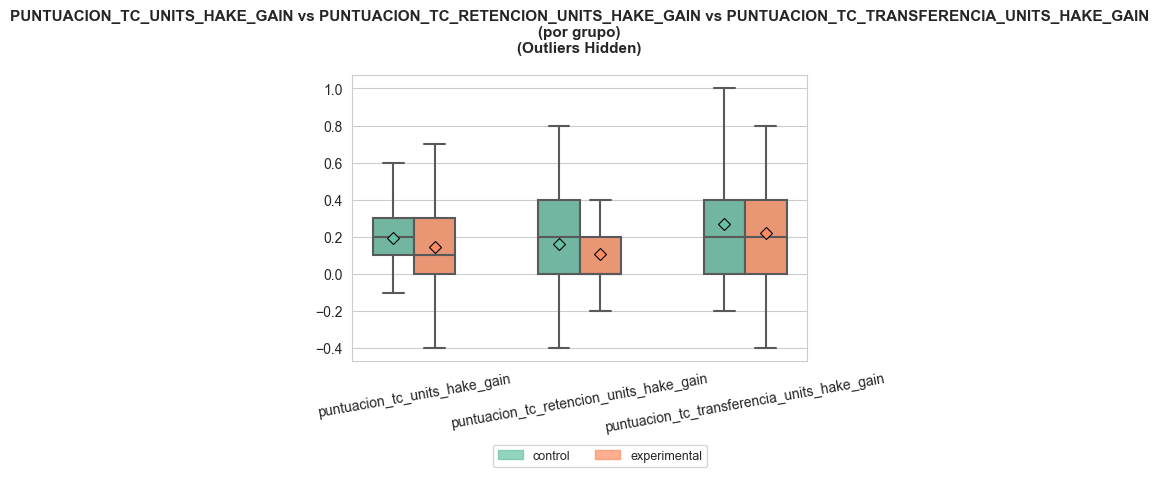

In [47]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        units_hake_gain_quant_cols
    ],
    group_by='grupo',
    showfliers=False,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

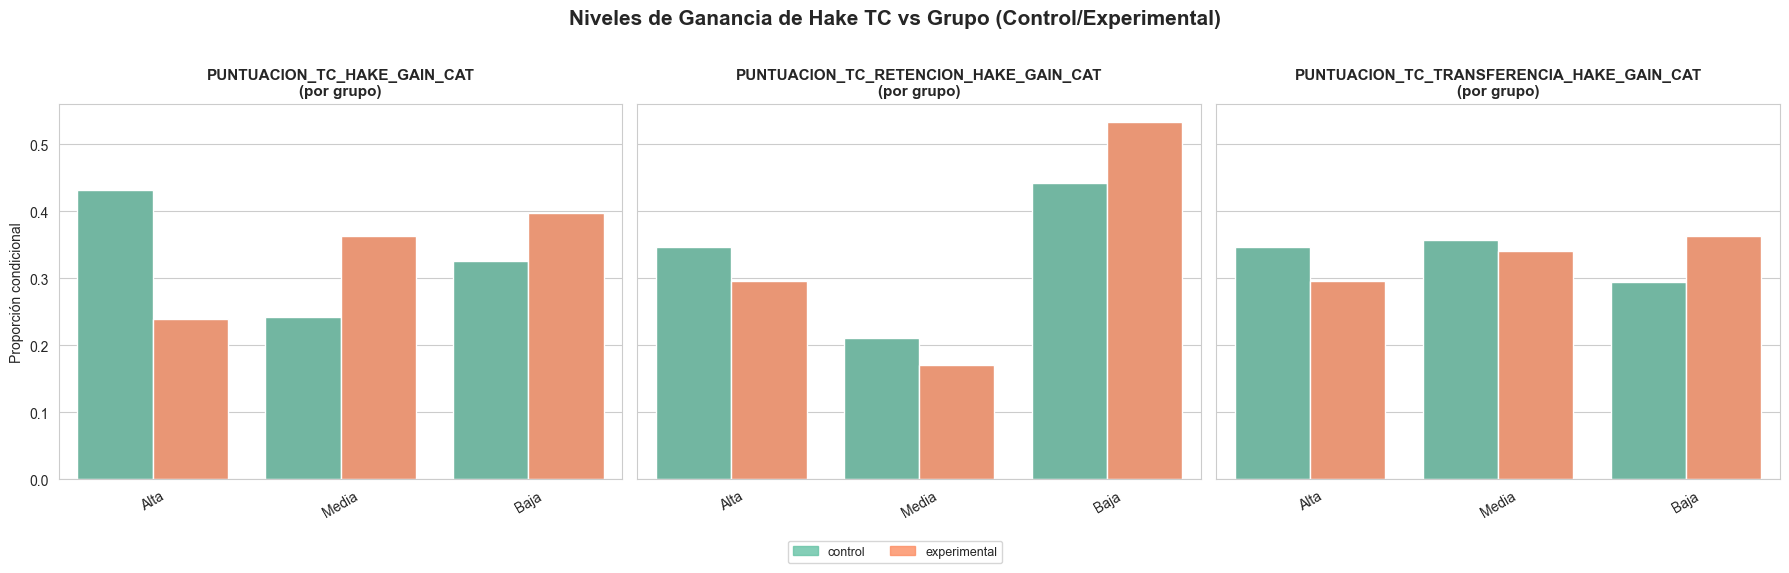

In [48]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tc_hake_gain_cat'],
        ['puntuacion_tc_retencion_hake_gain_cat'],
        ['puntuacion_tc_transferencia_hake_gain_cat']
    ], 
    title='Niveles de Ganancia de Hake TC vs Grupo (Control/Experimental)',
    bbox_to_anchor=(0.5,-0.1),
    order=['Alta', 'Media', 'Baja'],
    group_by='grupo',
    sharey=True
)

- En transferencia las diferencias de ganancias pro grupos son menores que en retención, y, sobre todo, a nivel general/global.

- La probabilidad de tener una ganancia alta es  mayor en el grupo control, mientras que las ganancias medias-bajas son mas probables en el exp.

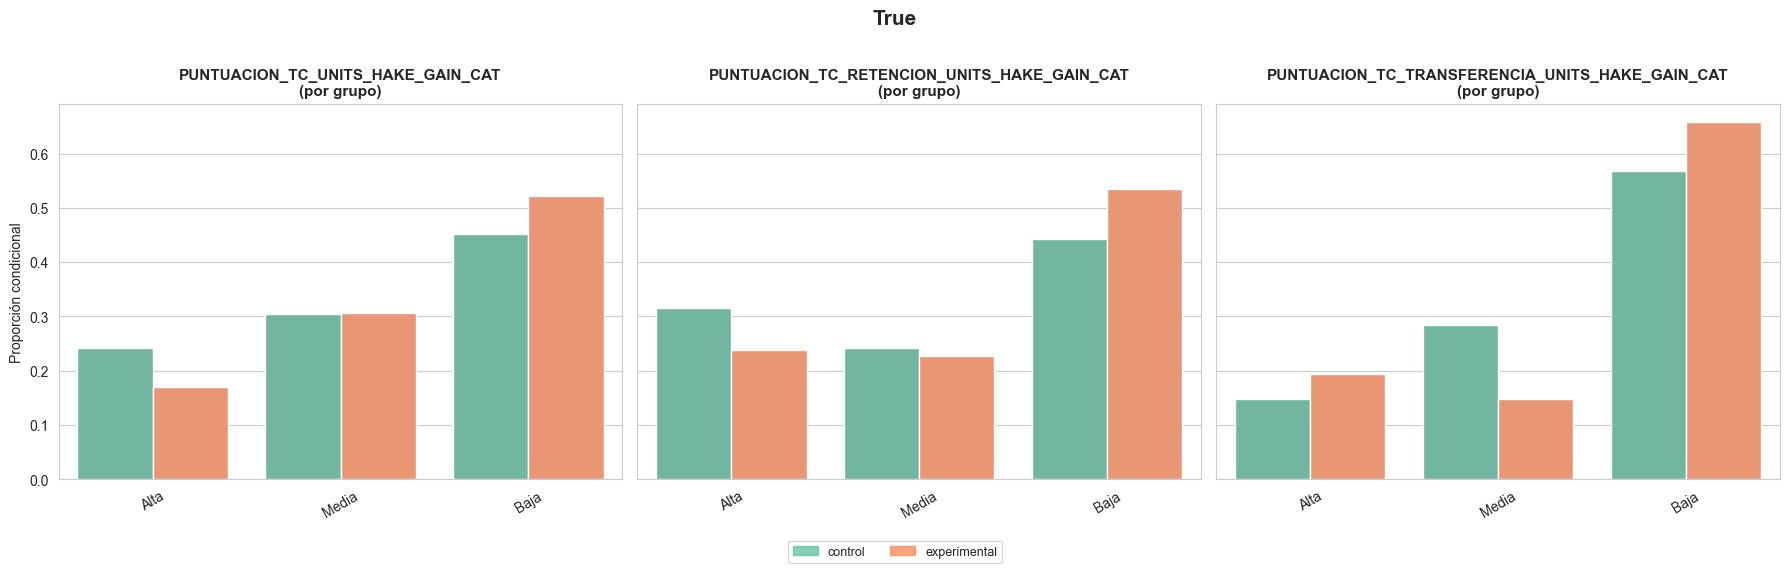

In [49]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tc_units_hake_gain_cat'],
        ['puntuacion_tc_retencion_units_hake_gain_cat'],
        ['puntuacion_tc_transferencia_units_hake_gain_cat']
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    order=['Alta', 'Media', 'Baja'],
    group_by='grupo',
    sharey=True
)


In [50]:
for col in hake_gain_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)), 
            cols =  [col], 
            group_by = 'grupo_segmented_v4'
        ).sort('grupo_segmented_v4')
    )

PUNTUACION_TC_HAKE_GAIN


grupo_segmented_v4,puntuacion_tc_hake_gain_mean,puntuacion_tc_hake_gain_std,puntuacion_tc_hake_gain_q25,puntuacion_tc_hake_gain_median,puntuacion_tc_hake_gain_q75,puntuacion_tc_hake_gain_min,puntuacion_tc_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpA""",0.41892,0.422697,0.25,0.5,0.667,-1.0,1.0
"""ExpB""",0.160222,0.898828,0.0,0.4,0.6,-3.0,1.0
"""ExpNotUsed""",0.236741,0.530459,0.0,0.333,0.6,-1.5,1.0
"""control""",0.413747,0.55716,0.25,0.5,0.75,-2.0,1.0


PUNTUACION_TC_RETENCION_HAKE_GAIN


grupo_segmented_v4,puntuacion_tc_retencion_hake_gain_mean,puntuacion_tc_retencion_hake_gain_std,puntuacion_tc_retencion_hake_gain_q25,puntuacion_tc_retencion_hake_gain_median,puntuacion_tc_retencion_hake_gain_q75,puntuacion_tc_retencion_hake_gain_min,puntuacion_tc_retencion_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpA""",0.37668,0.644211,0.0,0.5,1.0,-1.0,1.0
"""ExpB""",0.041667,0.906221,0.0,0.0,0.5,-3.0,1.0
"""ExpNotUsed""",0.142,0.849465,0.0,0.5,1.0,-2.0,1.0
"""control""",0.307926,0.810249,0.0,0.5,1.0,-4.0,1.0


PUNTUACION_TC_TRANSFERENCIA_HAKE_GAIN


grupo_segmented_v4,puntuacion_tc_transferencia_hake_gain_mean,puntuacion_tc_transferencia_hake_gain_std,puntuacion_tc_transferencia_hake_gain_q25,puntuacion_tc_transferencia_hake_gain_median,puntuacion_tc_transferencia_hake_gain_q75,puntuacion_tc_transferencia_hake_gain_min,puntuacion_tc_transferencia_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpA""",0.44336,0.386968,0.0,0.5,0.667,0.0,1.0
"""ExpB""",0.396722,0.588033,0.333,0.5,0.75,-1.0,1.0
"""ExpNotUsed""",0.293222,0.563018,0.0,0.25,0.75,-1.0,1.0
"""control""",0.491779,0.48097,0.0,0.5,1.0,-1.0,1.0


In [51]:
for col in units_hake_gain_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)), 
            cols =  [col], 
            group_by = 'grupo_segmented_v4'
        ).sort('grupo_segmented_v4')
    )

PUNTUACION_TC_UNITS_HAKE_GAIN


grupo_segmented_v4,puntuacion_tc_units_hake_gain_mean,puntuacion_tc_units_hake_gain_std,puntuacion_tc_units_hake_gain_q25,puntuacion_tc_units_hake_gain_median,puntuacion_tc_units_hake_gain_q75,puntuacion_tc_units_hake_gain_min,puntuacion_tc_units_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpA""",0.188,0.178699,0.1,0.1,0.3,-0.1,0.6
"""ExpB""",0.138889,0.232106,0.0,0.2,0.3,-0.4,0.7
"""ExpNotUsed""",0.122222,0.188788,0.0,0.1,0.3,-0.3,0.5
"""control""",0.195789,0.206241,0.1,0.2,0.3,-0.2,0.7


PUNTUACION_TC_RETENCION_UNITS_HAKE_GAIN


grupo_segmented_v4,puntuacion_tc_retencion_units_hake_gain_mean,puntuacion_tc_retencion_units_hake_gain_std,puntuacion_tc_retencion_units_hake_gain_q25,puntuacion_tc_retencion_units_hake_gain_median,puntuacion_tc_retencion_units_hake_gain_q75,puntuacion_tc_retencion_units_hake_gain_min,puntuacion_tc_retencion_units_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpA""",0.168,0.256125,0.0,0.2,0.4,-0.2,0.8
"""ExpB""",0.088889,0.296434,0.0,0.0,0.2,-0.6,1.0
"""ExpNotUsed""",0.081481,0.261706,0.0,0.2,0.2,-0.4,0.6
"""control""",0.16,0.265137,0.0,0.2,0.4,-0.8,0.8


PUNTUACION_TC_TRANSFERENCIA_UNITS_HAKE_GAIN


grupo_segmented_v4,puntuacion_tc_transferencia_units_hake_gain_mean,puntuacion_tc_transferencia_units_hake_gain_std,puntuacion_tc_transferencia_units_hake_gain_q25,puntuacion_tc_transferencia_units_hake_gain_median,puntuacion_tc_transferencia_units_hake_gain_q75,puntuacion_tc_transferencia_units_hake_gain_min,puntuacion_tc_transferencia_units_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpA""",0.224,0.210713,0.0,0.2,0.4,0.0,0.6
"""ExpB""",0.25,0.307525,0.2,0.2,0.4,-0.4,0.8
"""ExpNotUsed""",0.177778,0.256205,0.0,0.2,0.4,-0.2,0.6
"""control""",0.267368,0.251989,0.0,0.2,0.4,-0.2,1.0


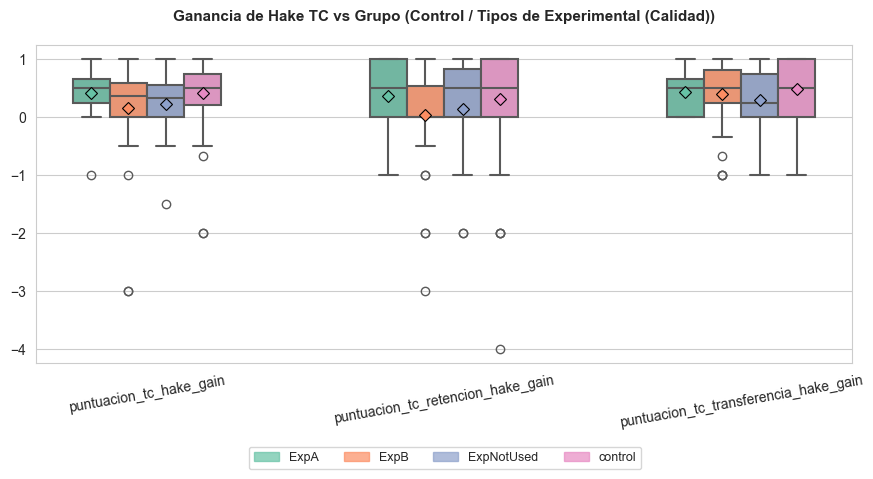

In [52]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v4',
    showfliers=True,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control / Tipos de Experimental (Calidad))',
    figsize=(9,4)
)

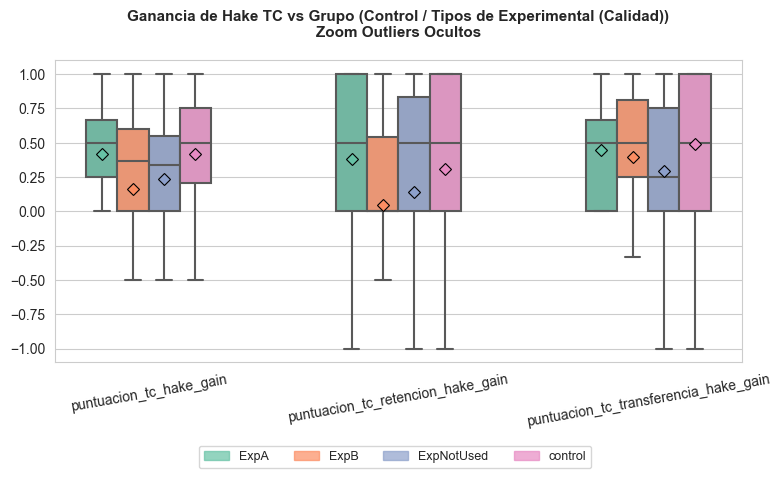

In [53]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v4',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control / Tipos de Experimental (Calidad))\nZoom Outliers Ocultos',
    figsize=(8,4)
)

- Observamos como una mejor calidad en el uso de la herramienta permite equiparar el exp con el control. En cambio usuarios con un uso inadecuado de la herramienta se ven lastrados resultando en ganancias inferiores a los otros dos grupos citados.

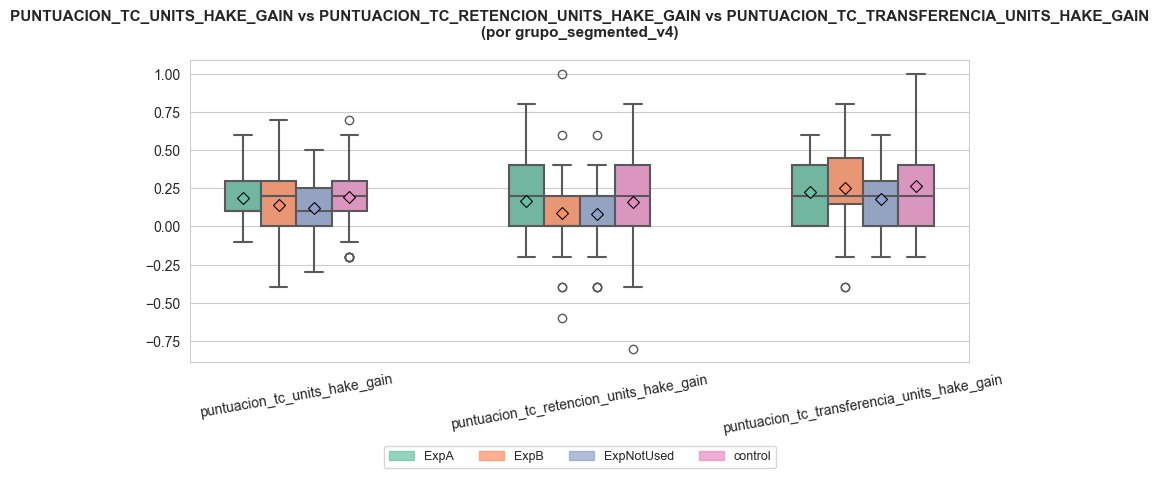

In [54]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df,
    comparisons = [
        units_hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v4',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

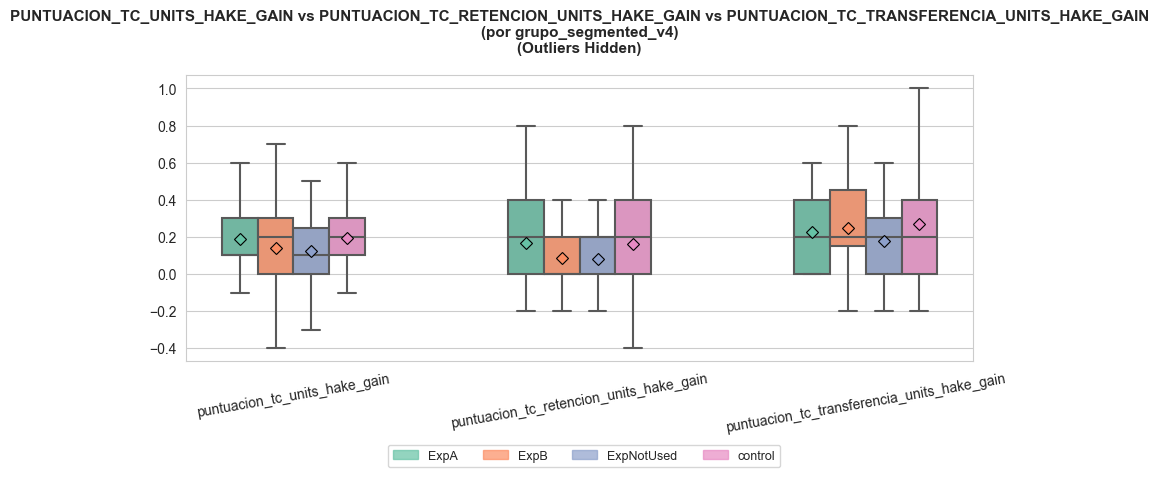

In [55]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df,
    comparisons = [
        units_hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v4',
    showfliers=False,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

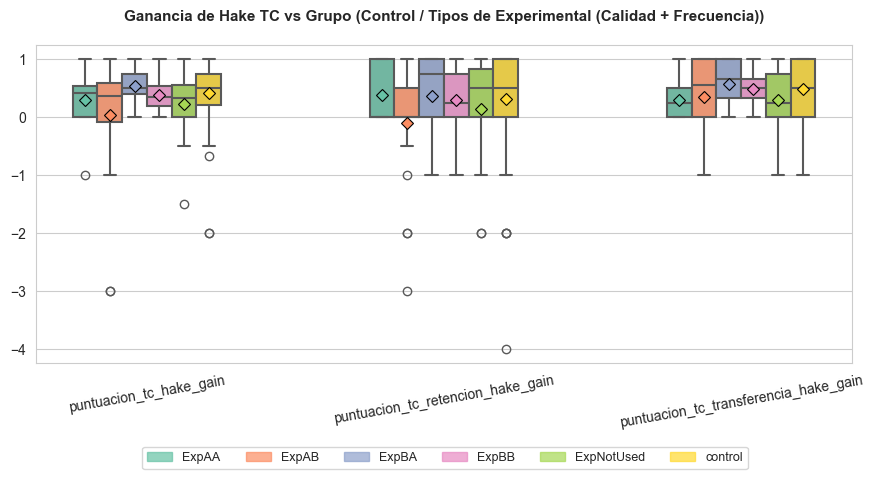

In [56]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=True,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))',
    figsize=(9,4)
)

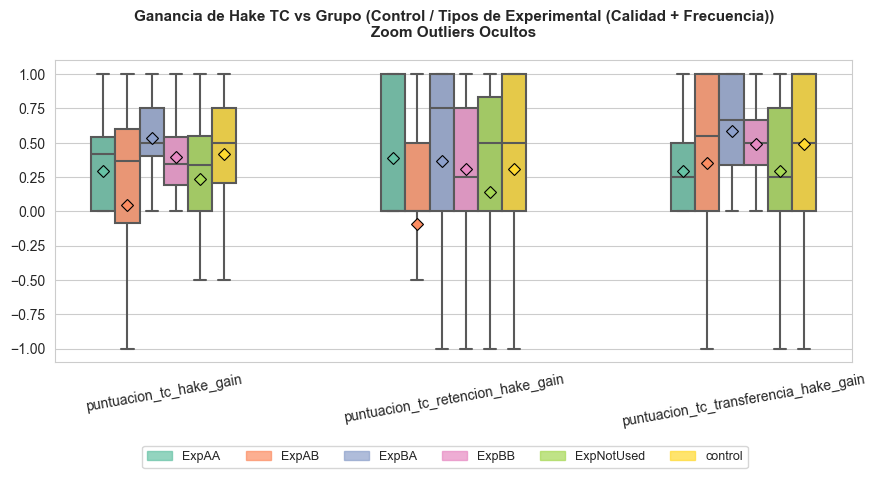

In [57]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))\nZoom Outliers Ocultos',
)

Ranking:

1. BA: usar la herramienta poco y bien
2. Control
3. BB: poco y mal
4. AA: mucho y bien
5. No usado (el chat)
6. AB: mucho y mal

Usarlo poco, mejor que mucho (efecto distraccion/fatiga). Usarlo bien es mejor que mal (efecto calidad).

El único grupo que se equipara/supera al control es el que usa la herrmienta poco pero bien.



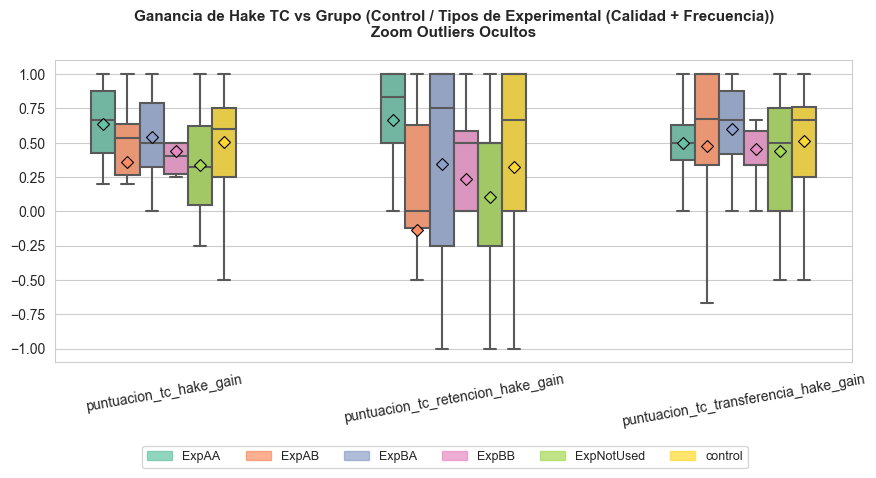

In [ ]:
plot_quant_comparison(
    figsize = (9,4),
    df = no_efecto_techo_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))\nZoom Outliers Ocultos',
)


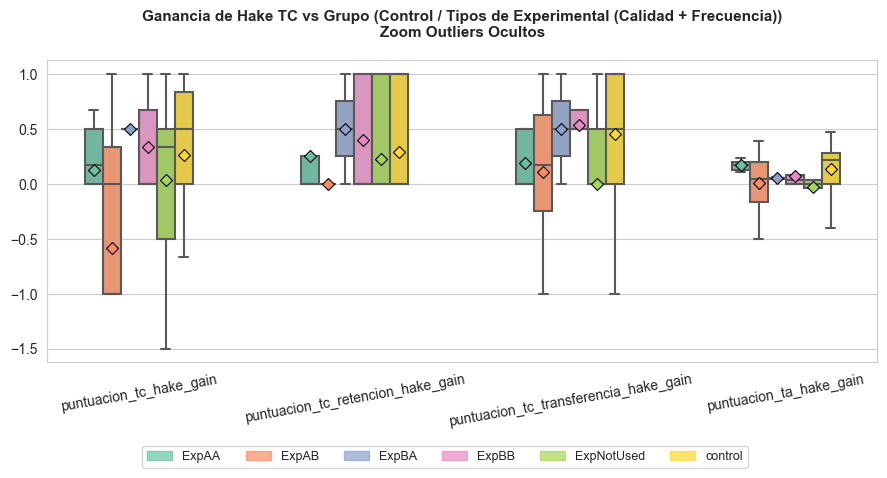

In [302]:
efecto_techo_df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)).filter(
    pl.col("puntuacion_tc_cat_trad_scale_v2_pre") == "notable-sobresaliente"
)


plot_quant_comparison(
    figsize = (9,4),
    df = efecto_techo_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))\nZoom Outliers Ocultos',
)


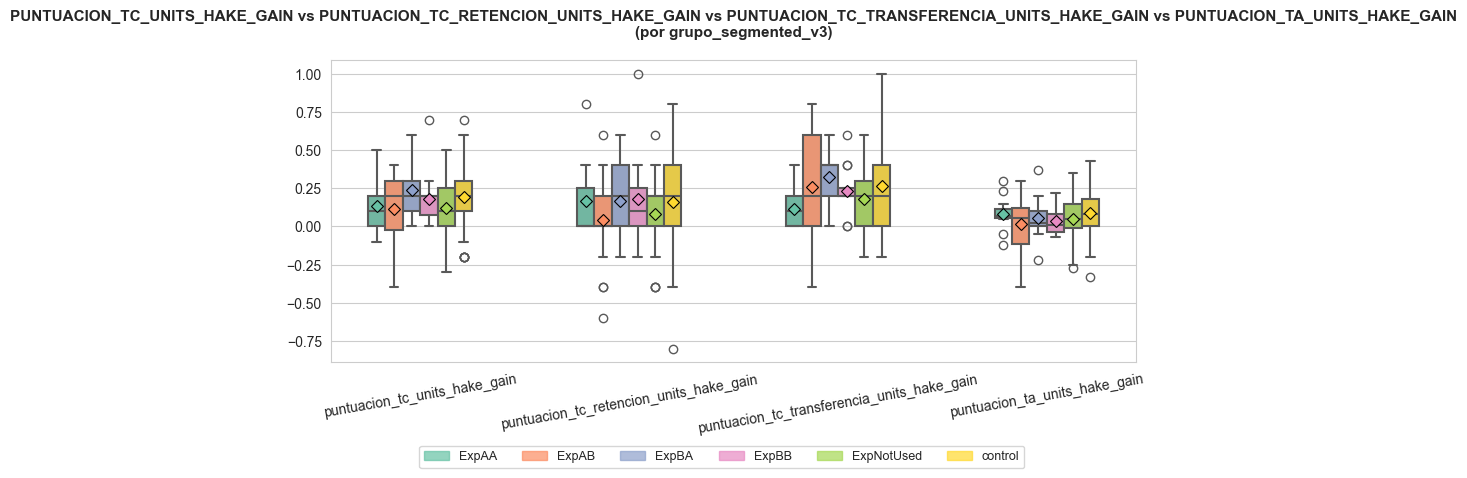

In [303]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        units_hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

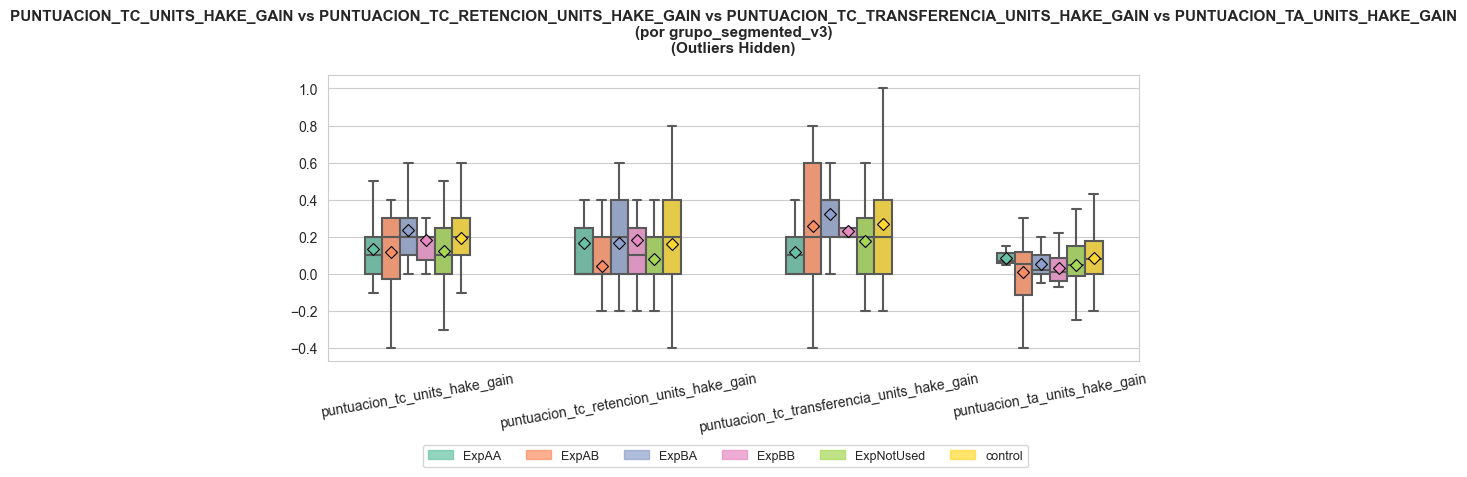

In [304]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        units_hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=False,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

#### Mejora

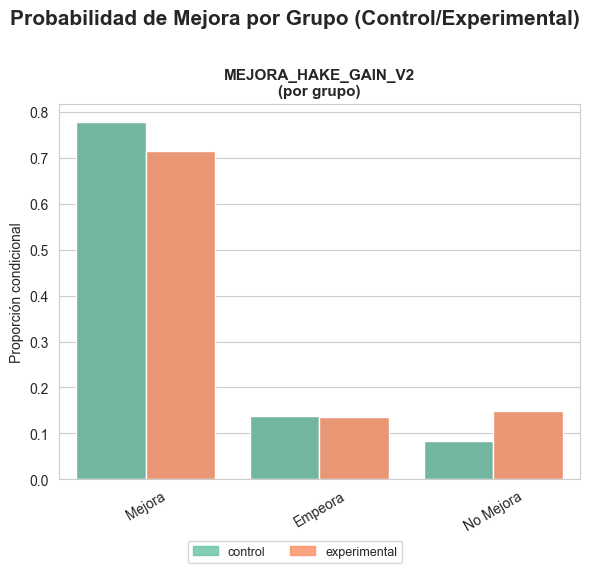

In [306]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title="Probabilidad de Mejora por Grupo (Control/Experimental)",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo',
)

- En general, la prob de mejora es superior en el control que en el exp, aunque la dif es de 7% aprox. Esta diferencia viene explicada totalmente por usuarios exp que no mejoran, dado que la prob de empeorar es igual en ambos grupos (control-exp).

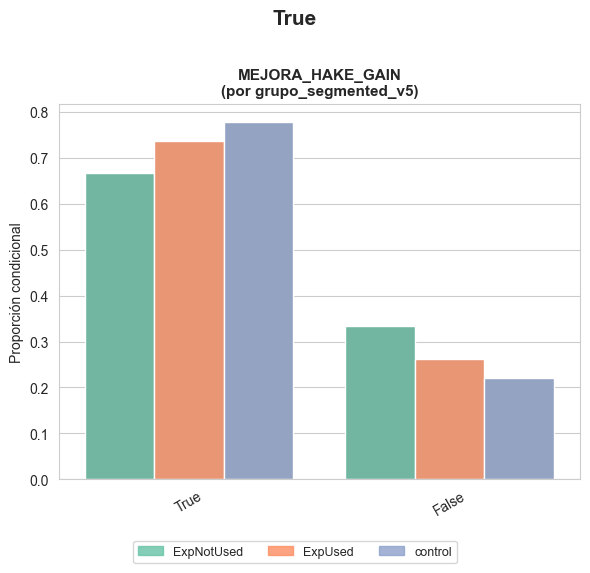

In [307]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_hake_gain'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v5',
)

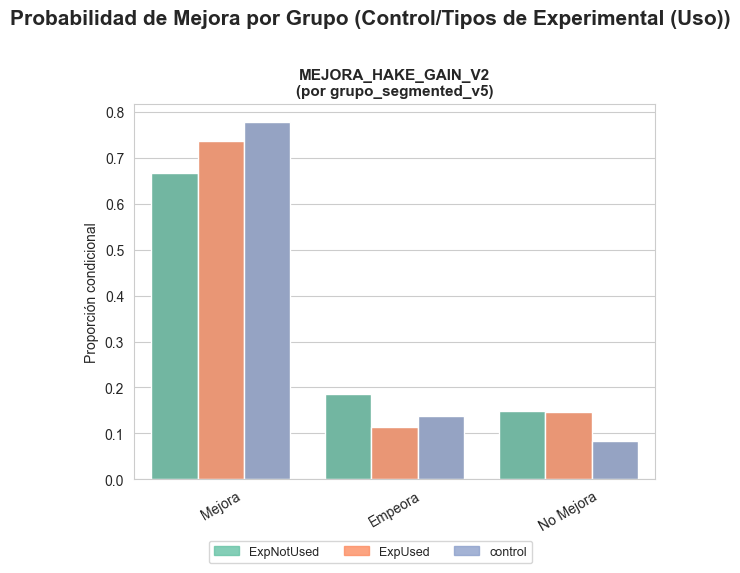

In [308]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title="Probabilidad de Mejora por Grupo (Control/Tipos de Experimental (Uso))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v5',
)

- Prob de mejora es mayor si se usa el chat consultivo que si no.
- Prob empeorar es mayor en el control que en aquellos que usan chat consultivo, y aún mayor en aquellos que no lo usan.


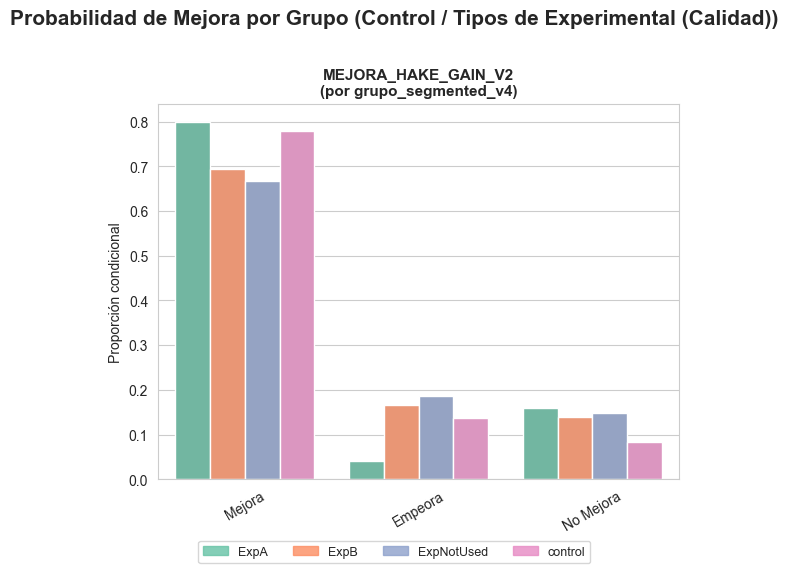

In [309]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title="Probabilidad de Mejora por Grupo (Control / Tipos de Experimental (Calidad))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v4',
)


- La probabilidad de mejroar es significativamente superior si se usa la herramienta bien que si se usa mal o no se usa el chat, y tbn supera al control. 

- La prob de empeorar habiendo usado la herramienta bien es casi nula, y notablemente inferior a la asociada a usarla mal, no usar el chat, o incluso control.

- Usarla (aún mal) es mejor que no usarla (mas prob de mejora, menos de empeora).

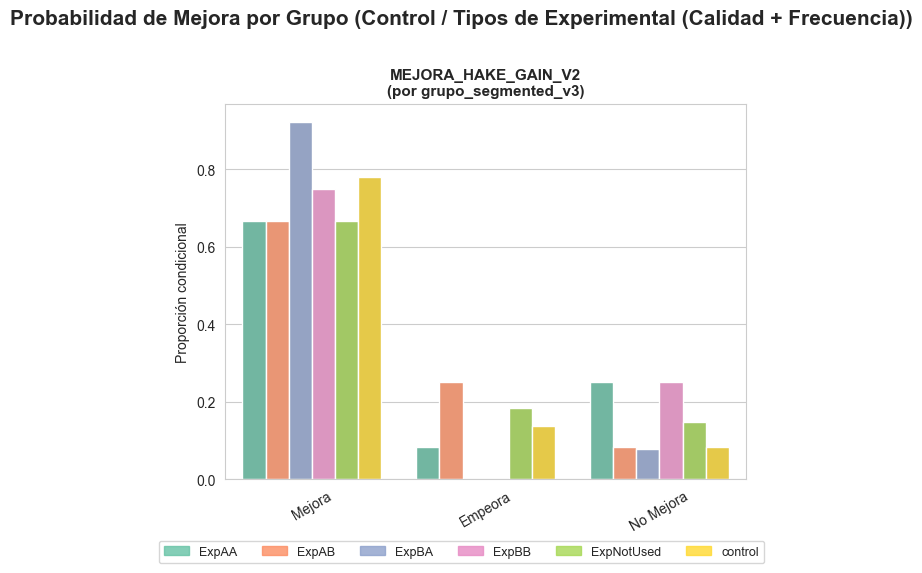

In [310]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title="Probabilidad de Mejora por Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v3',
)


- La prob de mejorar si se usa la herramienta poco y bien es significativamente superior a control, y el resto de usos de la herramienta. Es cercana a 100% y la prob de empeorar en ese caso es nula.

-  La prob de empeoramiento es mayor en AB que en ningun otro grupo. Usarlo **mucho y mal es lo que mas perjudica**, incluso más que no usar el chat consultivo. 

- Usarlo poco y mal es mejor que usarlo mucho y bien. Efecto distracción/fatiga parece ser mayor que el efecto de la calidad de uso.

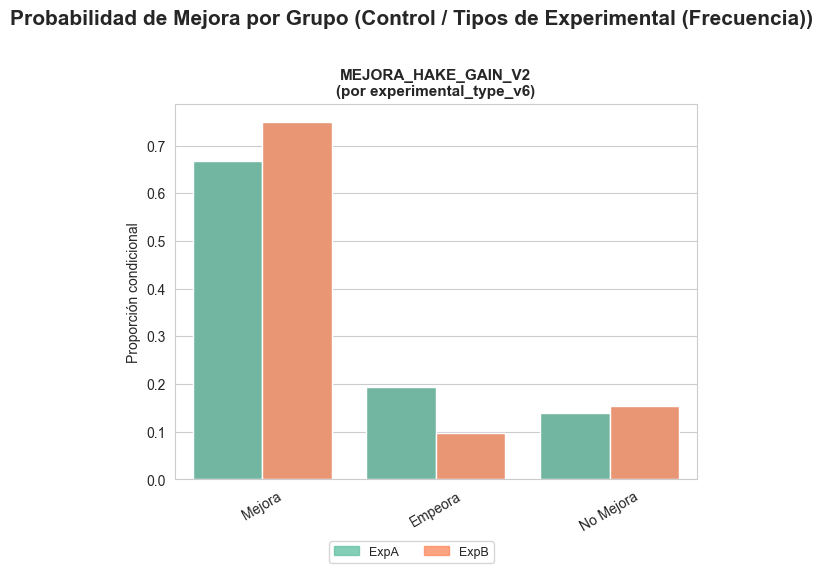

In [311]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title="Probabilidad de Mejora por Grupo (Control / Tipos de Experimental (Frecuencia))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='experimental_type_v6',
)


- Usar mucho la herramienta es peor que usarla poca (mas prob de empeorar y menos de mejora).

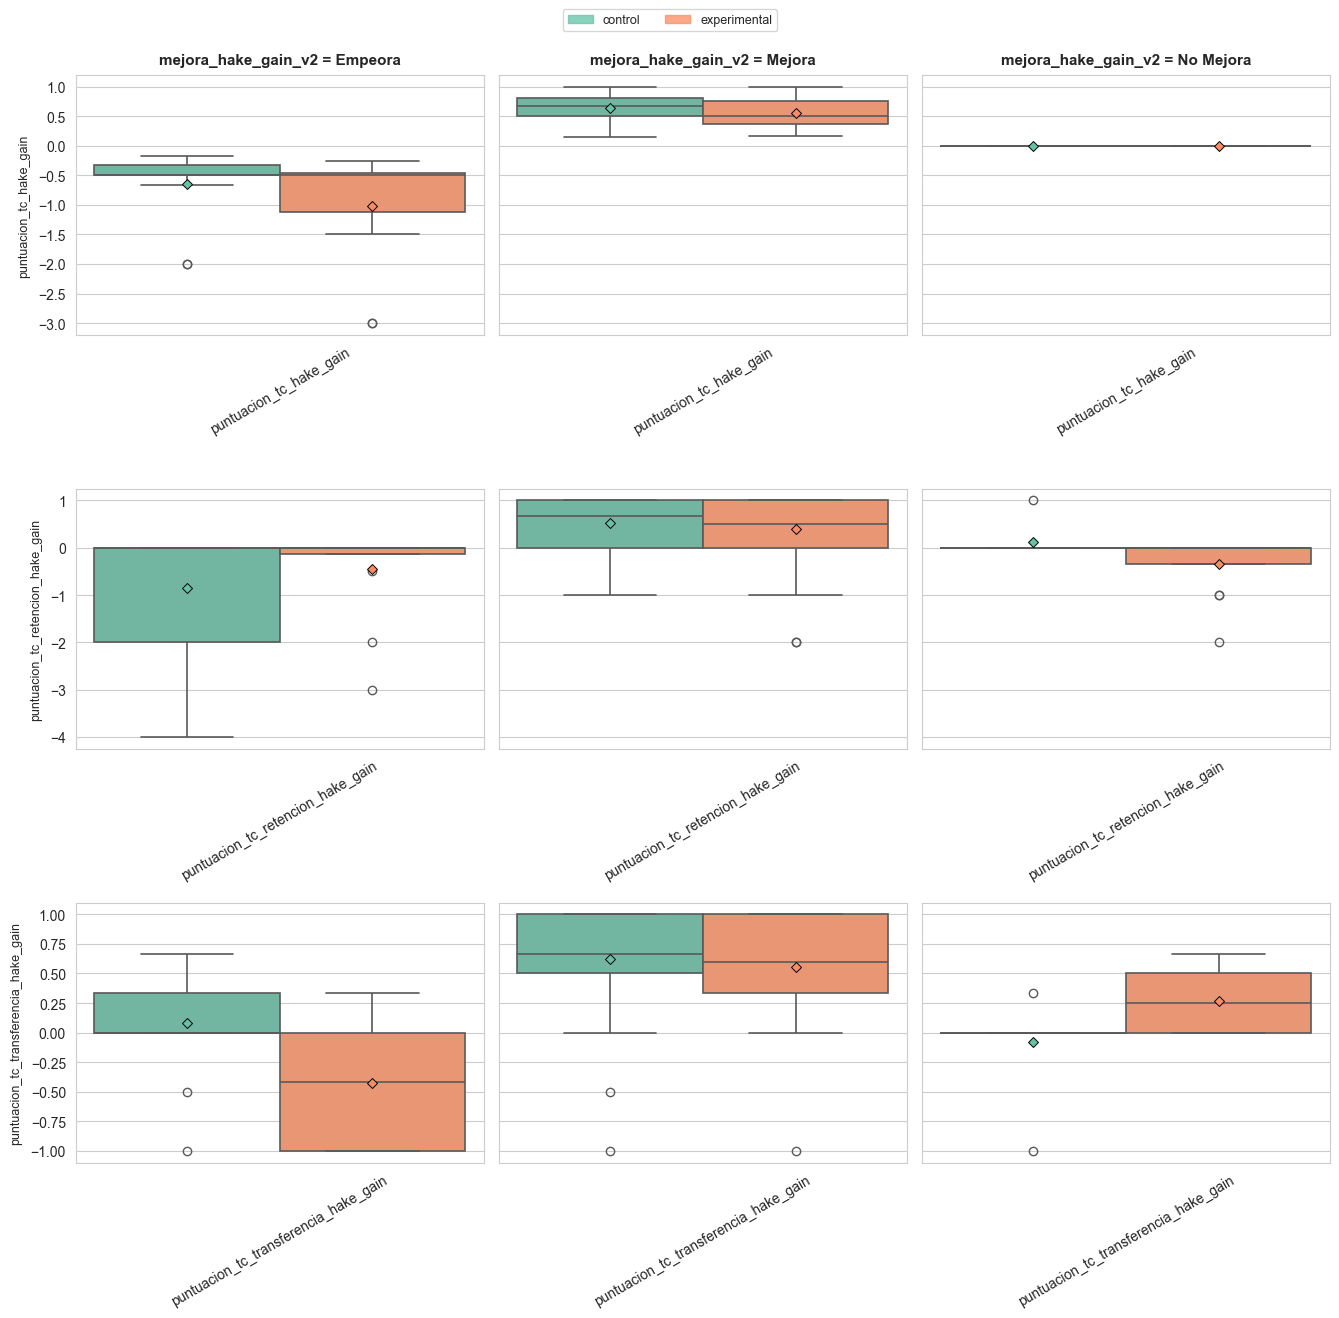

In [312]:
plot_quant_comparison_faceted(
    forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_hake_gain"],
        ["puntuacion_tc_retencion_hake_gain"],
        ["puntuacion_tc_transferencia_hake_gain"],
    ],
    outer_group_by="mejora_hake_gain_v2",
    group_by="grupo",            
    palette="Set2",
    showfliers=True,
    bbox_to_anchor=(0.5, 1),
    #figsize=(10,8)
)

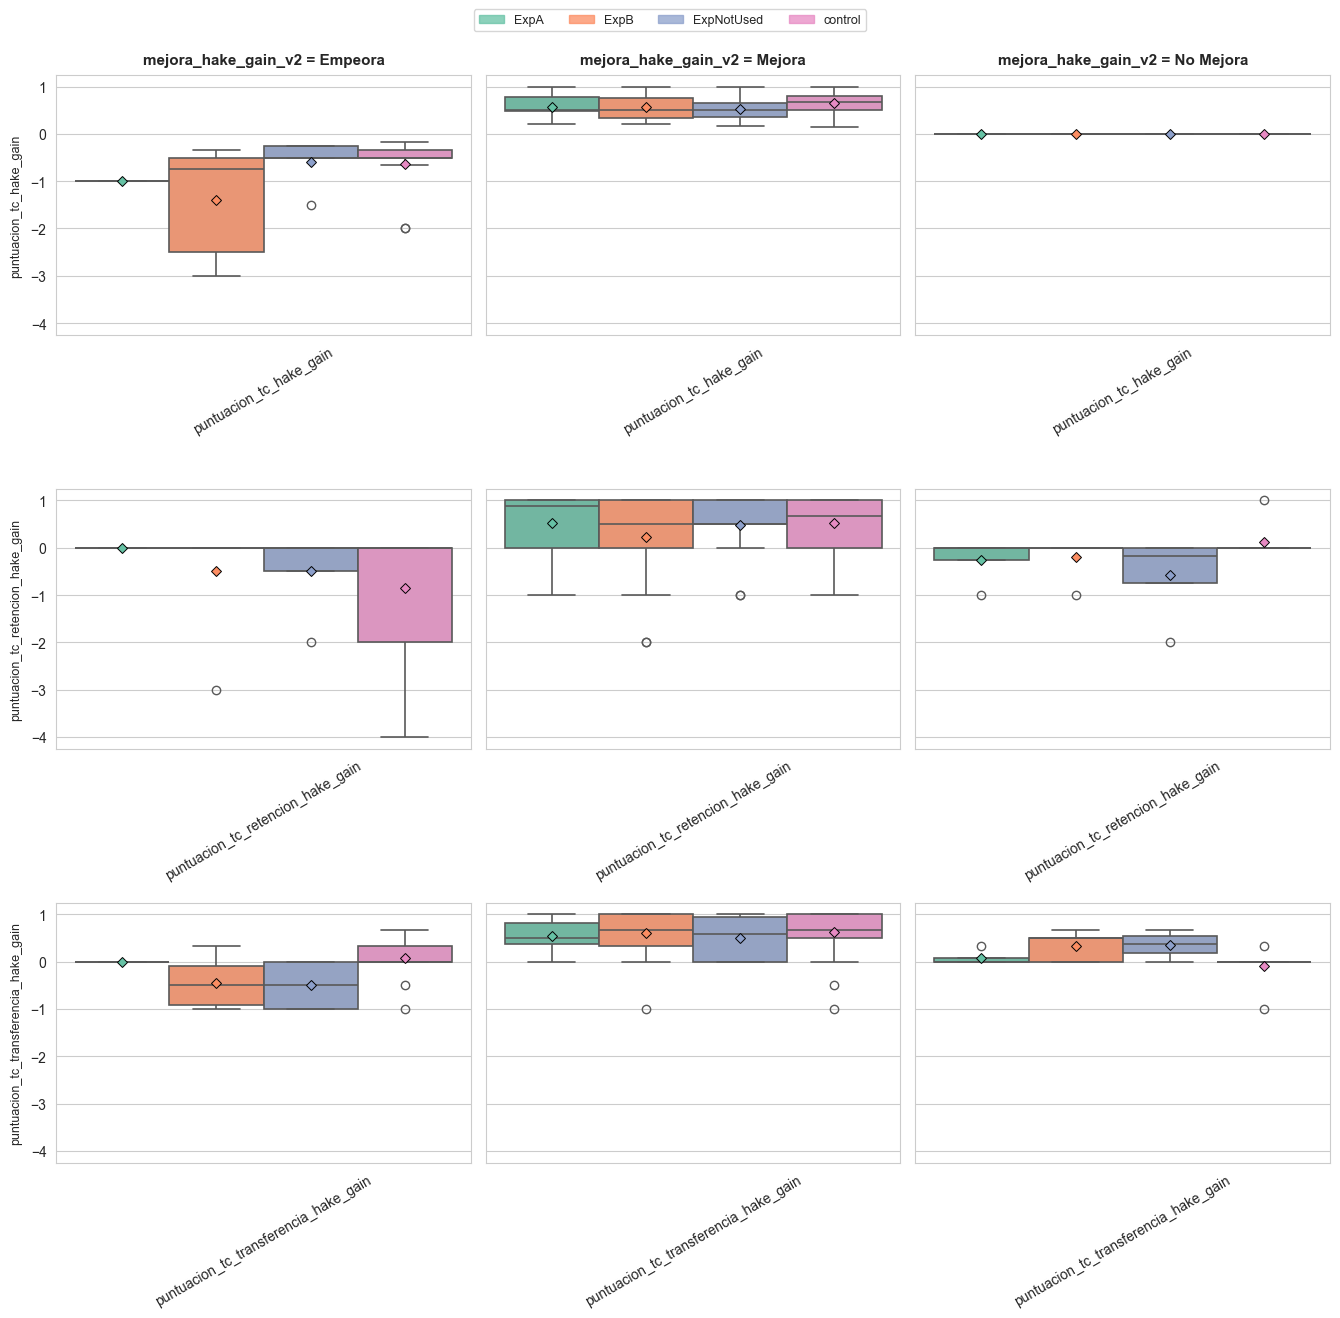

In [313]:
plot_quant_comparison_faceted(
    forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_hake_gain"],
        ["puntuacion_tc_retencion_hake_gain"],
        ["puntuacion_tc_transferencia_hake_gain"],
    ],
    outer_group_by="mejora_hake_gain_v2",
    group_by="grupo_segmented_v4",            
    palette="Set2",
    showfliers=True,
    bbox_to_anchor=(0.5, 1),
    sharey="all"
)

#### Mejora Retencion / Transferencia

In [ ]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_retencion_hake_gain'], ['mejora_transferencia_hake_gain']
    ], 
    title="Probabilidad de Mejora por Grupo (Control/Experimental)",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo',
    sharey=True,
)

In [ ]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_retencion_hake_gain'], ['mejora_transferencia_hake_gain']
    ], 
    title="Probabilidad de Mejora por Grupo (Control / Tipos de Experimental (Calidad))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v4',
    sharey=True,
)

In [ ]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_retencion_hake_gain'], ['mejora_transferencia_hake_gain']
    ], 
    title="Probabilidad de Mejora por Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v3',
    sharey=True,
)

In [ ]:
plot_cat_comparison(
    df=no_efecto_techo_df, 
    comparisons=[
        ['mejora_retencion_hake_gain'], ['mejora_transferencia_hake_gain']
    ], 
    title="Probabilidad de Mejora por Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v3',
    sharey=True,
)

#### Niveles de Mejora

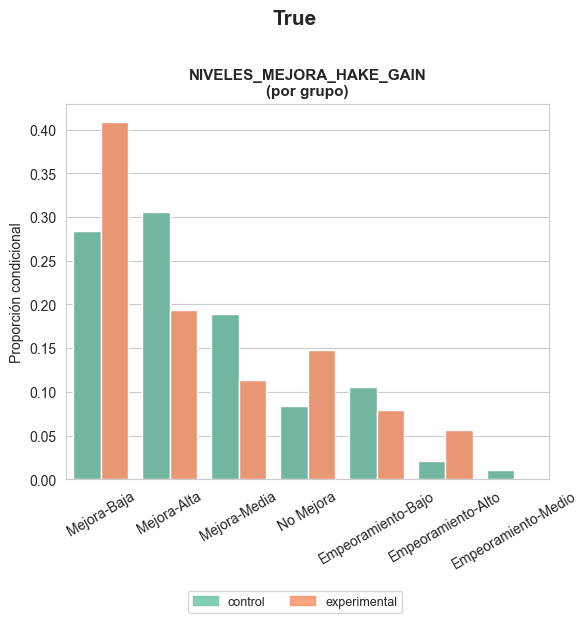

In [314]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo',
)


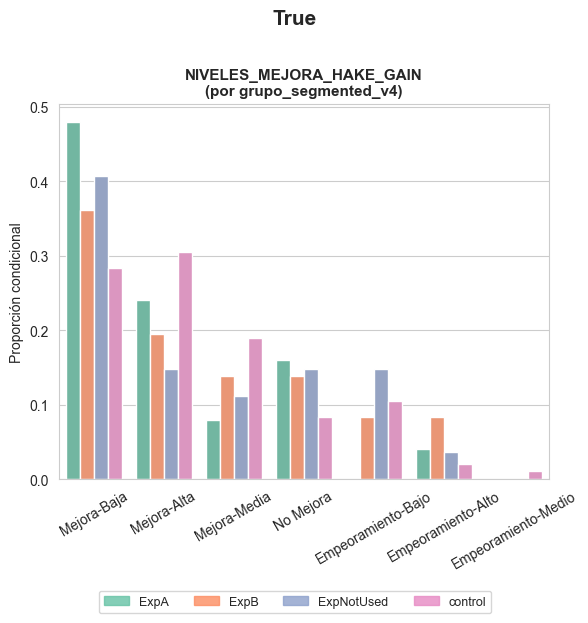

In [315]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo_segmented_v4',
)


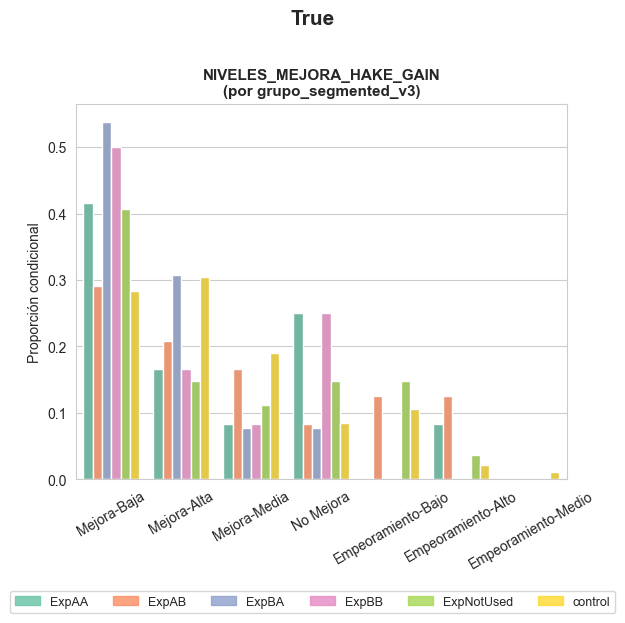

In [316]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo_segmented_v3',
)


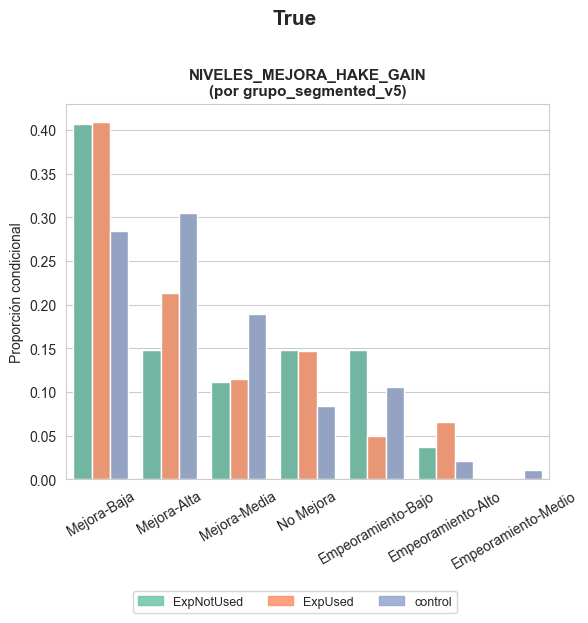

In [317]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo_segmented_v5',
)


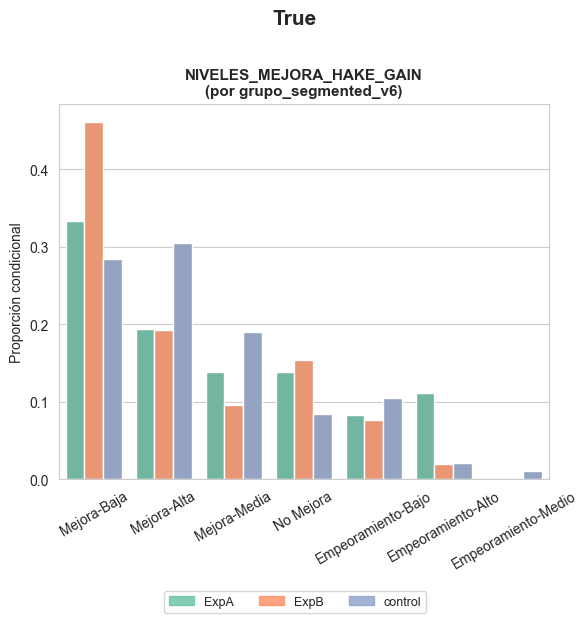

In [318]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo_segmented_v6',
)


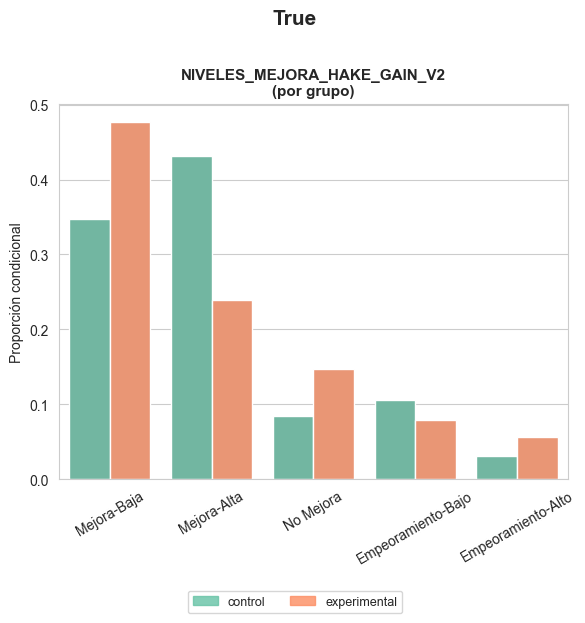

In [319]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain_v2'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo',
)


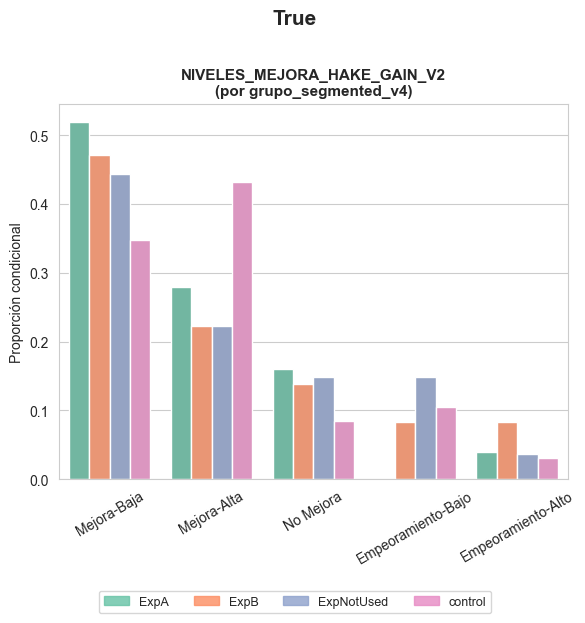

In [320]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain_v2'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo_segmented_v4',
)


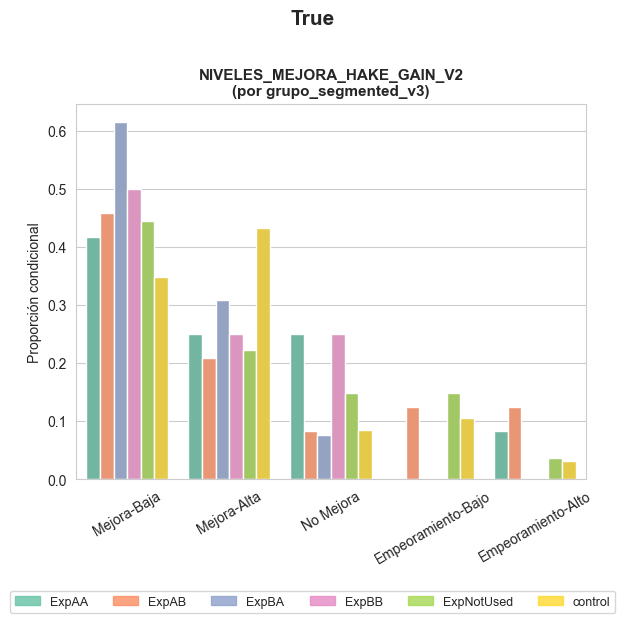

In [321]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain_v2'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo_segmented_v3',
)


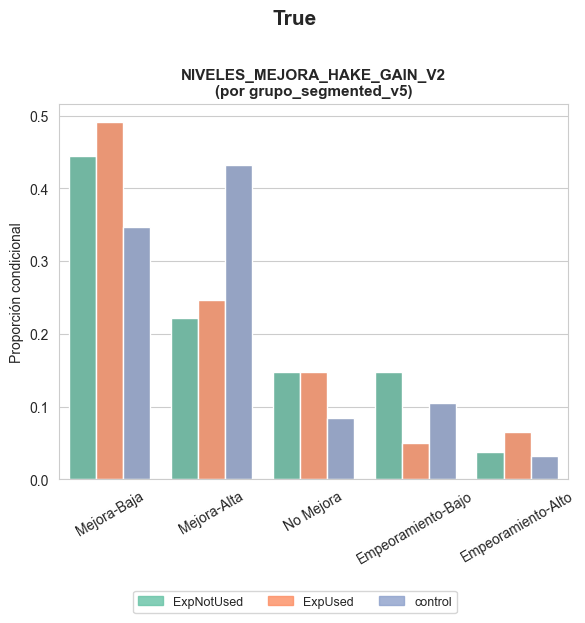

In [322]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain_v2'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo_segmented_v5',
)


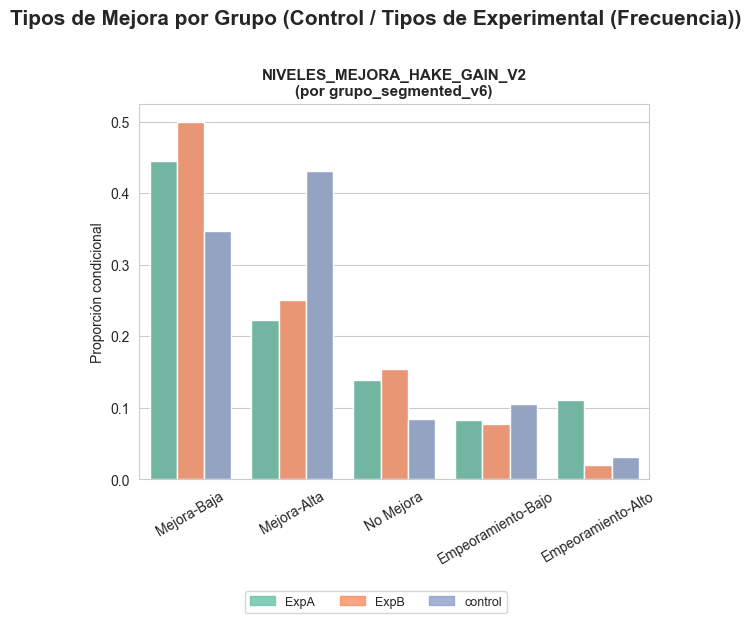

In [323]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['niveles_mejora_hake_gain_v2'],
    ], 
    title="Tipos de Mejora por Grupo (Control / Tipos de Experimental (Frecuencia))",
    bbox_to_anchor=(0.5,-0.20),
    group_by='grupo_segmented_v6',
)


- Usar mucho es peor que poco, mas evidencias en esta dirección.

#### Conocimientos Pre-Post

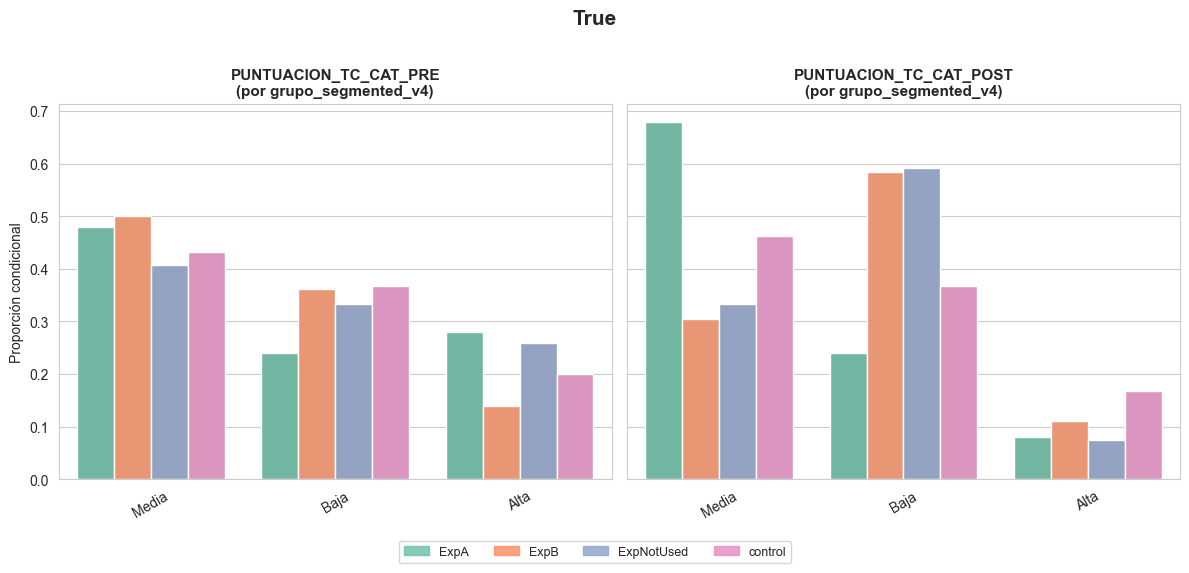

In [324]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tc_cat_pre'], ['puntuacion_tc_cat_post'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v4',
    sharey=True

)

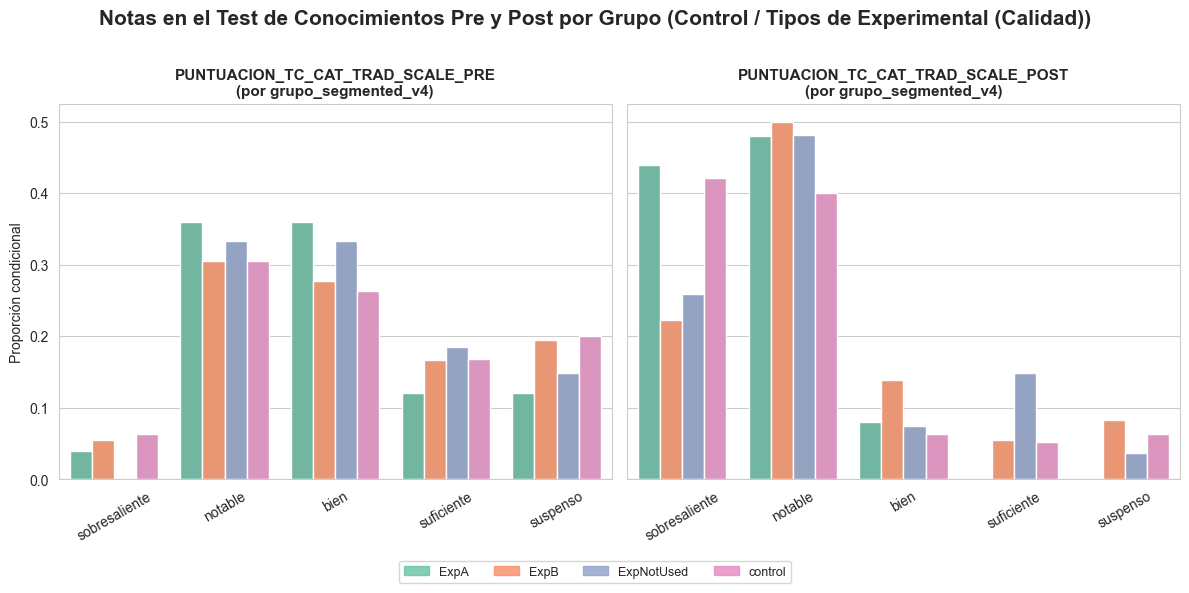

In [325]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tc_cat_trad_scale_pre'], ['puntuacion_tc_cat_trad_scale_post'],
    ], 
    title="Notas en el Test de Conocimientos Pre y Post por Grupo (Control / Tipos de Experimental (Calidad))",
    bbox_to_anchor=(0.5,-0.14),
    group_by='grupo_segmented_v4',
    sharey=True,
    order=['sobresaliente', 'notable', 'bien', 'suficiente', 'suspenso']
)

- Prob de suspender o suficiente en el post es nula si se usa bien la herramienta. 

- Prob de sobresaliente si se usa biien la herramienta es muy superior a si se usa mal o no se usa chat cons, y también superior al contro.

- El buen uso permite saltar de suficiente-suspenso-bien a notable-sobresaliente. La herramienta bien usada, favorece más a los que menos saben, ya que el 25% de suspensos-suficientese han pasado a ser bien-notable-sobre.


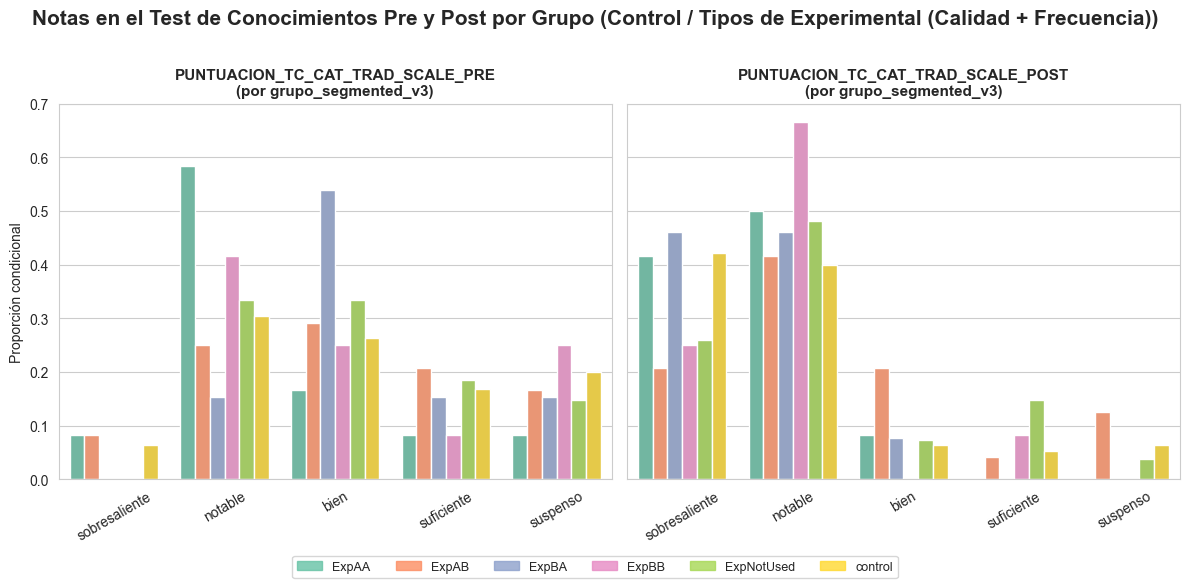

In [326]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tc_cat_trad_scale_pre'], ['puntuacion_tc_cat_trad_scale_post'],
    ], 
    title="Notas en el Test de Conocimientos Pre y Post por Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))",
    bbox_to_anchor=(0.5,-0.13),
    group_by='grupo_segmented_v3',
    sharey=True,
    order=['sobresaliente', 'notable', 'bien', 'suficiente', 'suspenso']
)

- Los que han usado bien la herramienta, ya sea poco o mucho, superan en resultados  sobresalientes en el post al resto, incluido control. Usarlo poco pero ben supera a mucho y bien (efecto distracción/fatiga --> lastre).

- Los que tienen más probabilidad de suspender son los que usan la herramienta mucho y mal (fatiga/distracción + mala calidad).


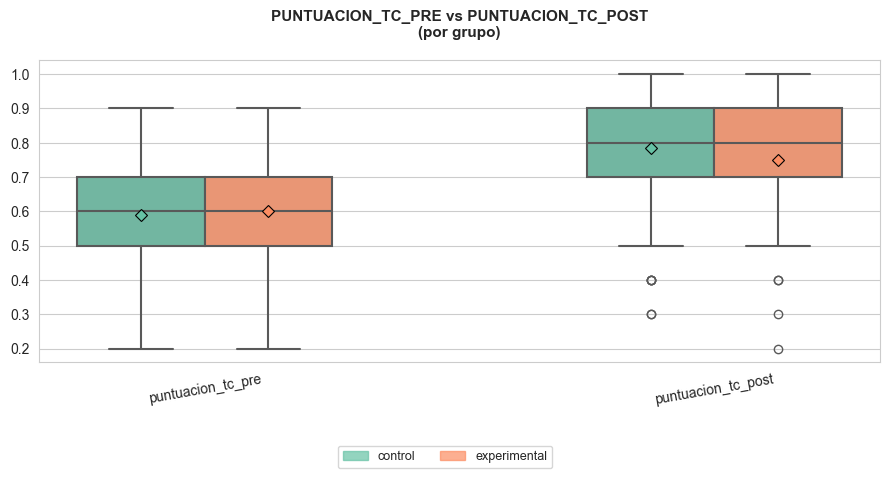

In [327]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_pre", "puntuacion_tc_post"]
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

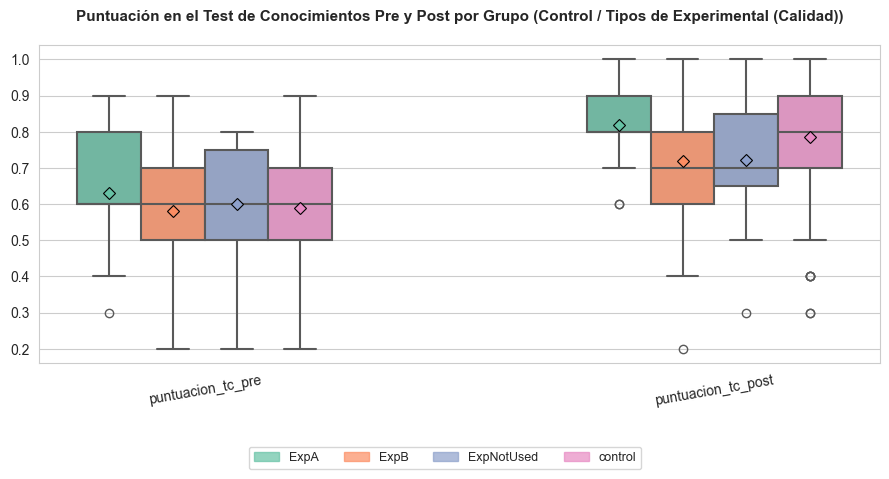

In [328]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_pre", "puntuacion_tc_post"]
    ],
    group_by='grupo_segmented_v4',
    showfliers=True,
    title="Puntuación en el Test de Conocimientos Pre y Post por Grupo (Control / Tipos de Experimental (Calidad))",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

- Los que demuestran saber más en el pre (conocimeinto base mayor), tienen una predisposición a usar la herramienta con más calidad. Por ello la ganancia es menor en este grupo en terminos cuantitativos al partir ya de una puntuación pre más alta (efecto techo).



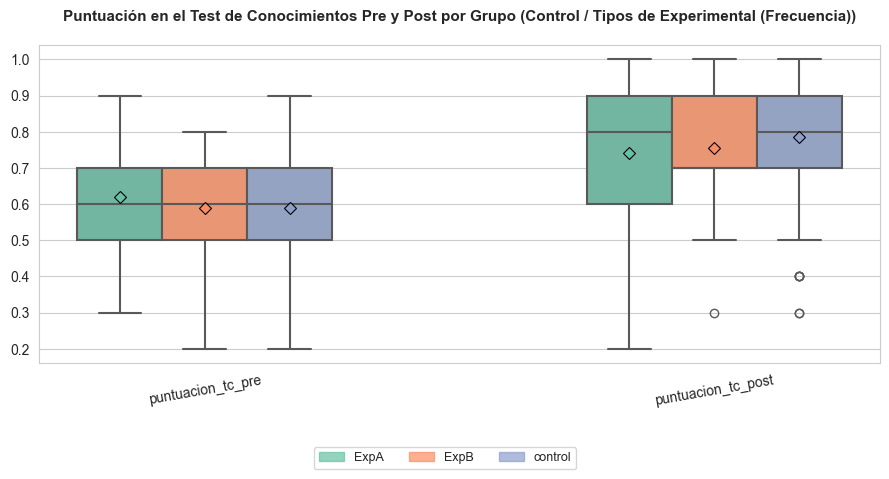

In [329]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_pre", "puntuacion_tc_post"]
    ],
    group_by='grupo_segmented_v6',
    showfliers=True,
    title="Puntuación en el Test de Conocimientos Pre y Post por Grupo (Control / Tipos de Experimental (Frecuencia))",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

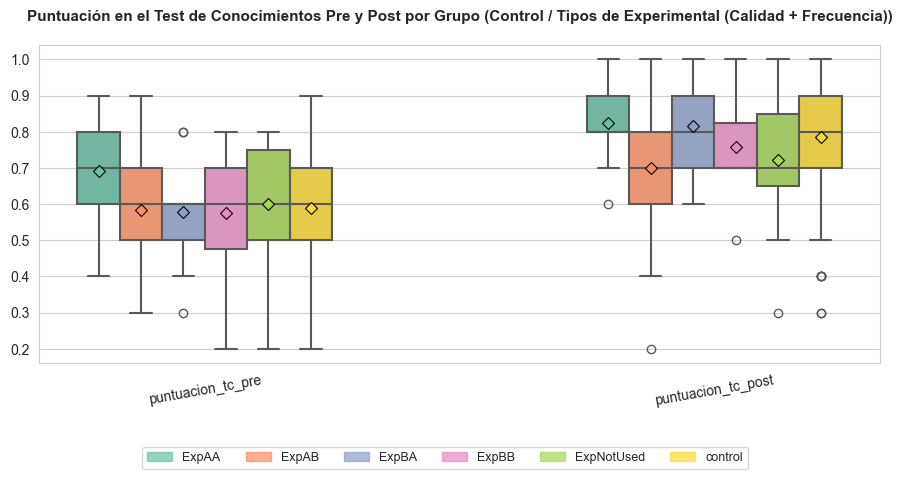

In [330]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_pre", "puntuacion_tc_post"]
    ],
    group_by='grupo_segmented_v3',
    showfliers=True,
    title="Puntuación en el Test de Conocimientos Pre y Post por Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

- Los que demuestran saber más en el pre (conocimeinto base mayor), tienen una predisposición a usar la herramienta con más calidad y con más frecuencia. Mientras que los que lo usan poco y bien parten de una base inferior, y más similar al resto de grupos. Por tanto el efecto techo sobre la ganancia de conocimiento es inferior en los que la usan poco-bien que en mucho-bien, lo que explicaría las observaciones de mayor gananica de hake en poco-bien que en mucho-bien, además del efecto fatiga por usar más la herramienta.

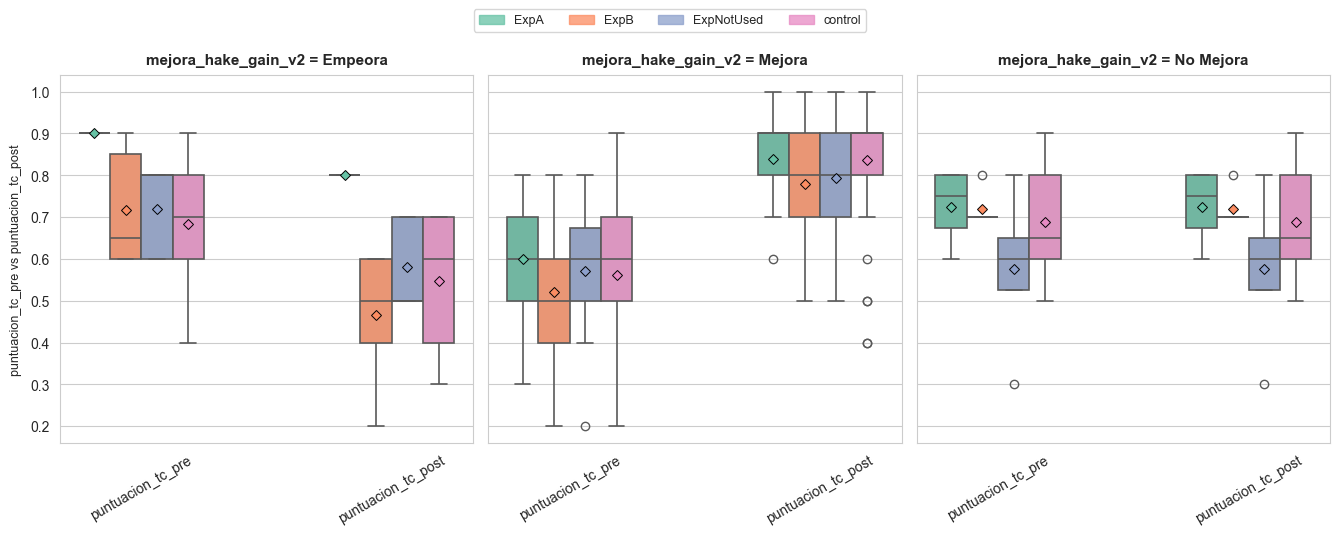

In [331]:
plot_quant_comparison_faceted(
    forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_pre", "puntuacion_tc_post"],
    ],
    outer_group_by="mejora_hake_gain_v2",
    group_by="grupo_segmented_v4",            
    palette="Set2",
    showfliers=True,
    bbox_to_anchor=(0.5, 1),
    sharey="all"
)

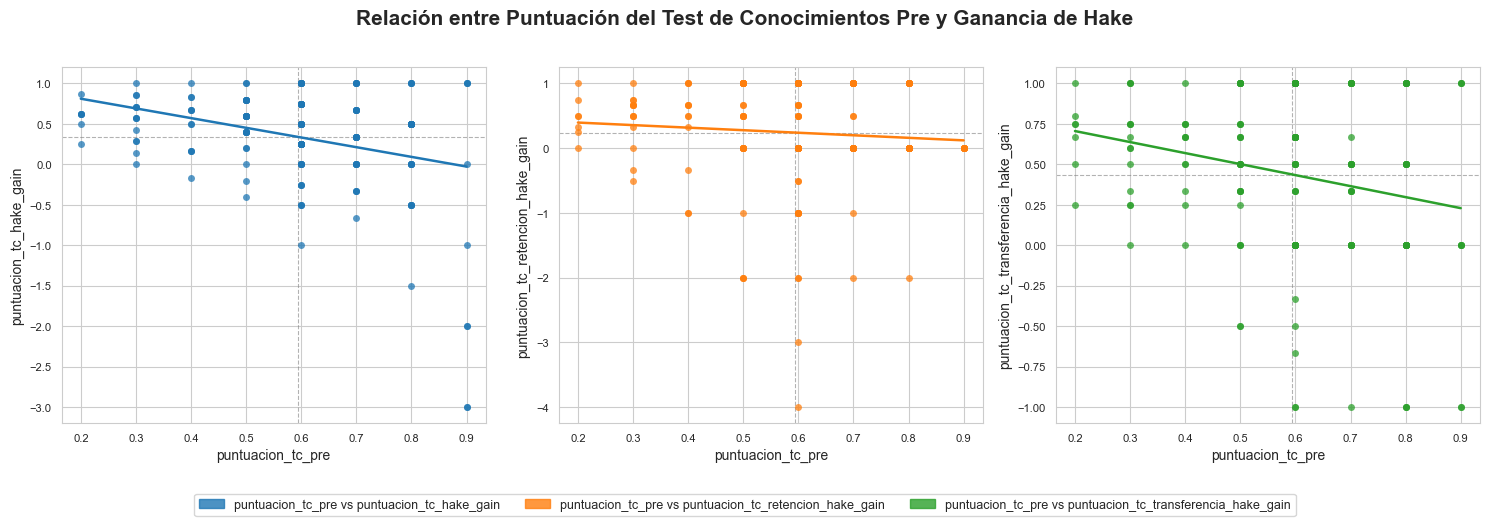

In [332]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tc_pre", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tc_pre", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tc_pre", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title="Relación entre Puntuación del Test de Conocimientos Pre y Ganancia de Hake",
    subplots_title=False,
    corr_annotation=False
)

- Justificación del efecto techo

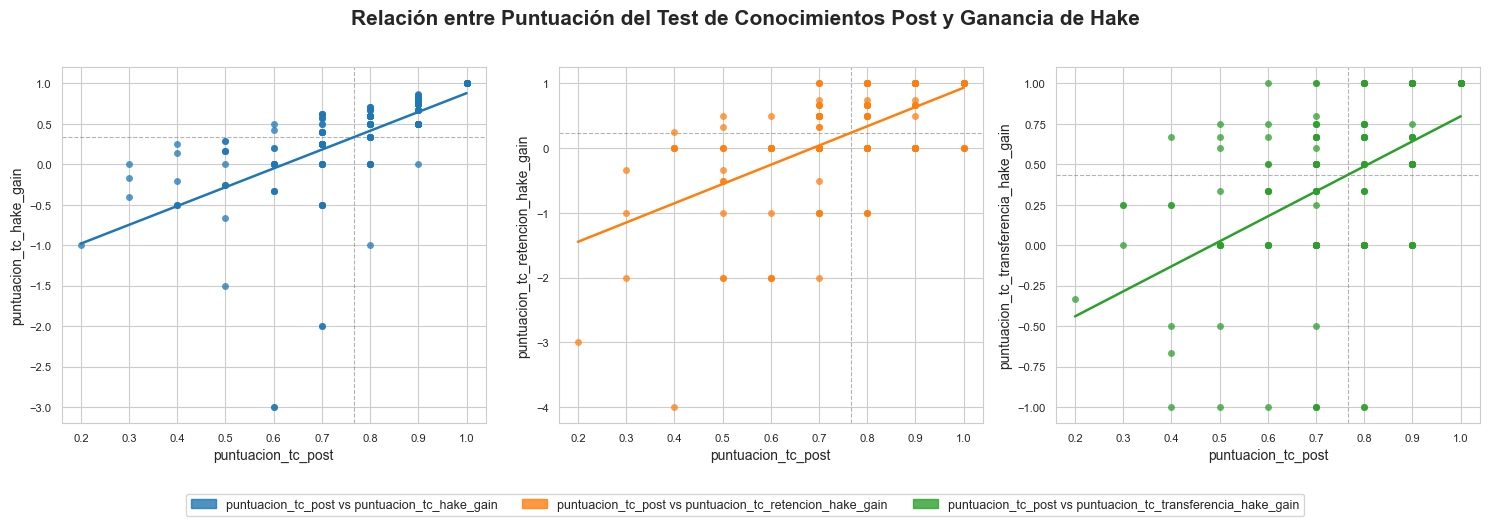

In [333]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tc_post", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tc_post", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tc_post", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title="Relación entre Puntuación del Test de Conocimientos Post y Ganancia de Hake",
    subplots_title=False,
    corr_annotation=False
)

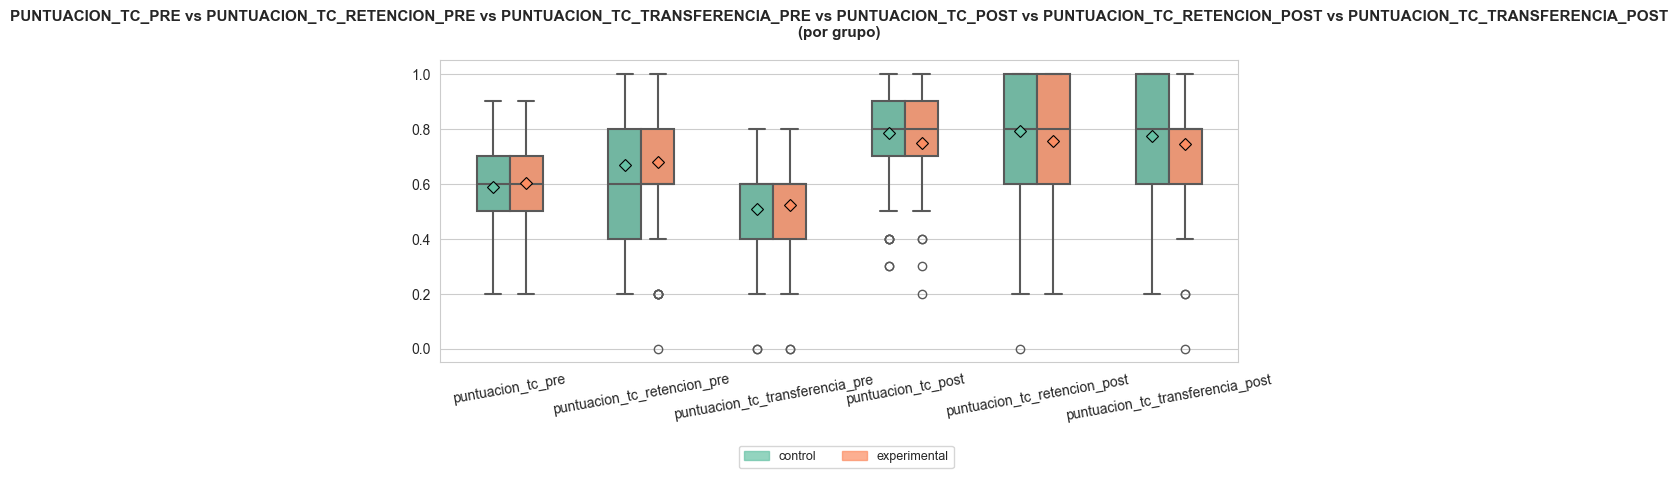

In [334]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_pre", "puntuacion_tc_retencion_pre", "puntuacion_tc_transferencia_pre", "puntuacion_tc_post", "puntuacion_tc_retencion_post", "puntuacion_tc_transferencia_post"],
        #["puntuacion_tc_post", "puntuacion_tc_retencion_post", "puntuacion_tc_transferencia_post"]
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    #sharey="all"
)

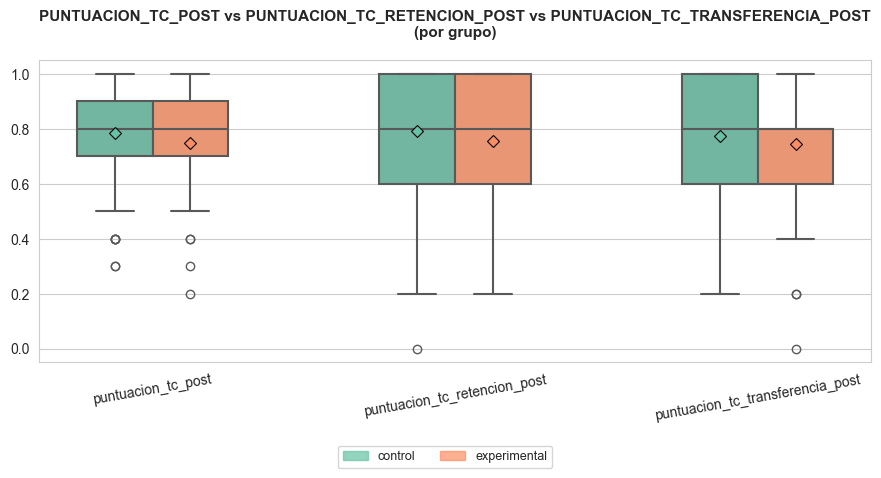

In [335]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_post", "puntuacion_tc_retencion_post", "puntuacion_tc_transferencia_post"]
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

#### Carga Cognitiva 

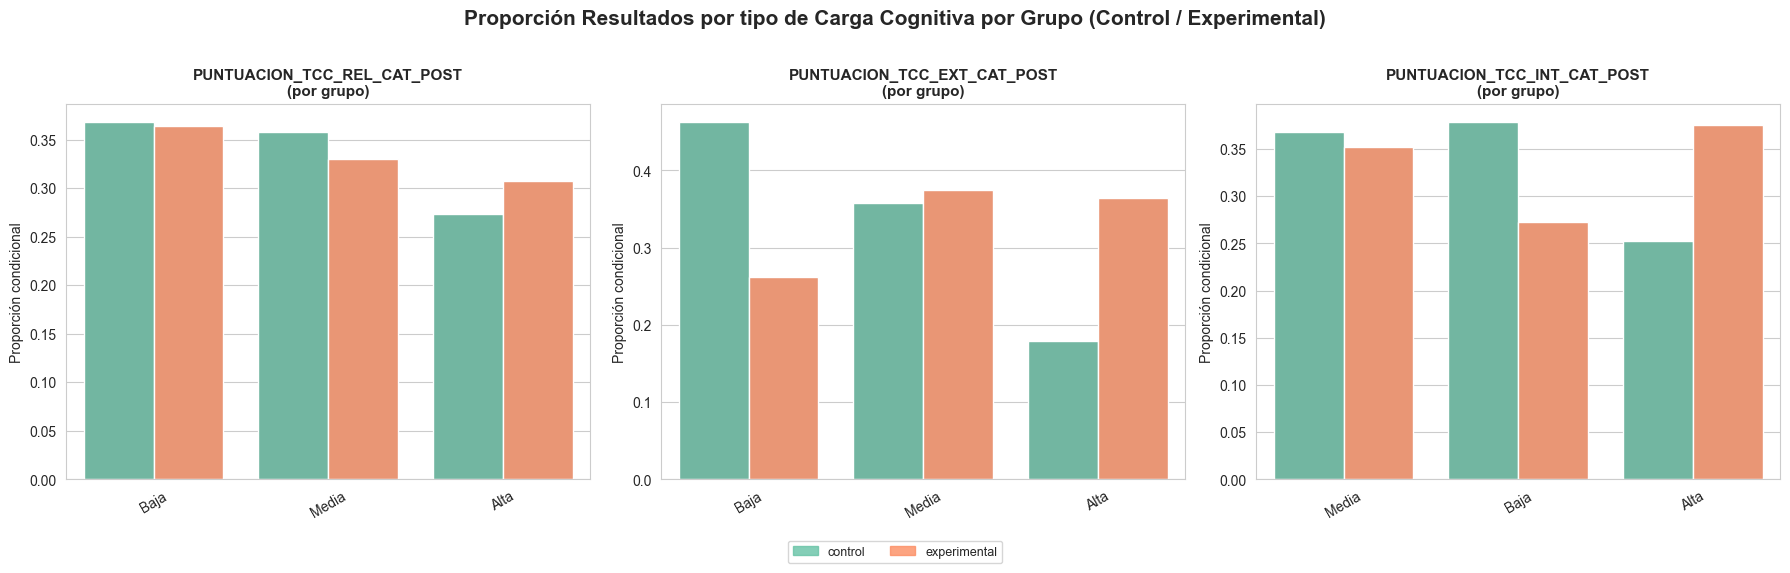

In [336]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tcc_rel_cat_post'], ['puntuacion_tcc_ext_cat_post'], ['puntuacion_tcc_int_cat_post'],
    ], 
    title="Proporción Resultados por tipo de Carga Cognitiva por Grupo (Control / Experimental)",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo',
)

- Justificacion efecto fatiga/fricción/distracción (carga extrinseca) por el uso de la herramienta vs control

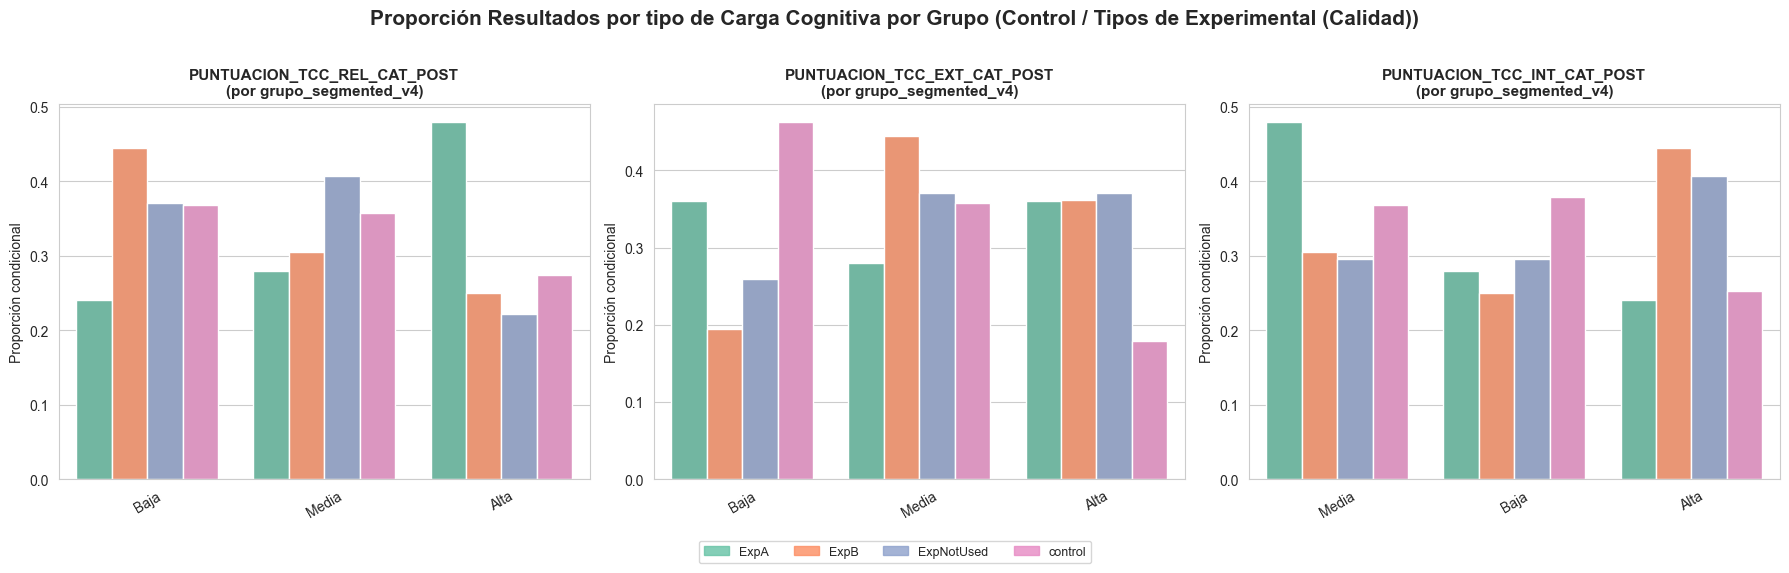

In [337]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tcc_rel_cat_post'], ['puntuacion_tcc_ext_cat_post'], ['puntuacion_tcc_int_cat_post'],
    ], 
    title="Proporción Resultados por tipo de Carga Cognitiva por Grupo (Control / Tipos de Experimental (Calidad))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v4',
)

- Si se usa bien la herramienta, la prob de encontrar/ver/percibir util la herramienta es notablemente superior que si se usa mal o no se usa el chat.

- Uar bien la herramienta favorece la percepcion de utilidad del experimento sobre el control.

- Usar mal o no usar el chat genera una percepción de mayor dificultad en la materia estudiada que aquellos que la usan bien o el control (los cuales están igualados).

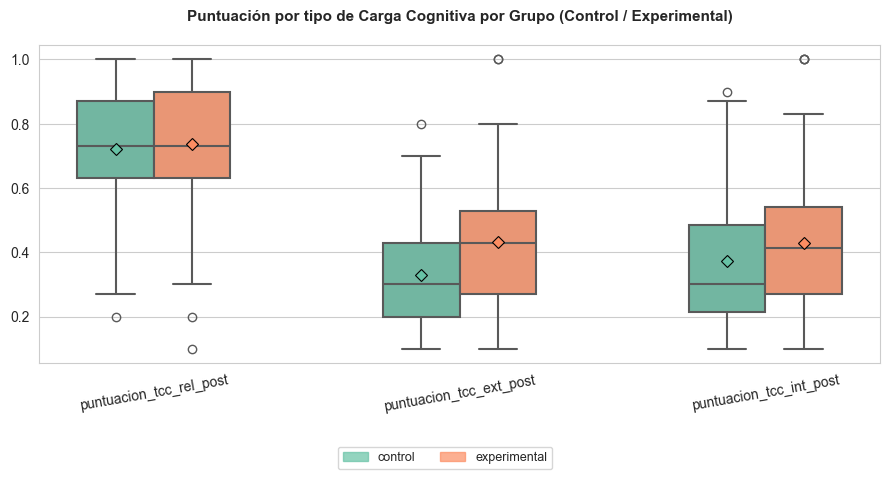

In [338]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_tcc_rel_post', 'puntuacion_tcc_ext_post', 'puntuacion_tcc_int_post']
    ],
    group_by='grupo',
    showfliers=True,
    title="Puntuación por tipo de Carga Cognitiva por Grupo (Control / Experimental)",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

- Justificacion efecto fatiga/fricción/distracción (carga extrinseca) por el uso de la herramienta vs control

- Experimental tiene una percepción de más complejidad del topic, y esto puede venir dado por el efecto fatiga de la herramienta.


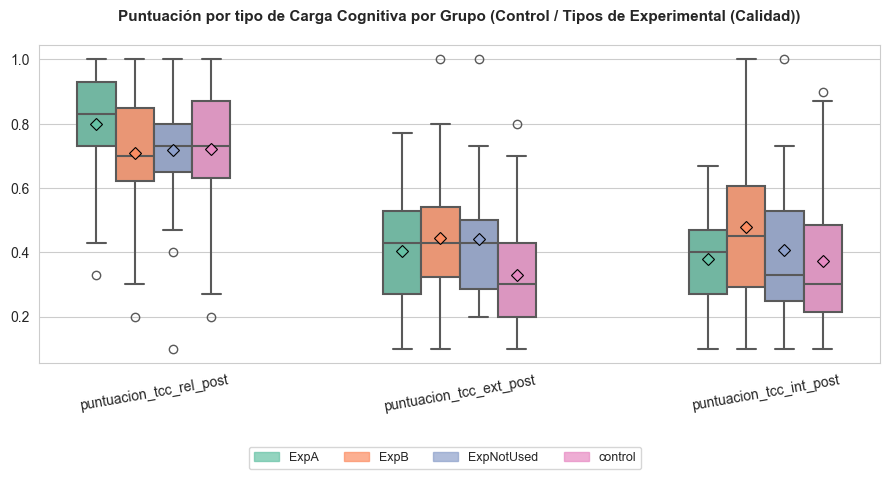

In [339]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_tcc_rel_post', 'puntuacion_tcc_ext_post', 'puntuacion_tcc_int_post']
    ],
    group_by='grupo_segmented_v4',
    showfliers=True,
    title="Puntuación por tipo de Carga Cognitiva por Grupo (Control / Tipos de Experimental (Calidad))",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

- El plot del medio nos indica de nuevo efecto fatiga: cualquier subgrupo dentro del experiemntal percibe una mayor fricción fruto del experimento. El conctacto/exposición a la herramienta fatiga más que ver solo el video (control).

- EN cuanto a carga relevante: aquellos que hacen uso apropiado de la herramienta perciben que el experimento le beneficia para su aprendizaje de forma notablemente mayor que el resto de grupos expperimental, inclusive el control (estando muy parejos).

- Los resultados para la intrinseca son un poco raros, hay que analizarlos con más cautela.

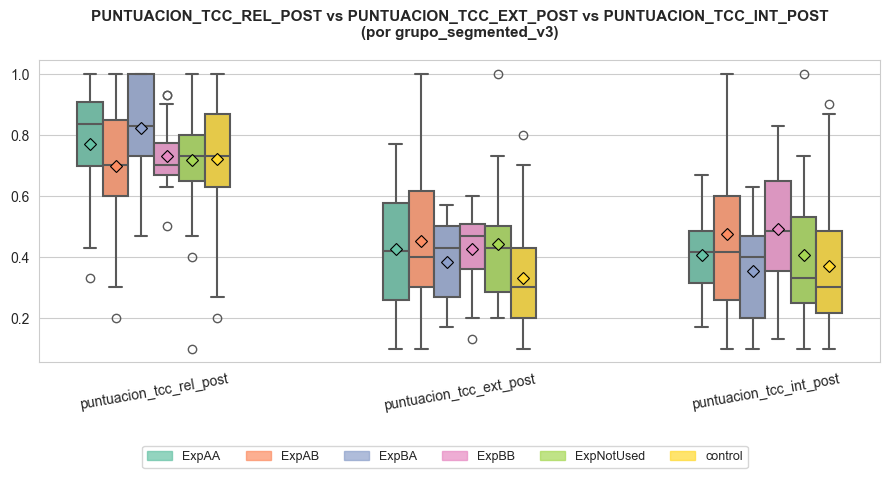

In [340]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_tcc_rel_post', 'puntuacion_tcc_ext_post', 'puntuacion_tcc_int_post']
    ],
    group_by='grupo_segmented_v3',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

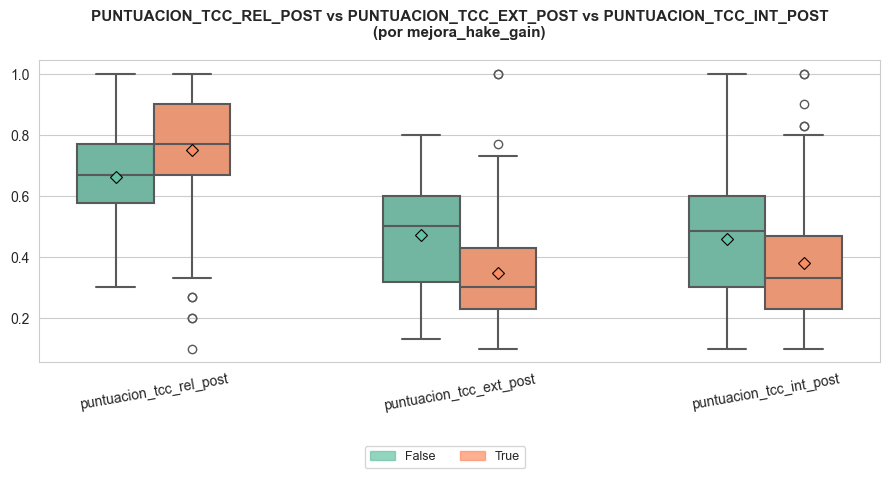

In [341]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_tcc_rel_post', 'puntuacion_tcc_ext_post', 'puntuacion_tcc_int_post']
    ],
    group_by='mejora_hake_gain',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

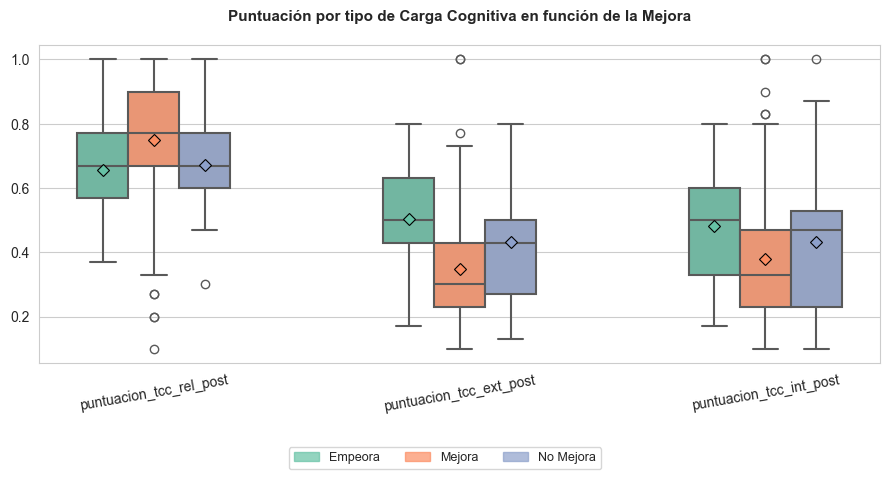

In [342]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_tcc_rel_post', 'puntuacion_tcc_ext_post', 'puntuacion_tcc_int_post']
    ],
    group_by='mejora_hake_gain_v2',
    showfliers=True,
    title="Puntuación por tipo de Carga Cognitiva en función de la Mejora",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

- Los que mejoran encuentran el experimento más relevante, menos fatigador/distractor, y una percepción de menor dificultad del topic.

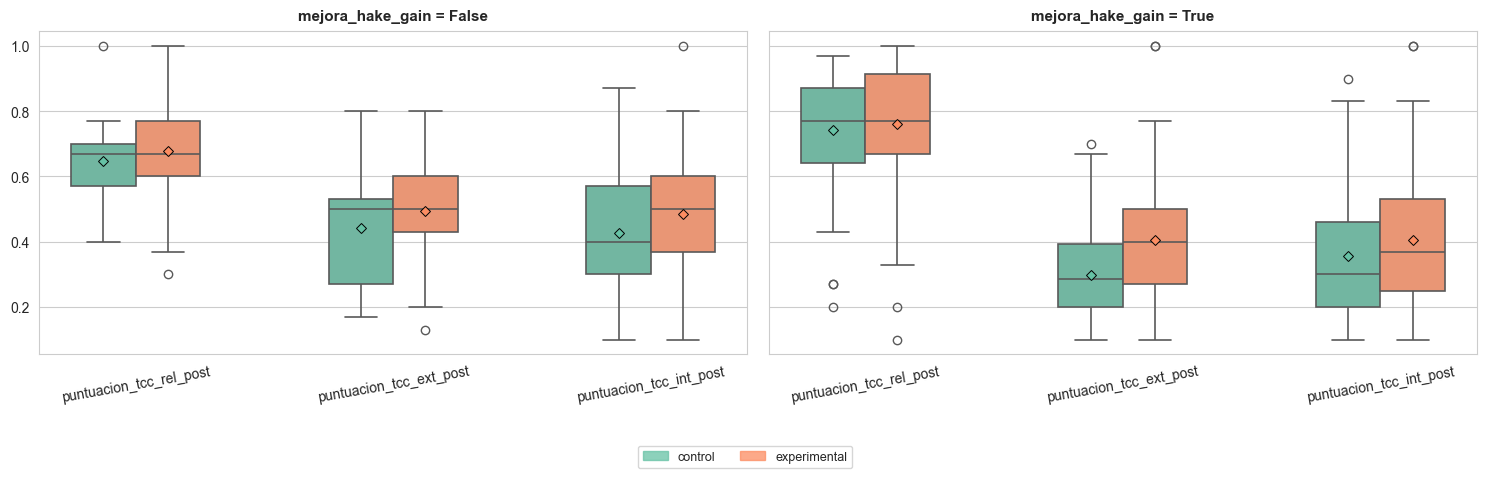

In [343]:
plot_quant_comparison_faceted(
    figsize=(15, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_tcc_rel_post', 'puntuacion_tcc_ext_post', 'puntuacion_tcc_int_post']
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    outer_group_by='mejora_hake_gain'
)

- El patron de interacción entre mejora y TCC observado antes se mantiene tbn a nivel de grupos (exp/control)

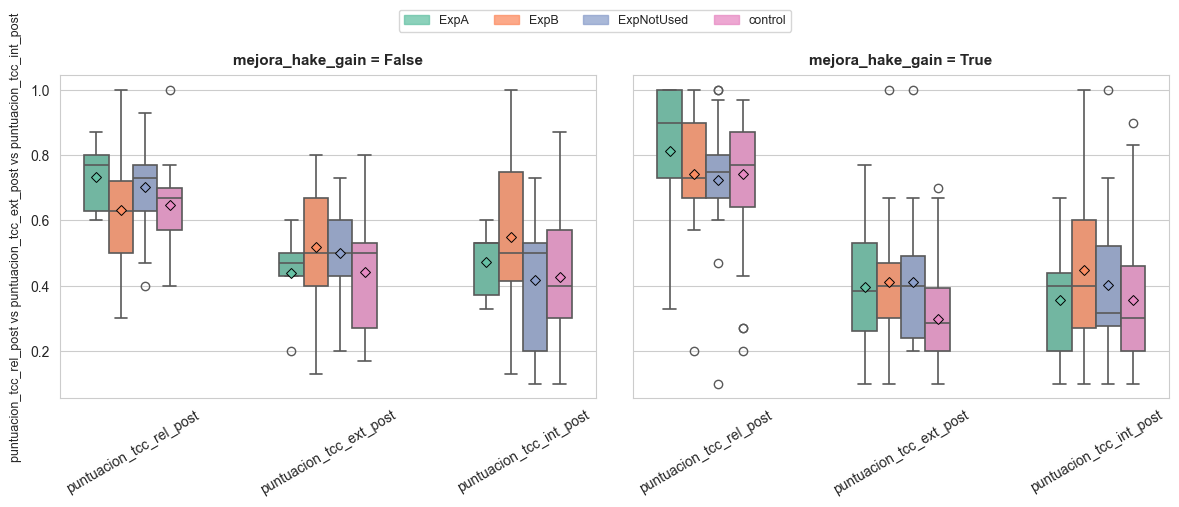

In [344]:
plot_quant_comparison_faceted(
    forms_interactions_df,
    figsize=(12, 4),
    comparisons=[
        ['puntuacion_tcc_rel_post', 'puntuacion_tcc_ext_post', 'puntuacion_tcc_int_post']
    ],
    outer_group_by="mejora_hake_gain",
    group_by="grupo_segmented_v4",            
    palette="Set2",
    showfliers=True,
    bbox_to_anchor=(0.5, 1),
    sharey="all"
)

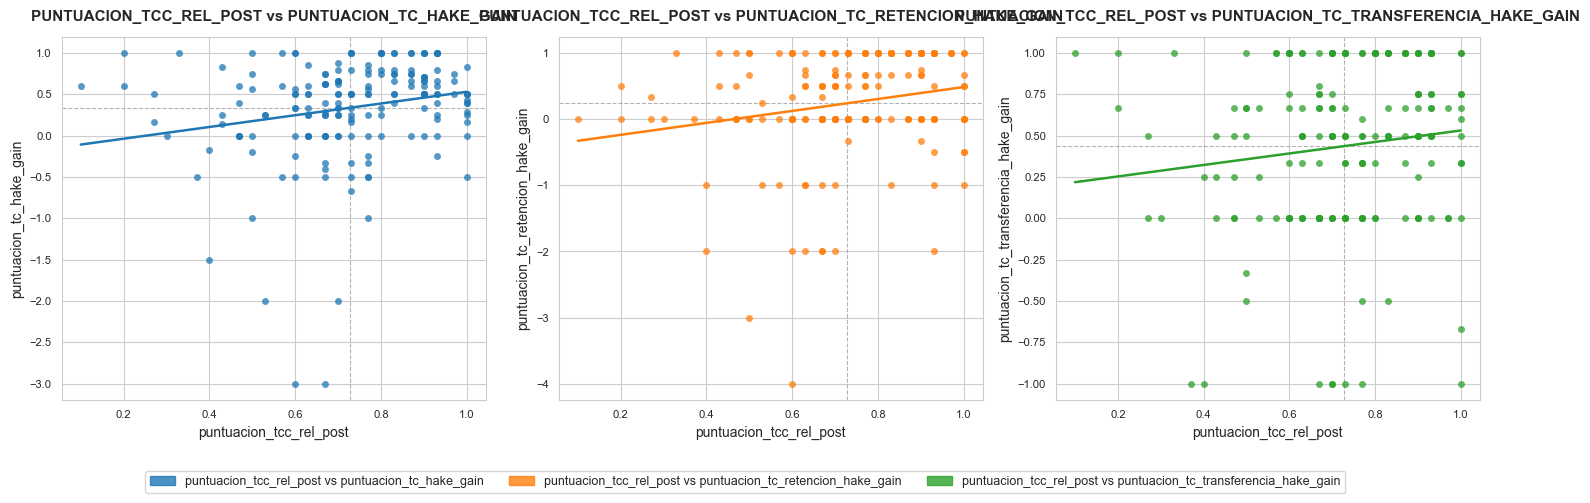

In [345]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tcc_rel_post", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tcc_rel_post", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tcc_rel_post", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

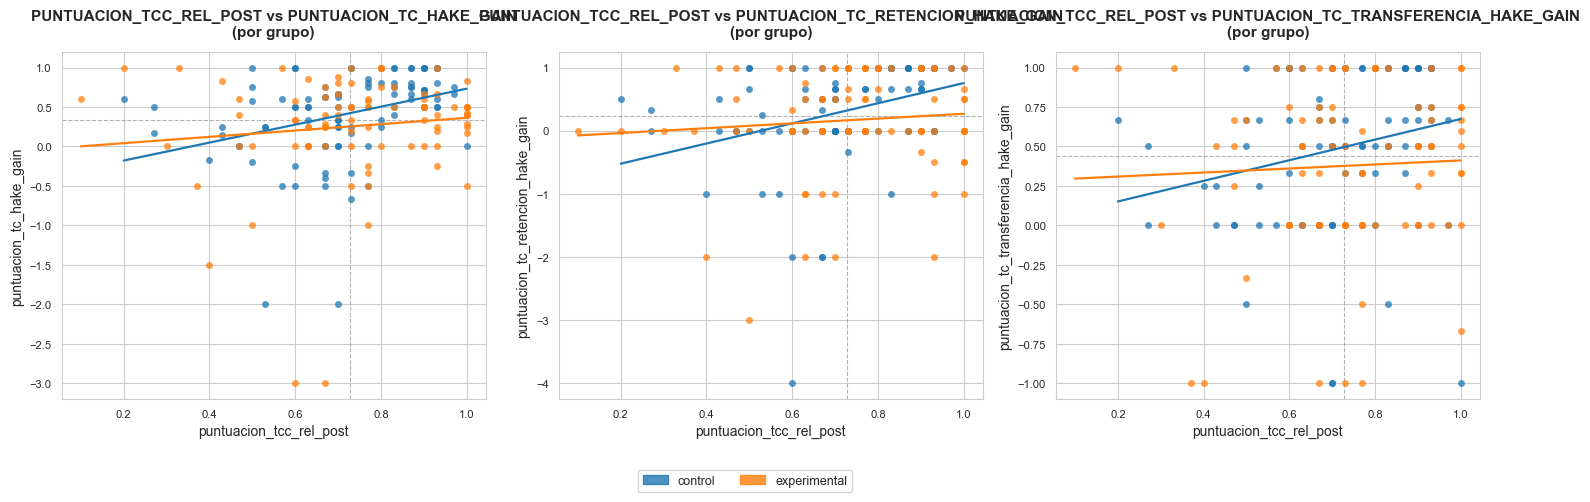

In [346]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tcc_rel_post", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tcc_rel_post", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tcc_rel_post", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    group_by='grupo'
)

- El efecto de la carga relevante sobre la ganancia no es siginificativo para el  grupo experimental (pendiente casi nula).

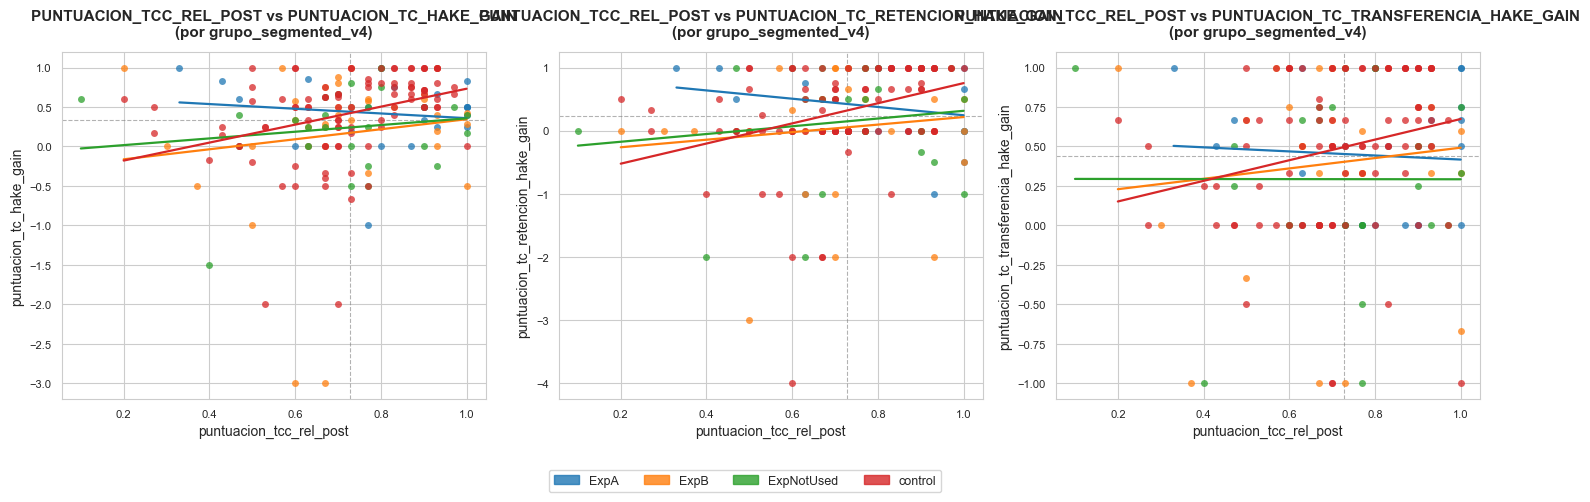

In [347]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tcc_rel_post", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tcc_rel_post", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tcc_rel_post", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    group_by='grupo_segmented_v4'
)

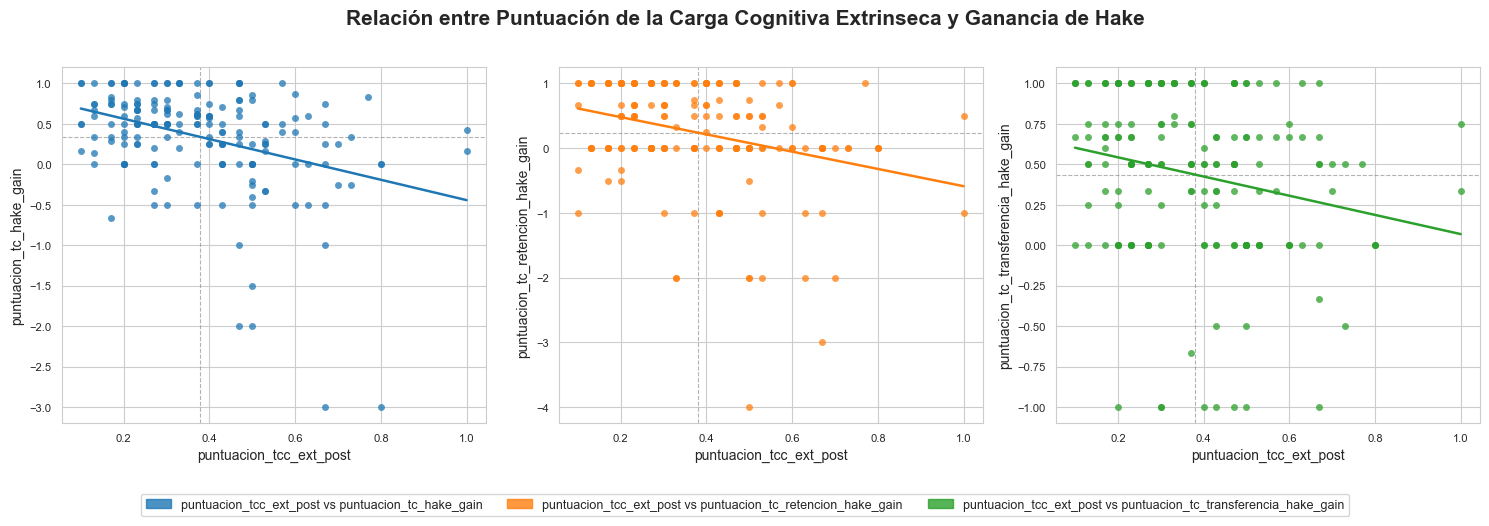

In [348]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tcc_ext_post", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tcc_ext_post", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tcc_ext_post", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title="Relación entre Puntuación de la Carga Cognitiva Extrinseca y Ganancia de Hake",
    subplots_title=False,
    corr_annotation=False
)

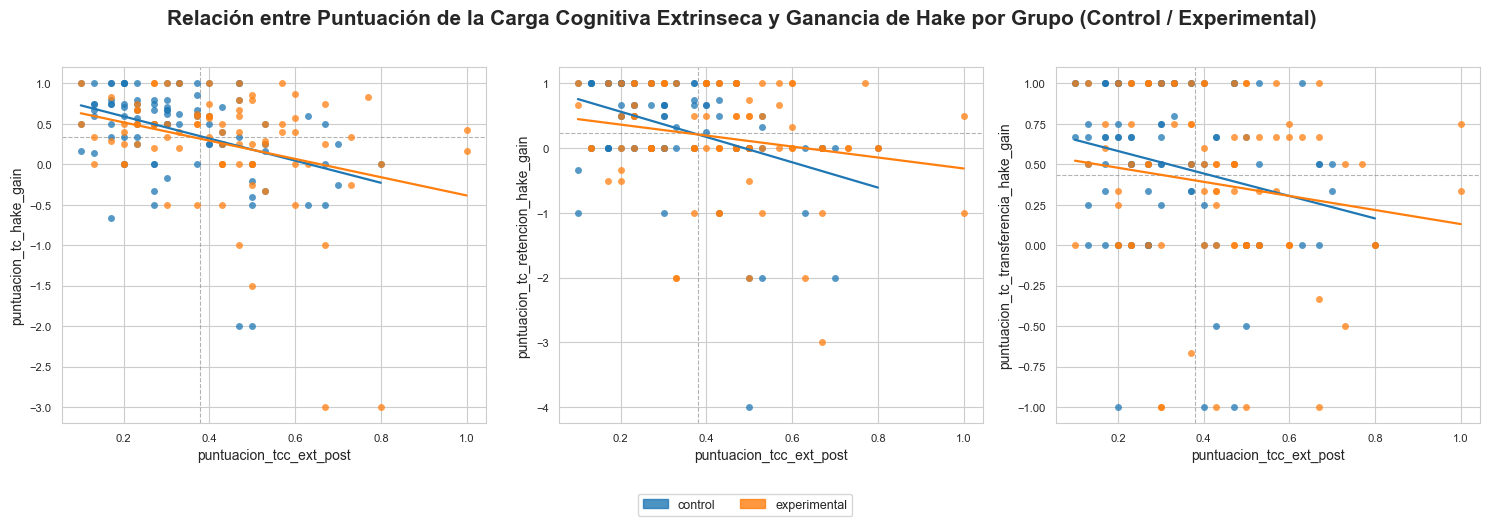

In [349]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tcc_ext_post", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tcc_ext_post", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tcc_ext_post", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title="Relación entre Puntuación de la Carga Cognitiva Extrinseca y Ganancia de Hake por Grupo (Control / Experimental) ",
    subplots_title=False,
    corr_annotation=False,
    group_by='grupo',
)

- Efecto muy similar en ambos grupos

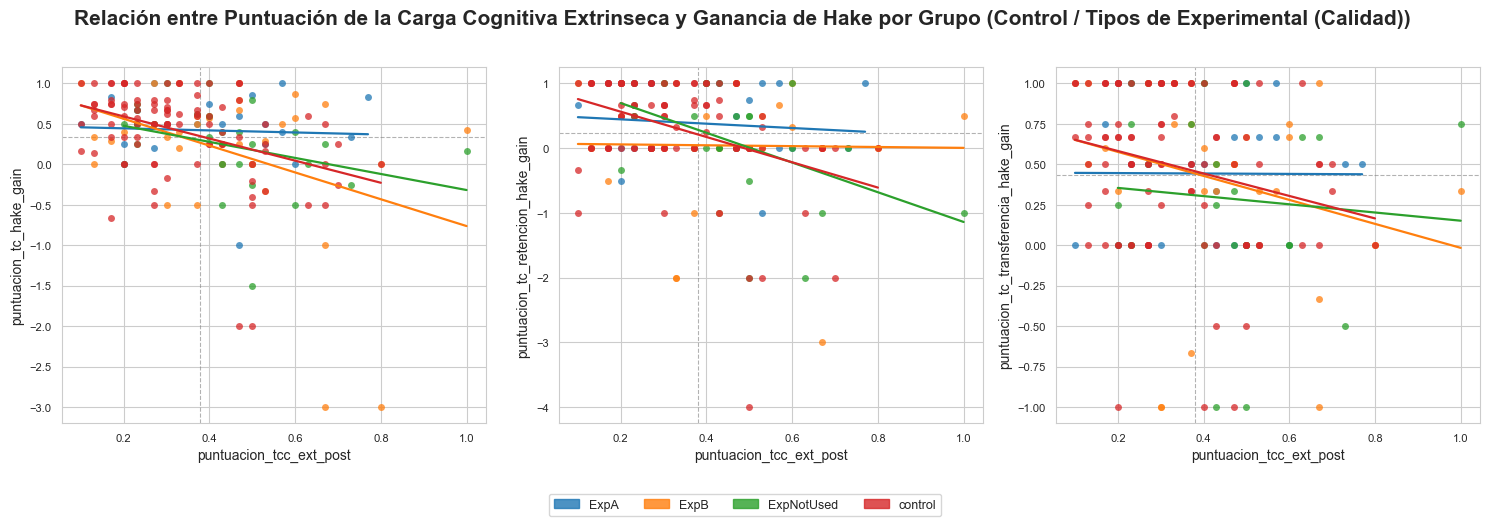

In [350]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tcc_ext_post", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tcc_ext_post", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tcc_ext_post", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    title="Relación entre Puntuación de la Carga Cognitiva Extrinseca y Ganancia de Hake por Grupo (Control / Tipos de Experimental (Calidad)) ",
    subplots_title=False,
    group_by='grupo_segmented_v4'
)

- Los usuarios que usan bien la herramienta están blindados ante la carga extrinseca (fatiga por uso herramienta), no les afecta a su ganancia de conociminetos. En el resto de casos si, y negativamente.

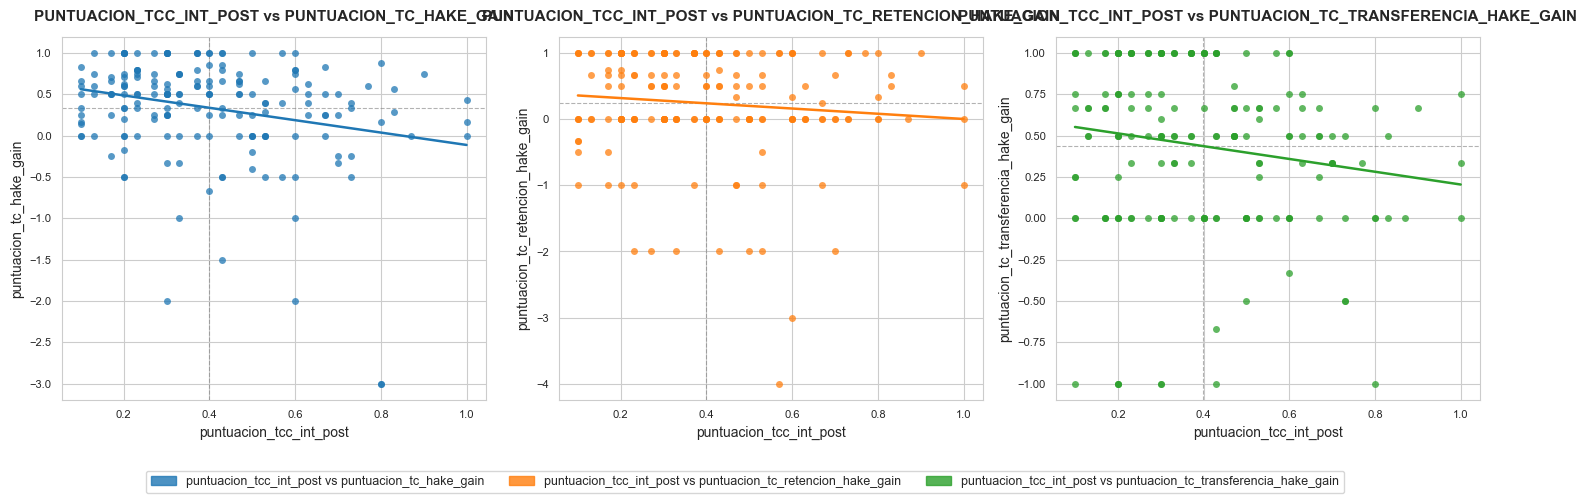

In [351]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tcc_int_post", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tcc_int_post", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tcc_int_post", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

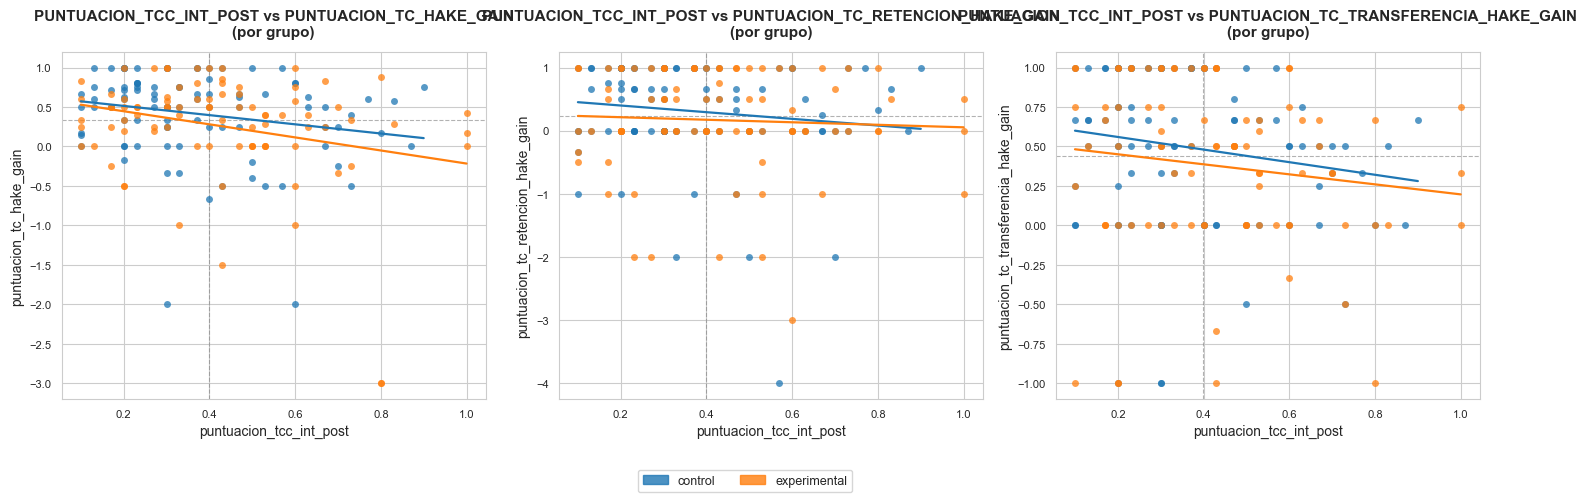

In [352]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tcc_int_post", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_tcc_int_post", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_tcc_int_post", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    group_by='grupo'
)

#### Autoeficacia Pre-Post

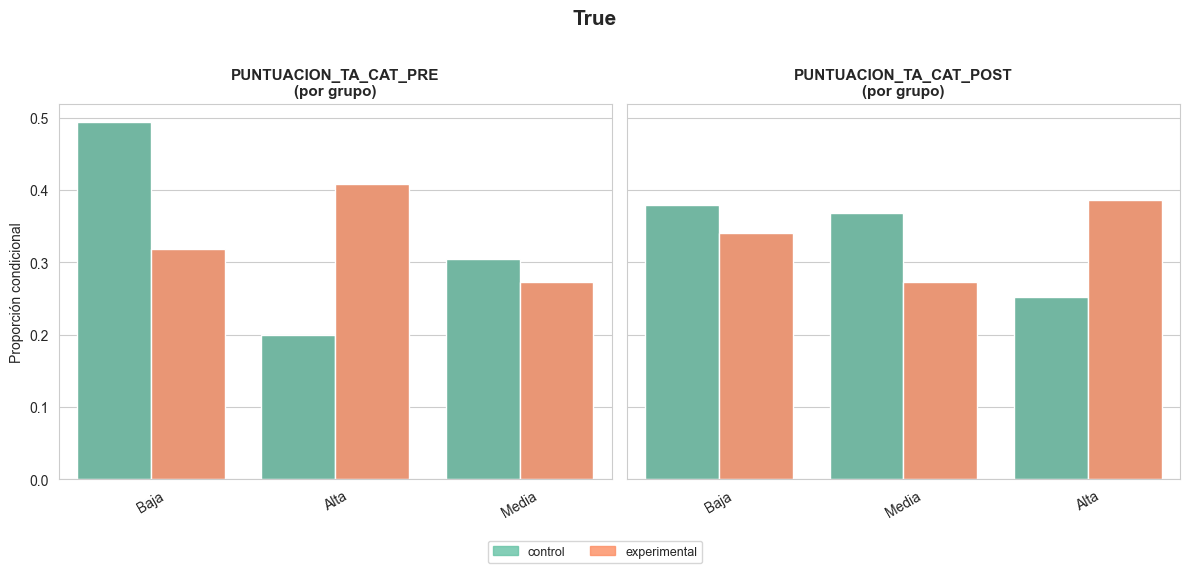

In [353]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_ta_cat_pre'], ['puntuacion_ta_cat_post'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo',
    sharey=True
)

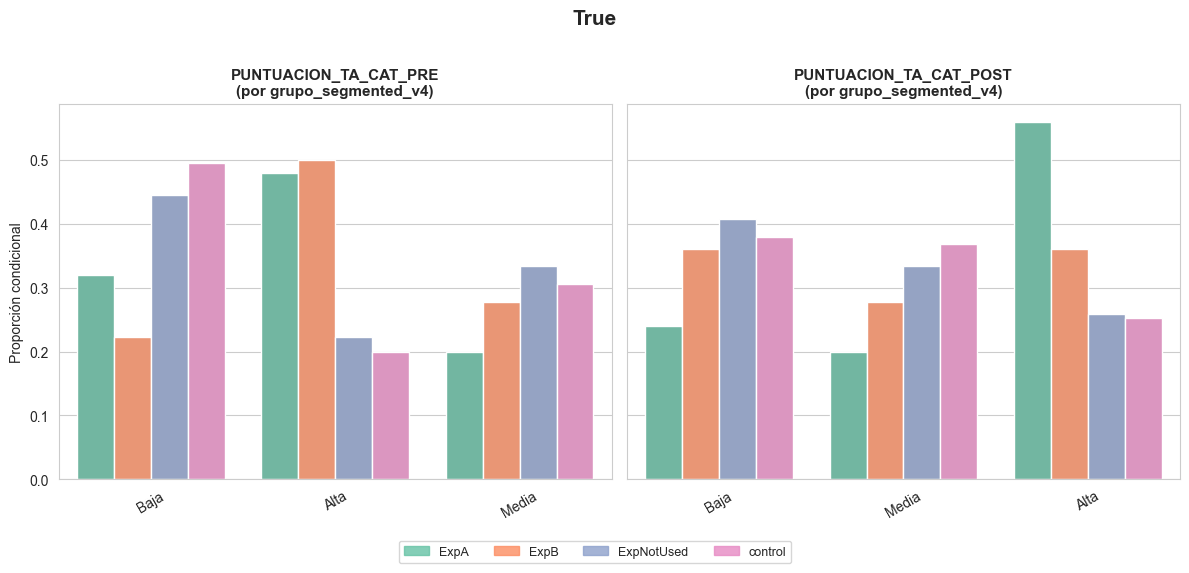

In [354]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_ta_cat_pre'], ['puntuacion_ta_cat_post'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v4',
    sharey=True
)

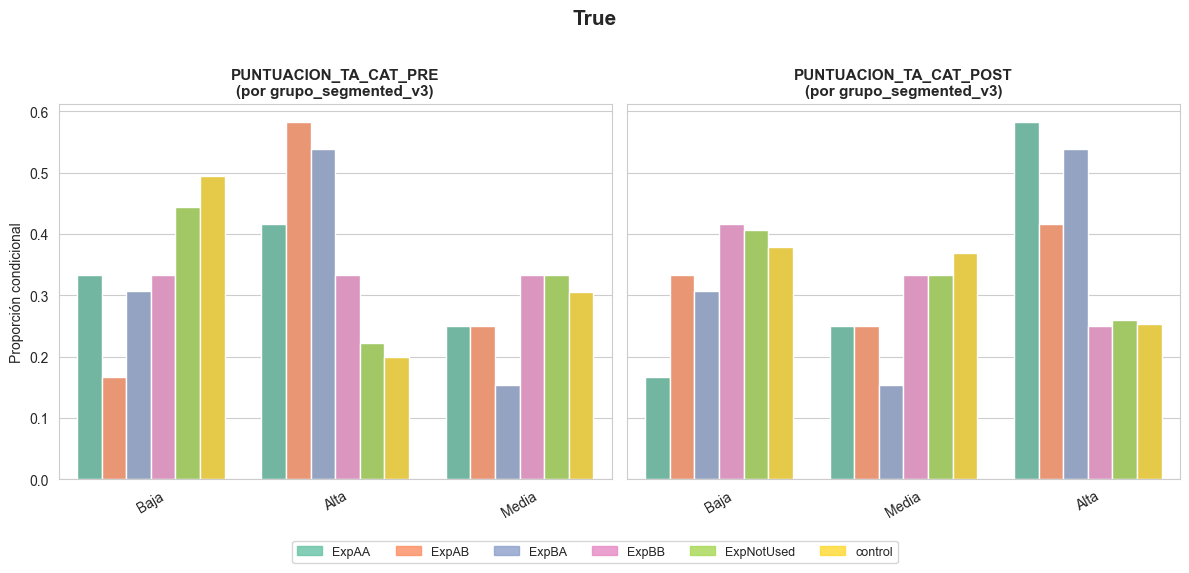

In [355]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_ta_cat_pre'], ['puntuacion_ta_cat_post'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v3',
    sharey=True
)

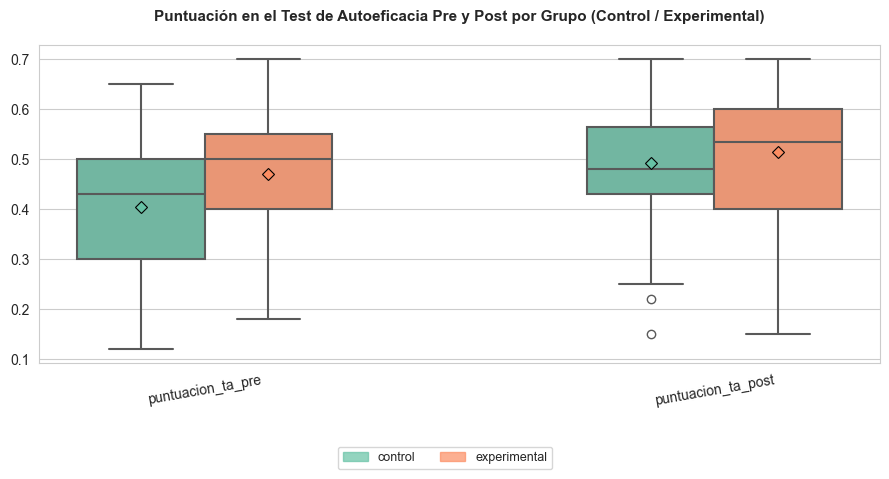

In [356]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_ta_pre', 'puntuacion_ta_post']
    ],
    group_by='grupo',
    showfliers=True,
    title="Puntuación en el Test de Autoeficacia Pre y Post por Grupo (Control / Experimental)",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

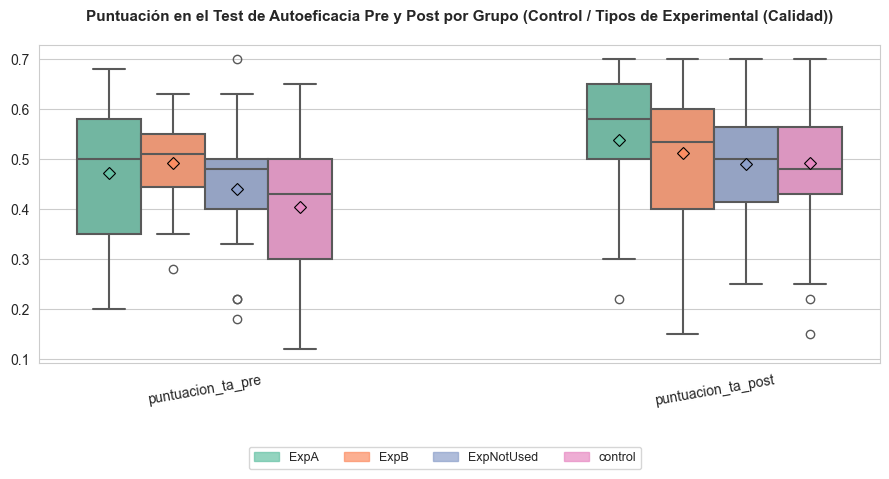

In [357]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_ta_pre', 'puntuacion_ta_post']
    ],
    group_by='grupo_segmented_v4',
    showfliers=True,
    title="Puntuación en el Test de Autoeficacia Pre y Post por Grupo (Control / Tipos de Experimental (Calidad))",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

- Efecto speech Rosa

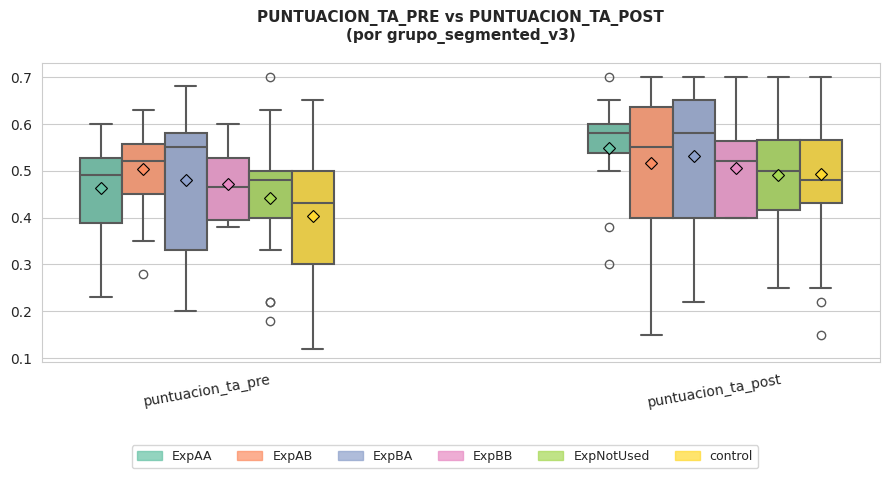

In [113]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_ta_pre', 'puntuacion_ta_post']
    ],
    group_by='grupo_segmented_v3',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

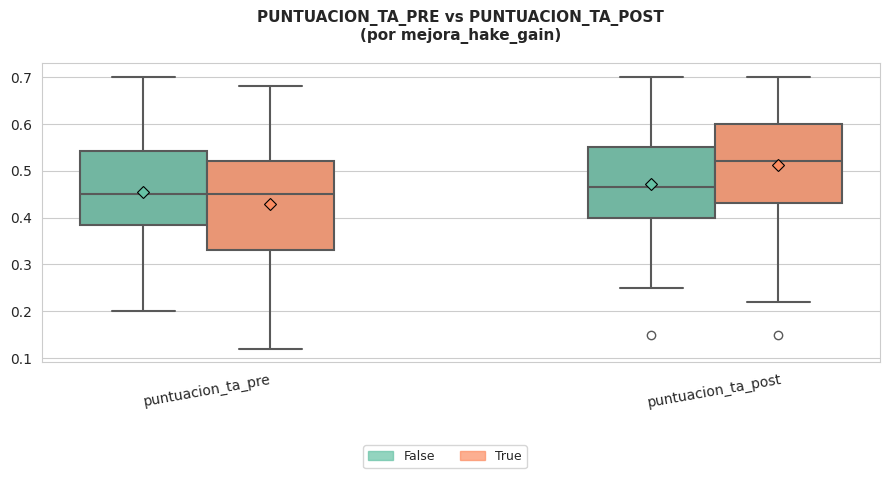

In [114]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['puntuacion_ta_pre', 'puntuacion_ta_post']
    ],
    group_by='mejora_hake_gain',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

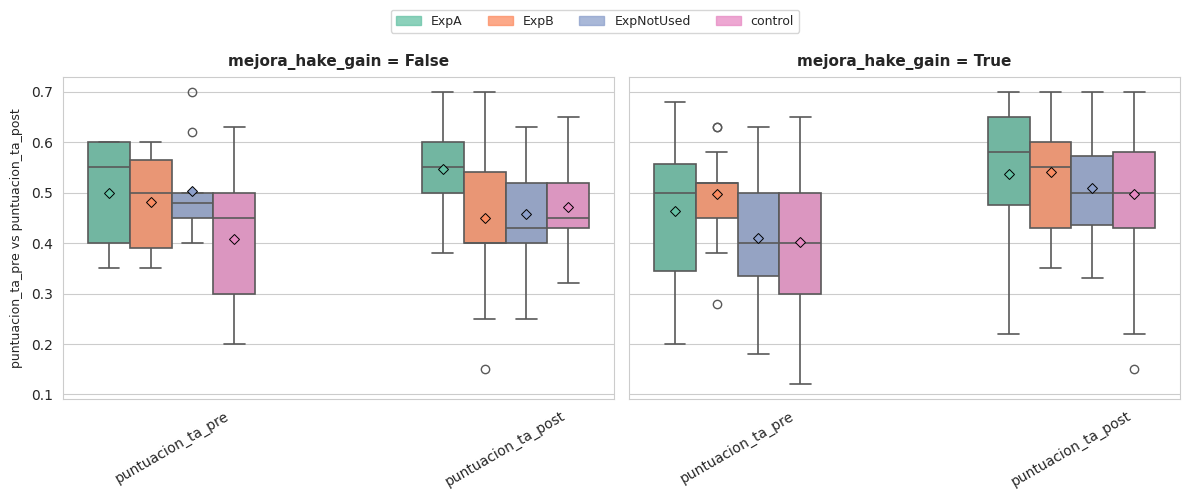

In [115]:
plot_quant_comparison_faceted(
    forms_interactions_df,
    figsize=(12, 4),
    comparisons=[
        ['puntuacion_ta_pre', 'puntuacion_ta_post']
    ],
    outer_group_by="mejora_hake_gain",
    group_by="grupo_segmented_v4",            
    palette="Set2",
    showfliers=True,
    bbox_to_anchor=(0.5, 1),
    sharey="all"
)

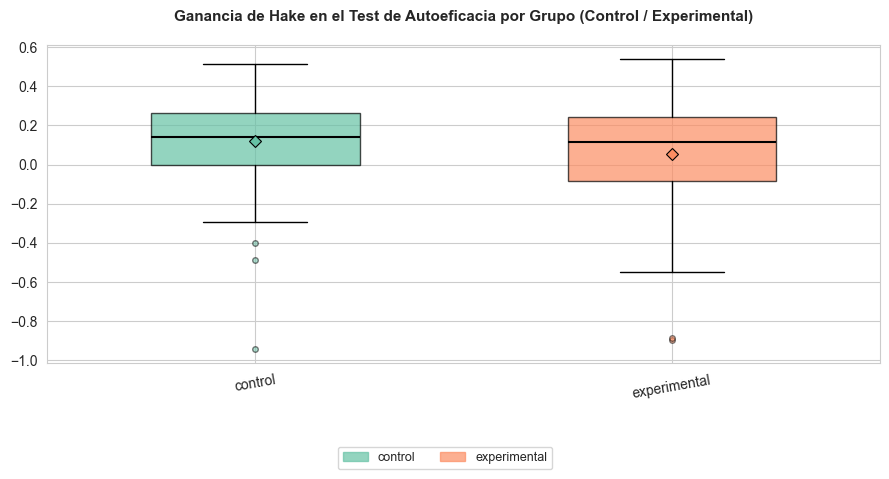

In [369]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_ta_hake_gain"]
    ],
    group_by='grupo',
    showfliers=True,
    title="Ganancia de Hake en el Test de Autoeficacia por Grupo (Control / Experimental)",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

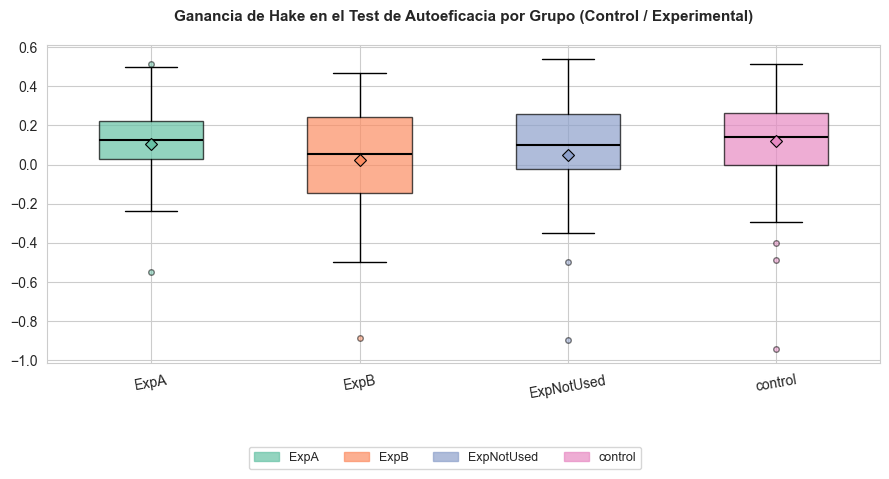

In [370]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        ["puntuacion_ta_hake_gain"]
    ],
    group_by='grupo_segmented_v4',
    showfliers=True,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title="Ganancia de Hake en el Test de Autoeficacia por Grupo (Control / Experimental)",
    figsize=(9,4)
)

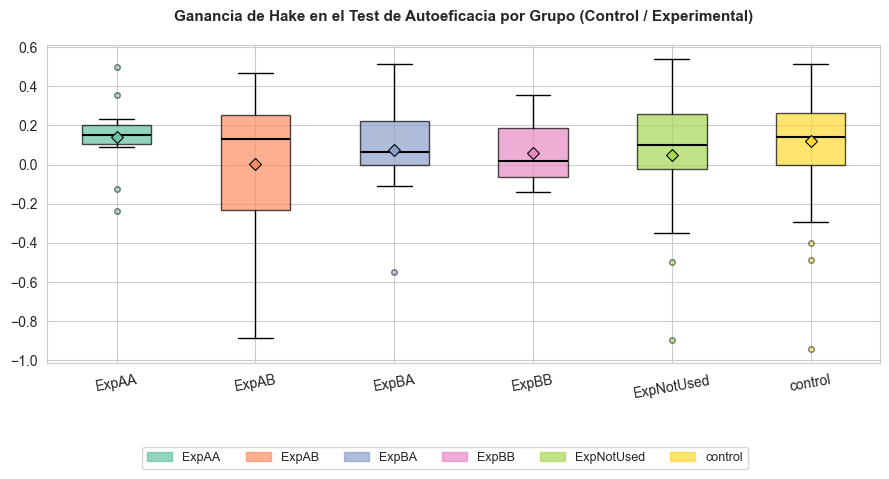

In [371]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        ["puntuacion_ta_hake_gain"]
    ],
    group_by='grupo_segmented_v3',
    showfliers=True,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title="Ganancia de Hake en el Test de Autoeficacia por Grupo (Control / Experimental)",
    figsize=(9,4)
)

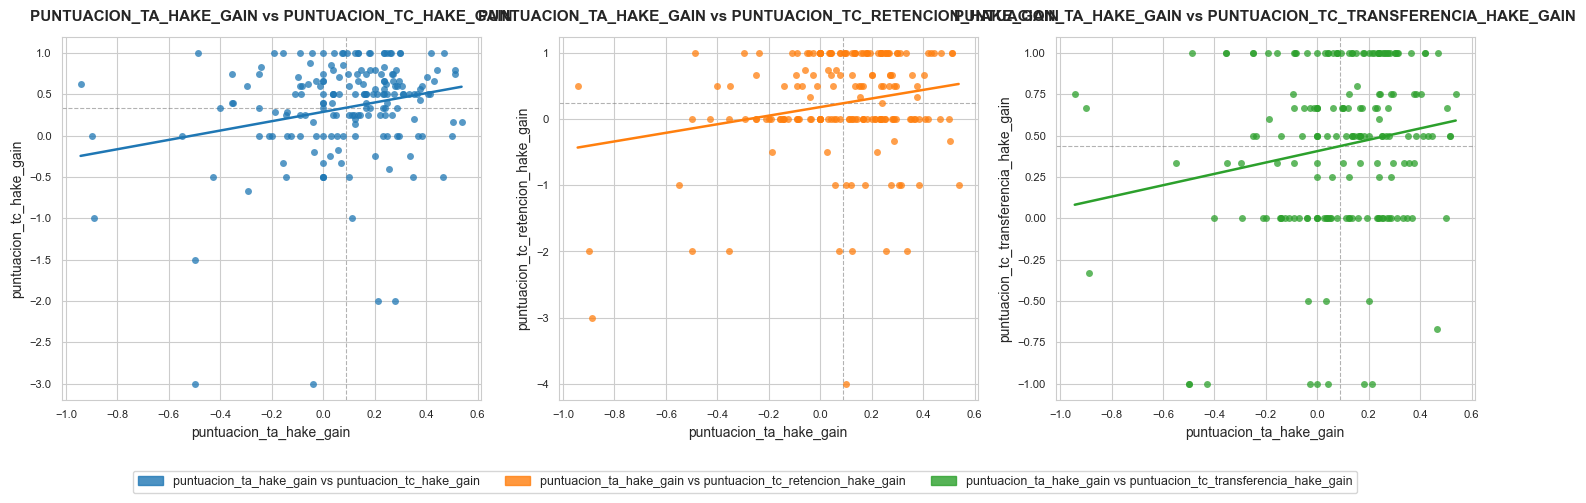

In [372]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_ta_hake_gain", "puntuacion_tc_hake_gain"), 
                 ("puntuacion_ta_hake_gain", "puntuacion_tc_retencion_hake_gain"),
                 ("puntuacion_ta_hake_gain", "puntuacion_tc_transferencia_hake_gain")],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

#### Chat Evaluador

In [ ]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['evaluation_pass'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    group_by='WSDI_cat_v2',
)

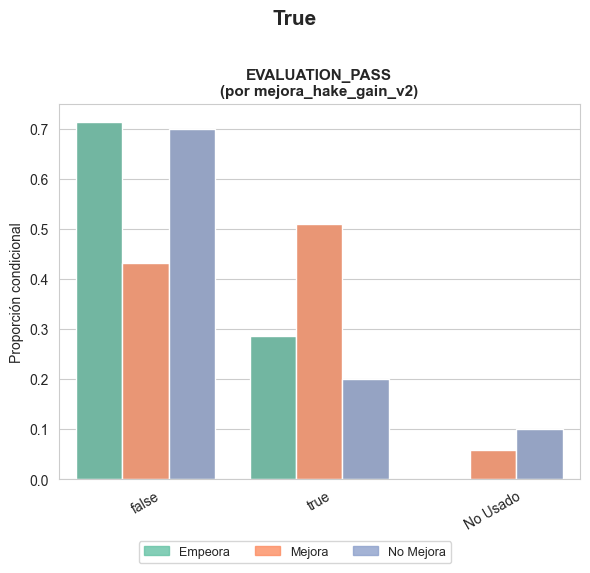

In [ ]:
cheating_filtered = forms_interactions_df.filter(
    pl.col('WSDI_cat_v2') != 'Cheating',
    pl.col("grupo") == "experimental",
).with_columns(
    pl.col("evaluation_pass").fill_null("No Usado").cast(pl.String),
)

plot_cat_comparison(
    df=cheating_filtered, 
    comparisons=[
        ['evaluation_pass'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    group_by='mejora_hake_gain_v2',
)


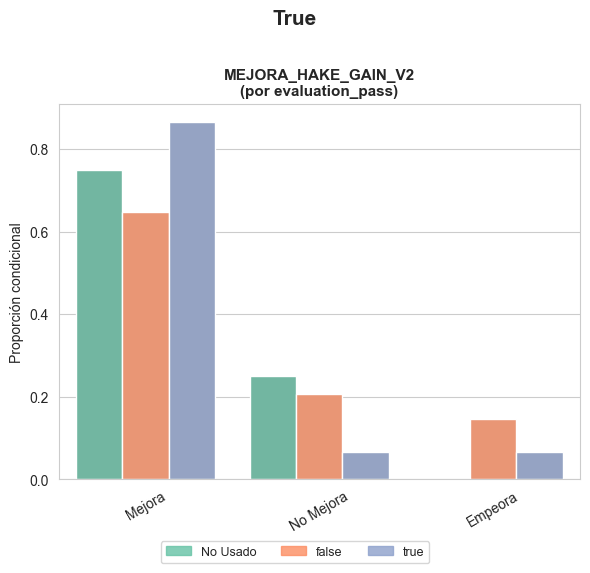

In [473]:
plot_cat_comparison(
    df=cheating_filtered, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    group_by='evaluation_pass',
)

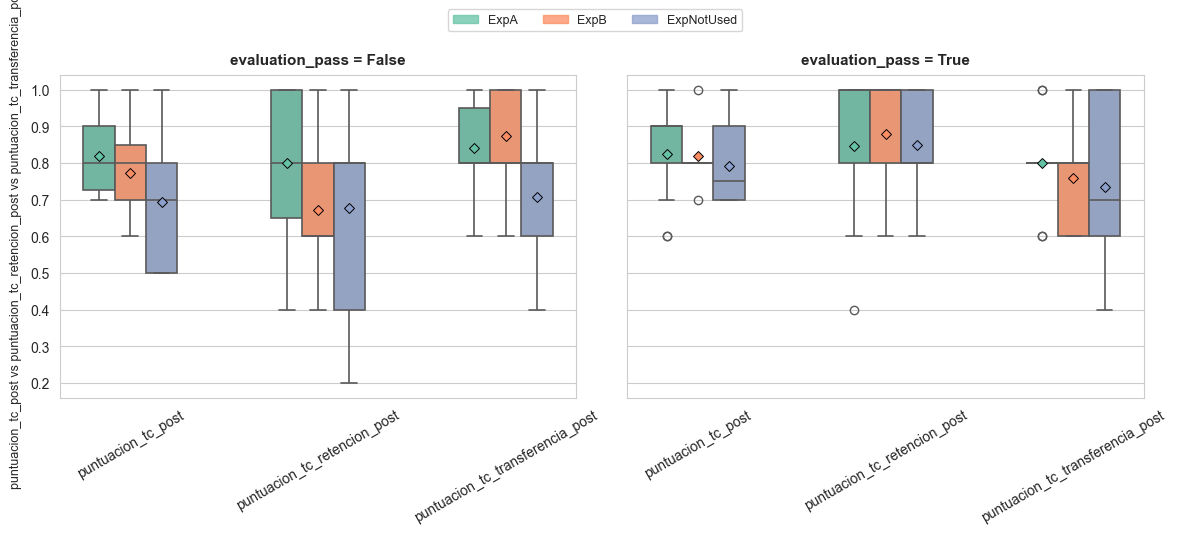

In [461]:
plot_quant_comparison_faceted(
    cheating_filtered,
    figsize=(12, 4),
    comparisons=[
        ["puntuacion_tc_post", "puntuacion_tc_retencion_post", "puntuacion_tc_transferencia_post"]
    ],
    outer_group_by="evaluation_pass",
    group_by="experimental_type_v4",            
    palette="Set2",
    showfliers=True,
    bbox_to_anchor=(0.5, 1),
    sharey="all"
)

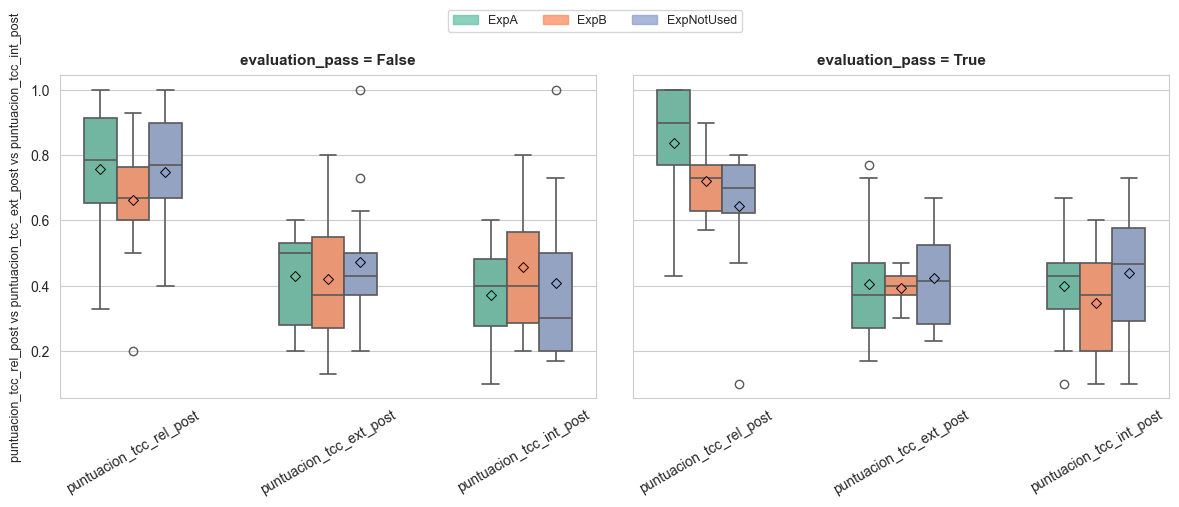

In [462]:
plot_quant_comparison_faceted(
    cheating_filtered,
    figsize=(12, 4),
    comparisons=[
        ['puntuacion_tcc_rel_post', 'puntuacion_tcc_ext_post', 'puntuacion_tcc_int_post']
    ],
    outer_group_by="evaluation_pass",
    group_by="experimental_type_v4",            
    palette="Set2",
    showfliers=True,
    bbox_to_anchor=(0.5, 1),
    sharey="all"
)

#### WSDI 

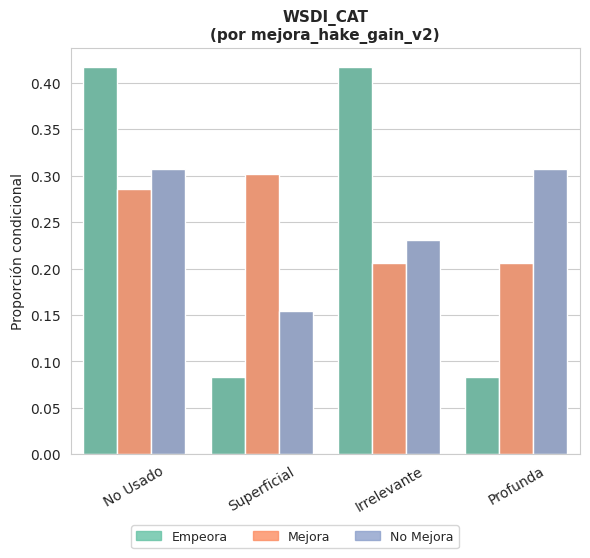

In [116]:
plot_cat_comparison(
    df=forms_interactions_df.with_columns(
        pl.col('mejora_hake_gain').cast(pl.String)
    ).filter(
        pl.col('grupo') == 'experimental',
    ), 
    comparisons=[
        ['WSDI_cat'],
    ], 
    #title=True,
    bbox_to_anchor=(0.5,-0.12),
    group_by='mejora_hake_gain_v2',
)

TO DO: re-ordenar las categoriías mejor

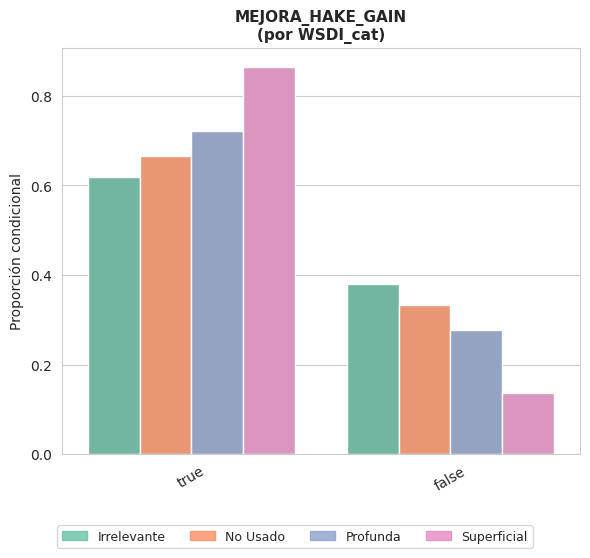

In [117]:
plot_cat_comparison(
    df=forms_interactions_df.with_columns(
        pl.col('mejora_hake_gain').cast(pl.String)
    ).filter(
        pl.col('grupo') == 'experimental',
    ), 
    comparisons=[
        ['mejora_hake_gain'],
    ], 
    #title=True,
    bbox_to_anchor=(0.5,-0.12),
    group_by='WSDI_cat',
)

---

TO DO: Internat cruzar notas pre y uso profundo, para detectar efecto techo, y con ello justificar la menor capacidad de mejora.

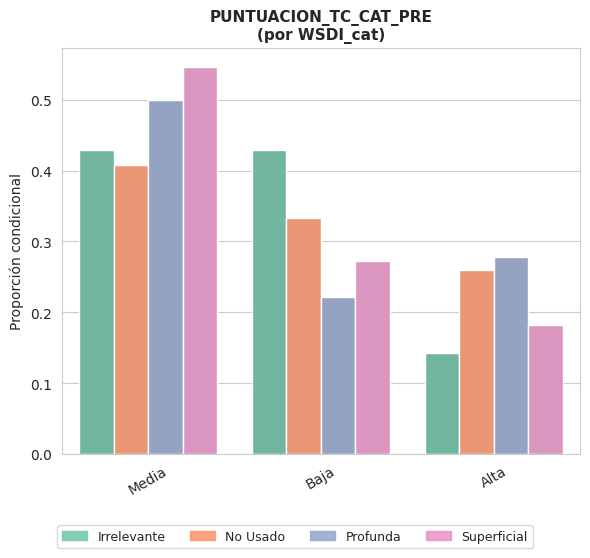

In [ ]:
plot_cat_comparison(
    df=forms_interactions_df.with_columns(
        pl.col('mejora_hake_gain').cast(pl.String)
    ).filter(
        pl.col('grupo') == 'experimental',
    ), 
    comparisons=[
        ['puntuacion_tc_cat_pre'],
    ], 
    #title=True,
    bbox_to_anchor=(0.5,-0.12),
    group_by='WSDI_cat',
)

---

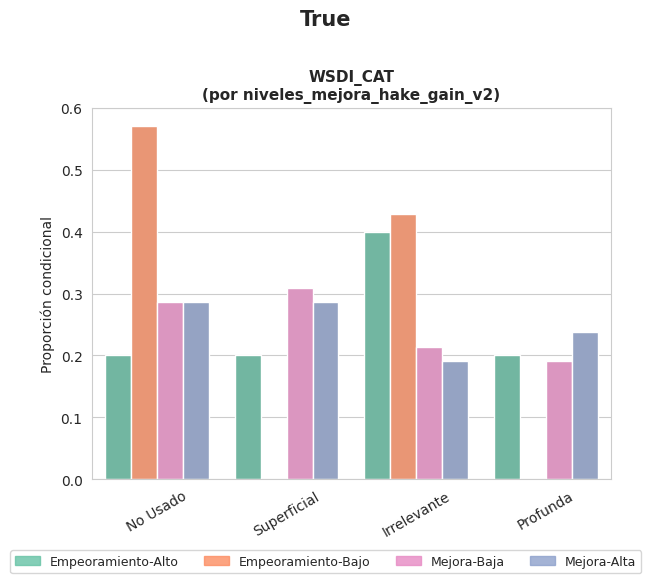

In [119]:
plot_cat_comparison(
    df=forms_interactions_df.with_columns(
        pl.col('mejora_hake_gain').cast(pl.String)
    ).filter(
        pl.col('grupo') == 'experimental',
    ), 
    comparisons=[
        ['WSDI_cat'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.12),
    group_by='niveles_mejora_hake_gain_v2',
    hue_order=['Empeoramiento-Alto', 'Empeoramiento-Bajo', 'Mejora-Baja', 'Mejora-Alta']
)

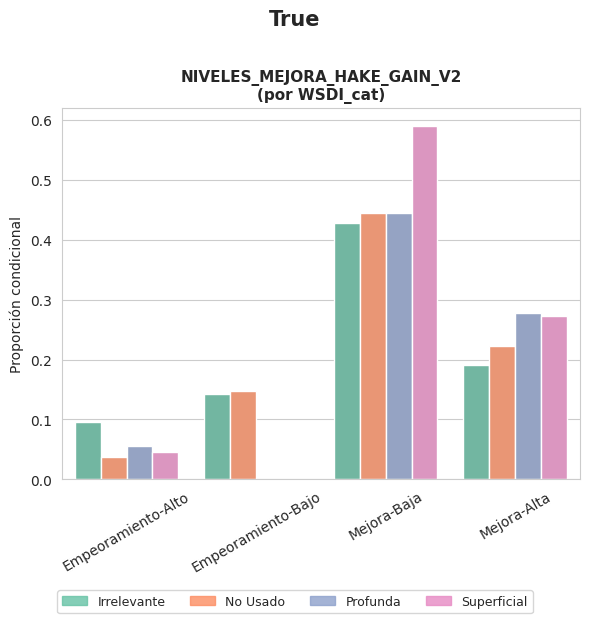

In [120]:
plot_cat_comparison(
    df=forms_interactions_df.with_columns(
        pl.col('mejora_hake_gain').cast(pl.String)
    ).filter(
        pl.col('grupo') == 'experimental',
    ), 
    comparisons=[
        ['niveles_mejora_hake_gain_v2'],
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.2),
    group_by='WSDI_cat',
    order=['Empeoramiento-Alto', 'Empeoramiento-Bajo', 'Mejora-Baja', 'Mejora-Alta']
)

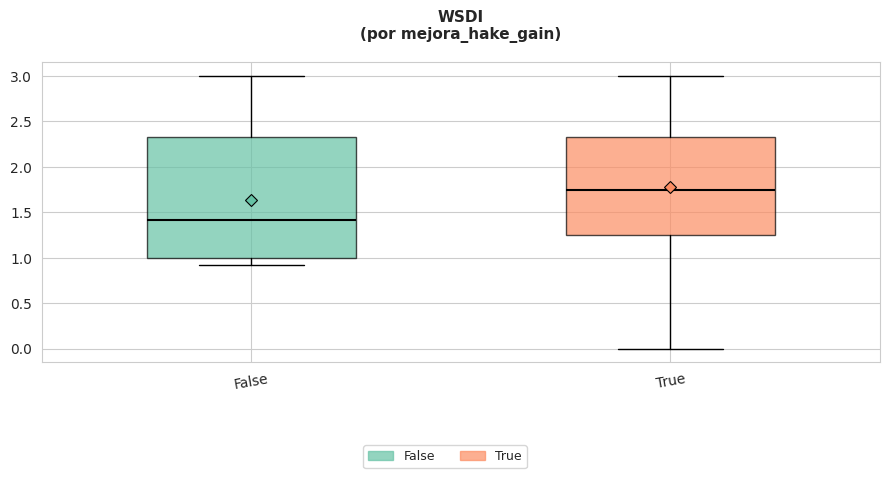

In [121]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['WSDI']
    ],
    group_by='mejora_hake_gain',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

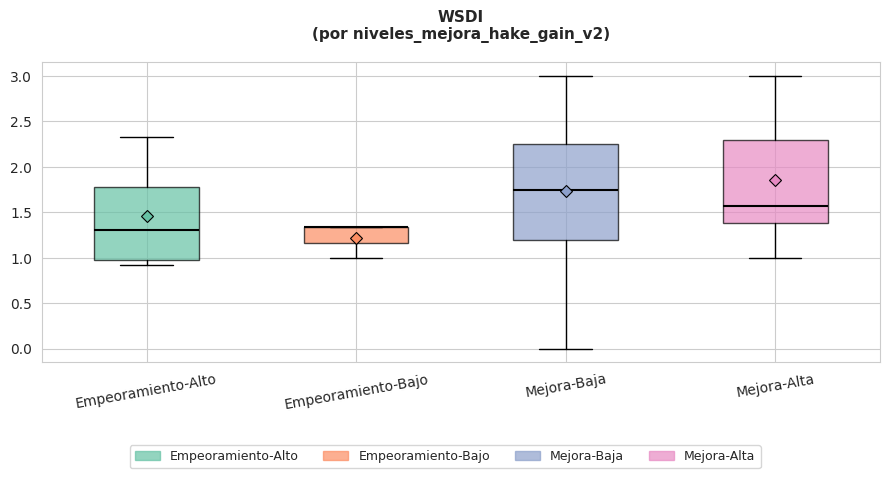

In [122]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['WSDI']
    ],
    group_by='niveles_mejora_hake_gain_v2',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    order=['Empeoramiento-Alto', 'Empeoramiento-Bajo', 'Mejora-Baja', 'Mejora-Alta']
)

- Correlacion positiva entre score de calidad de uso de la herramienta y ganancia de conocimientos (mejora/empeora)

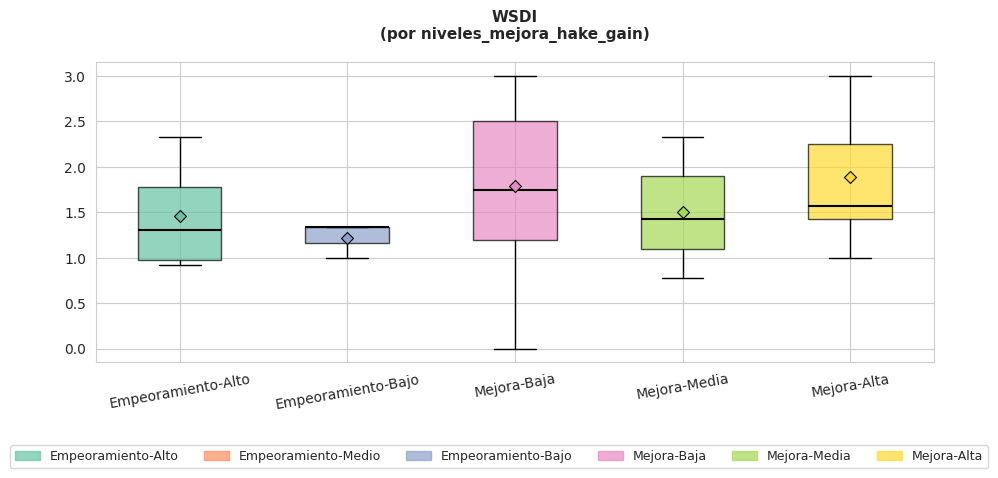

In [123]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['WSDI']
    ],
    group_by='niveles_mejora_hake_gain',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    order=['Empeoramiento-Alto', 'Empeoramiento-Medio', 'Empeoramiento-Bajo', 'Mejora-Baja', 'Mejora-Media', 'Mejora-Alta']
)

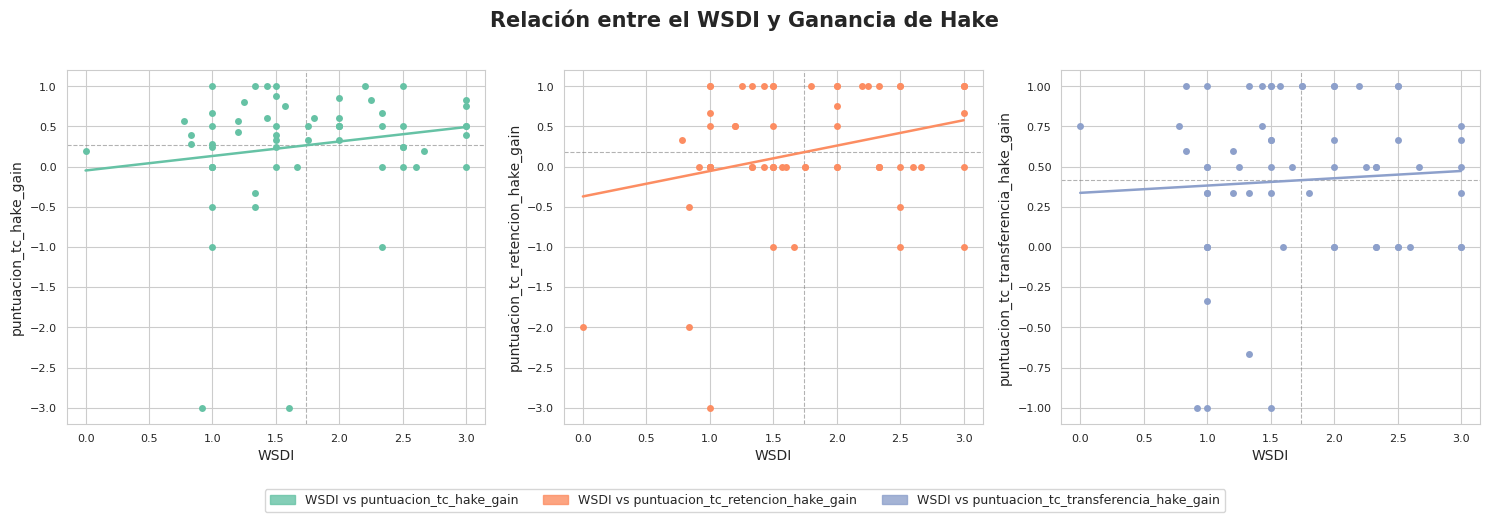

In [124]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title="Relación entre el WSDI y Ganancia de Hake",
    subplots_title=False
)

- El buen uso del chat correlaciona positivamente con las ganancias de conocimiento de tipo retención más que tranferencia. Esto cuadra con el hecho observado (AUNQUE AÚN NO MEDIDO, ES UN TODO) de que en el tipo de uso del chat predominate es el tipo retencion (preguntas tipo "que es la mediana") que tranferencia ("calcula la mediana de los salarios de una empresa X").

TO DO: metrica de tipo de interacción con el chat (retención / transferencia)

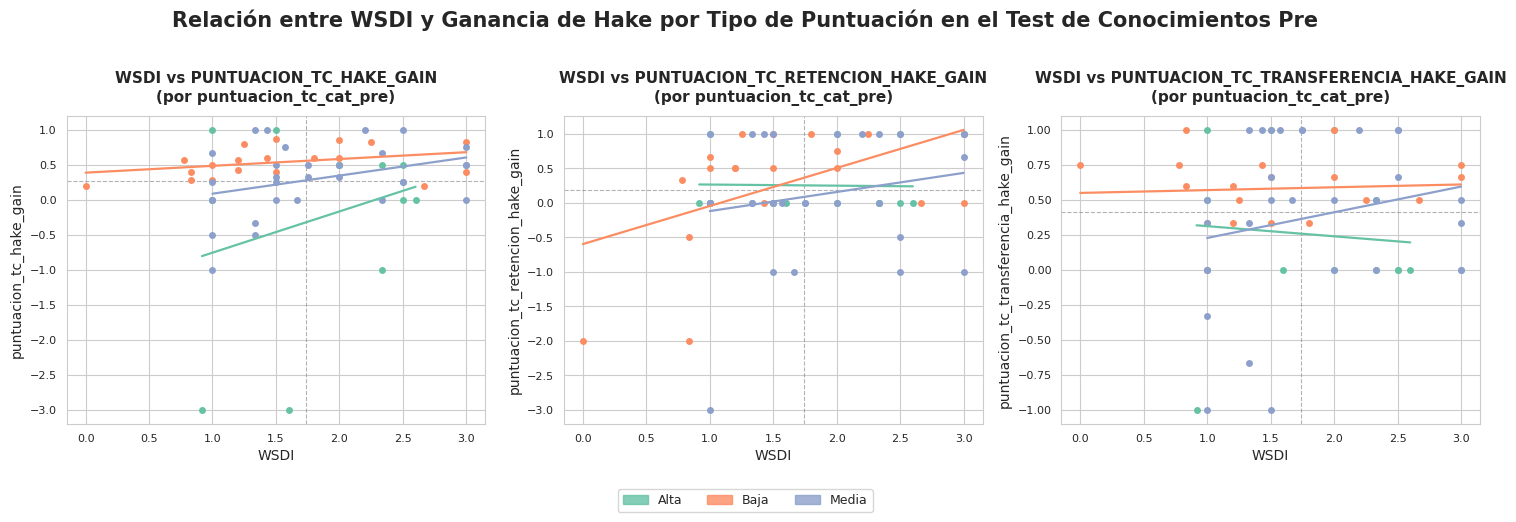

In [125]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    title="Relación entre WSDI y Ganancia de Hake por Tipo de Puntuación en el Test de Conocimientos Pre",
    group_by='puntuacion_tc_cat_pre'
)

- El efecto de usar bien la herramienta es mayor en los usuarios con cocimiento previo menor, más significativo en retención.



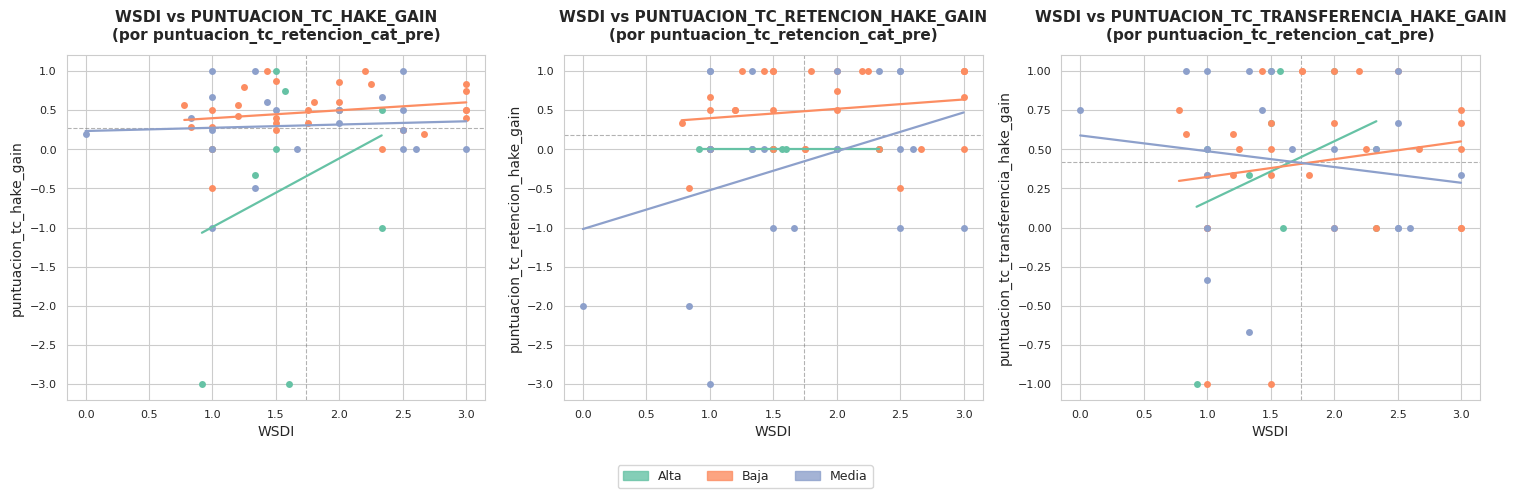

In [126]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    group_by='puntuacion_tc_retencion_cat_pre'
)

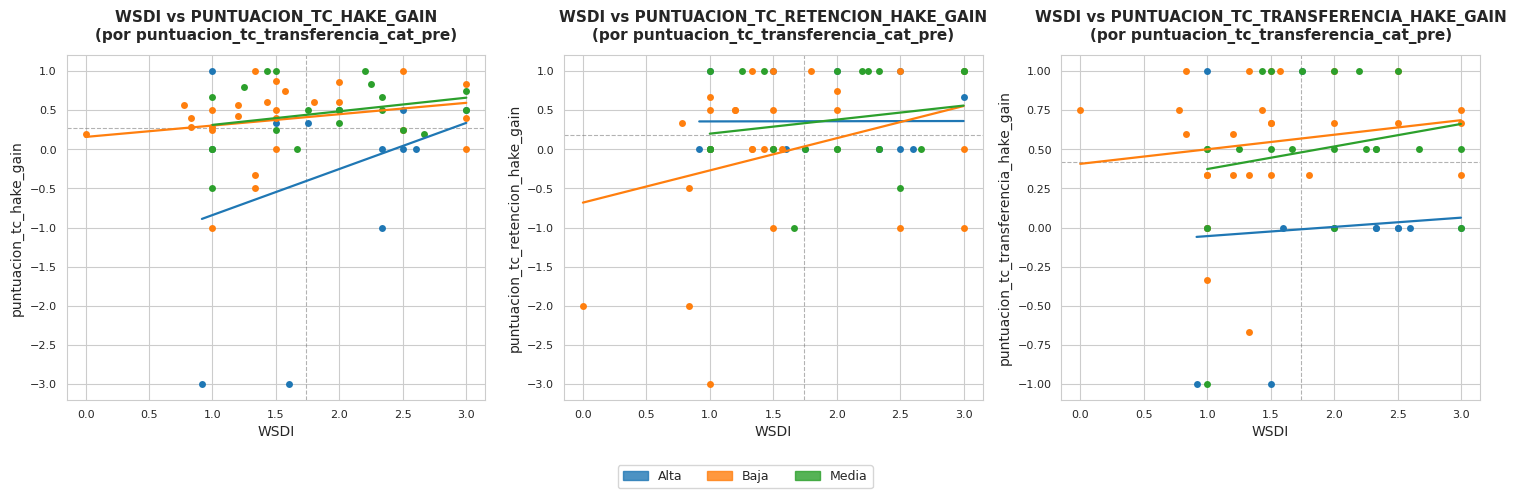

In [127]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    alpha=1,
    palette='tab10',
    bbox_to_anchor=(0.5, -0.11),
    group_by='puntuacion_tc_transferencia_cat_pre'
)

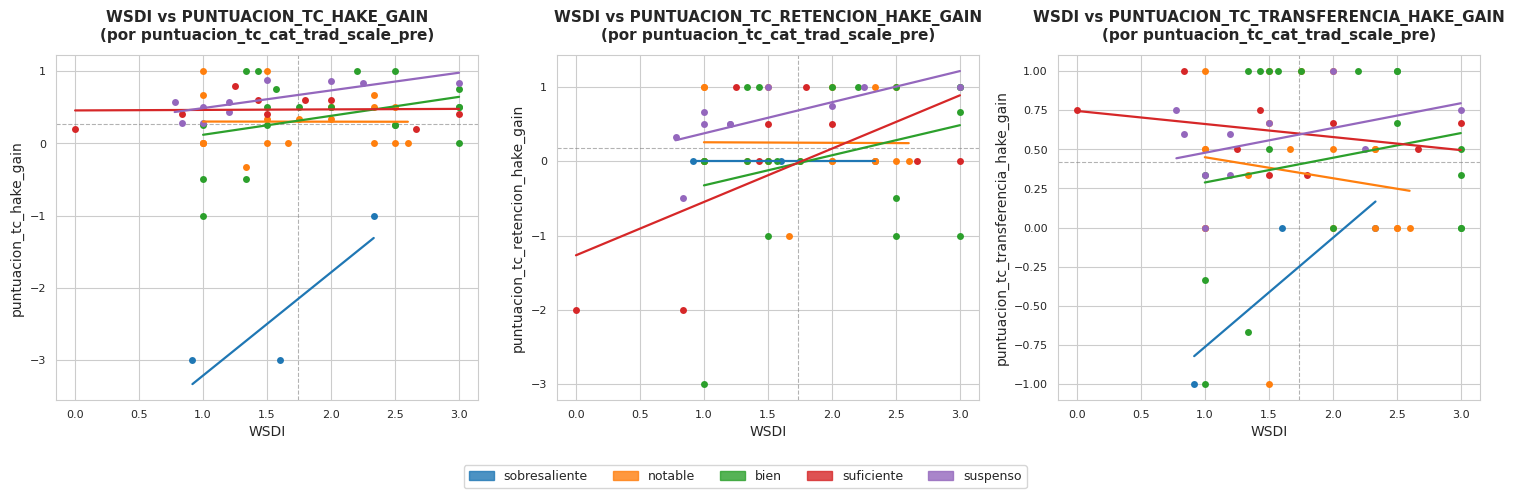

In [128]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    group_by='puntuacion_tc_cat_trad_scale_pre',
    order=['sobresaliente', 'notable', 'bien', 'suficiente', 'suspenso'],
)

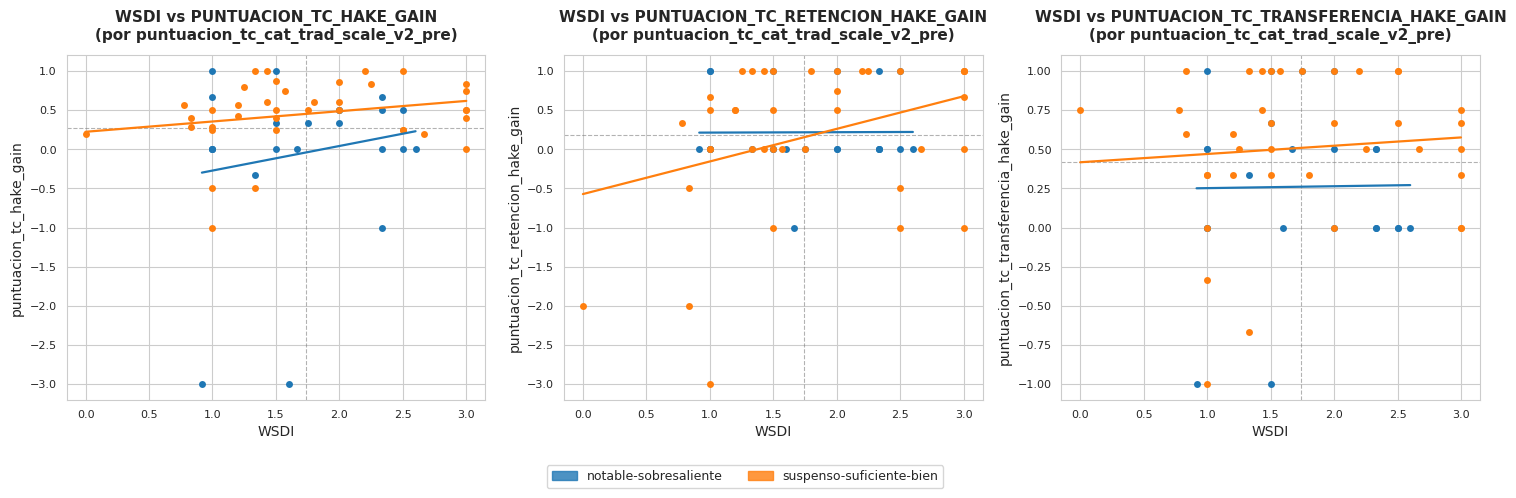

In [129]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    group_by='puntuacion_tc_cat_trad_scale_v2_pre'
)

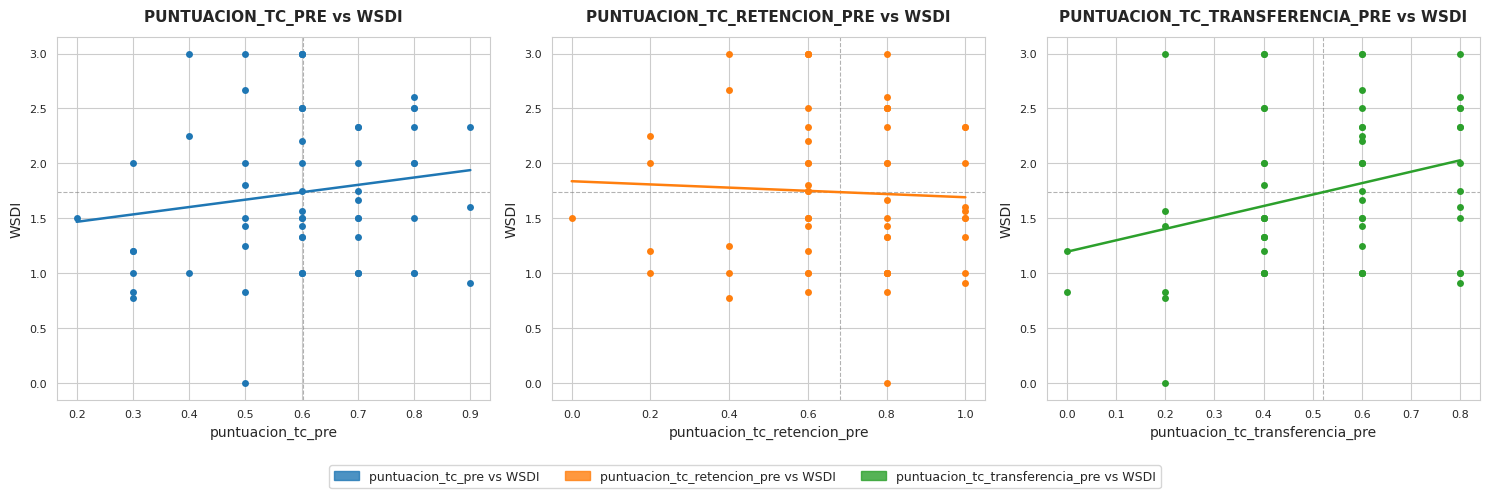

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("puntuacion_tc_pre", "WSDI"), 
                 ("puntuacion_tc_retencion_pre", "WSDI"),
                 ("puntuacion_tc_transferencia_pre", "WSDI")],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
)

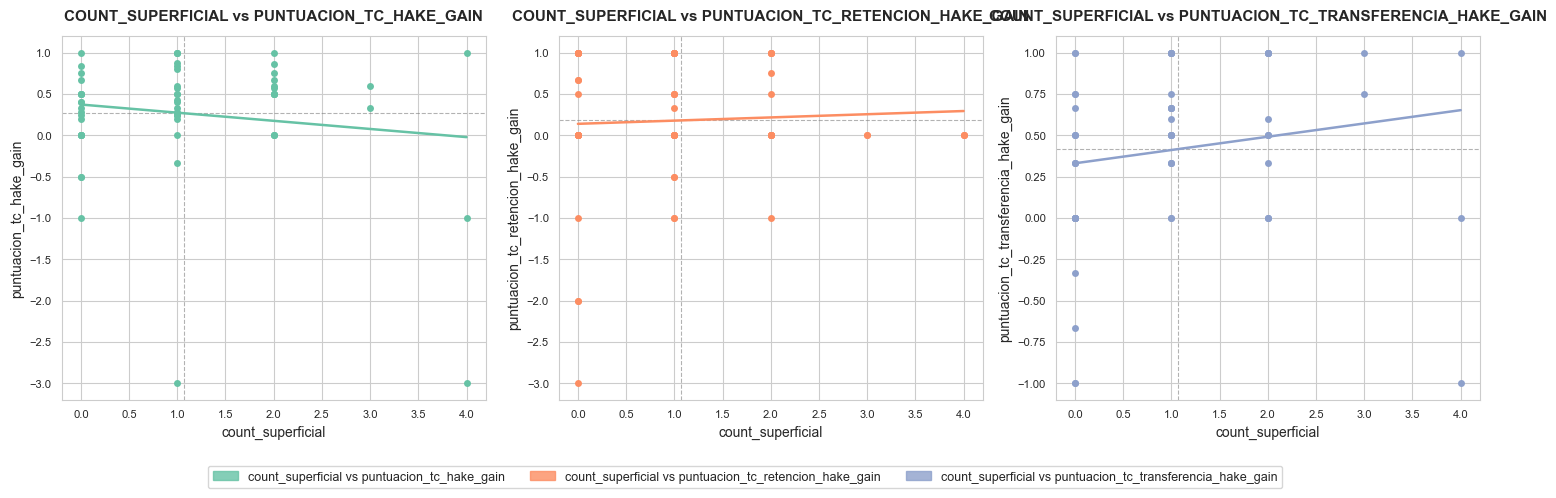

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("count_superficial", "puntuacion_tc_hake_gain"), 
                 ("count_superficial", "puntuacion_tc_retencion_hake_gain"),
                 ("count_superficial", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11)
)

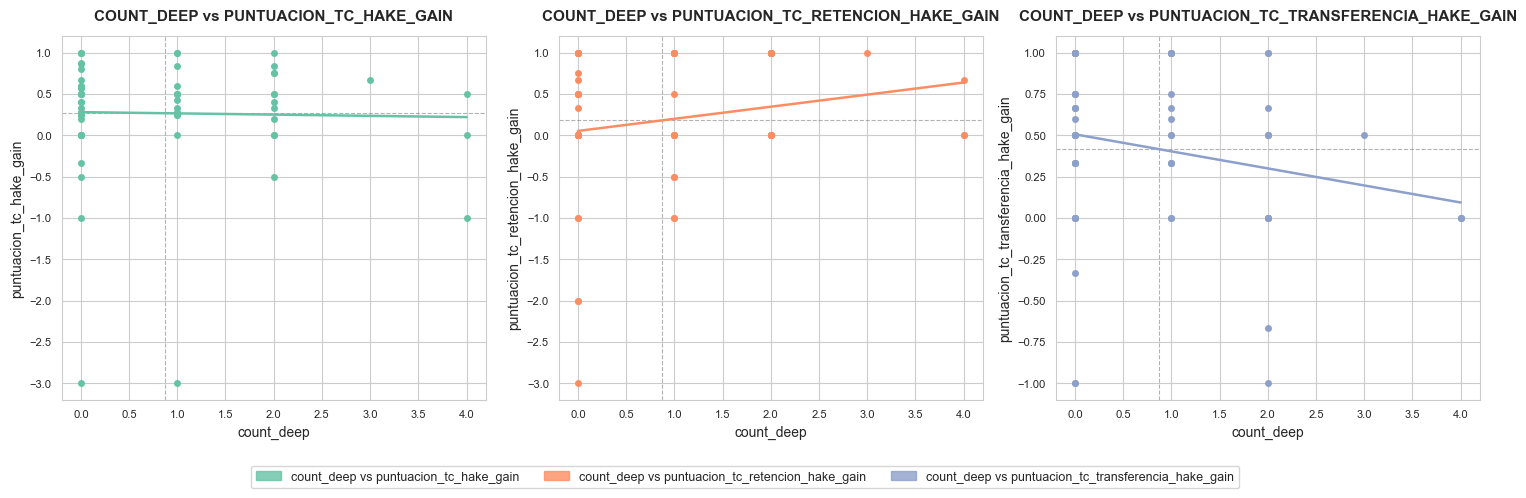

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("count_deep", "puntuacion_tc_hake_gain"), 
                 ("count_deep", "puntuacion_tc_retencion_hake_gain"),
                 ("count_deep", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11)
)

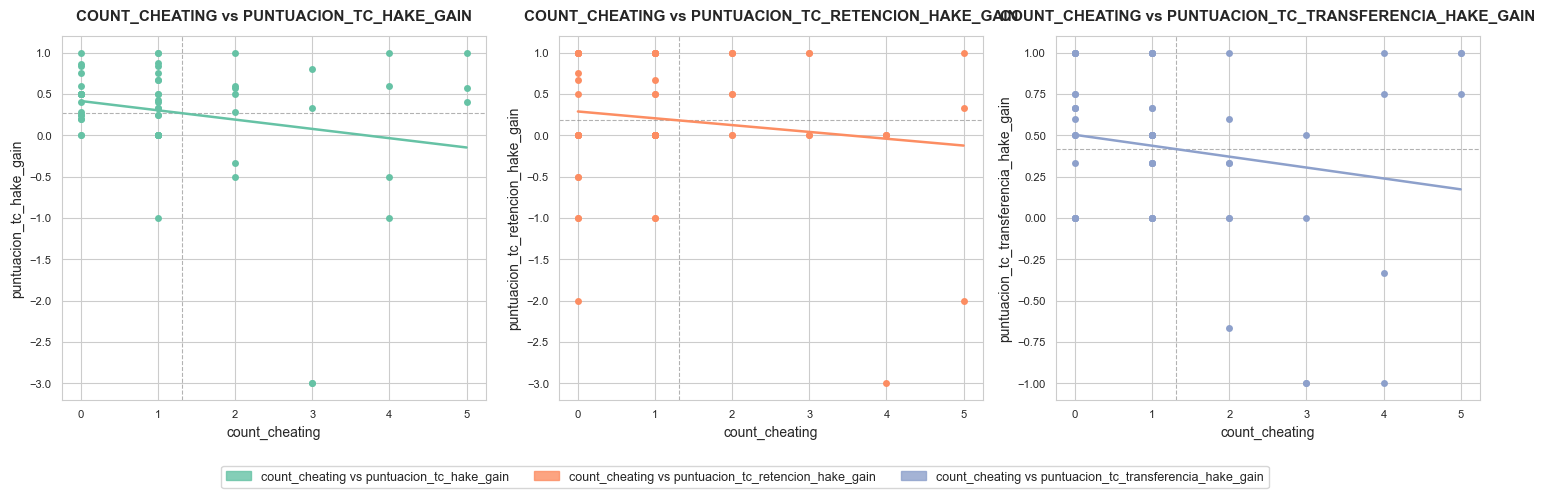

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("count_cheating", "puntuacion_tc_hake_gain"), 
                 ("count_cheating", "puntuacion_tc_retencion_hake_gain"),
                 ("count_cheating", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11)
)

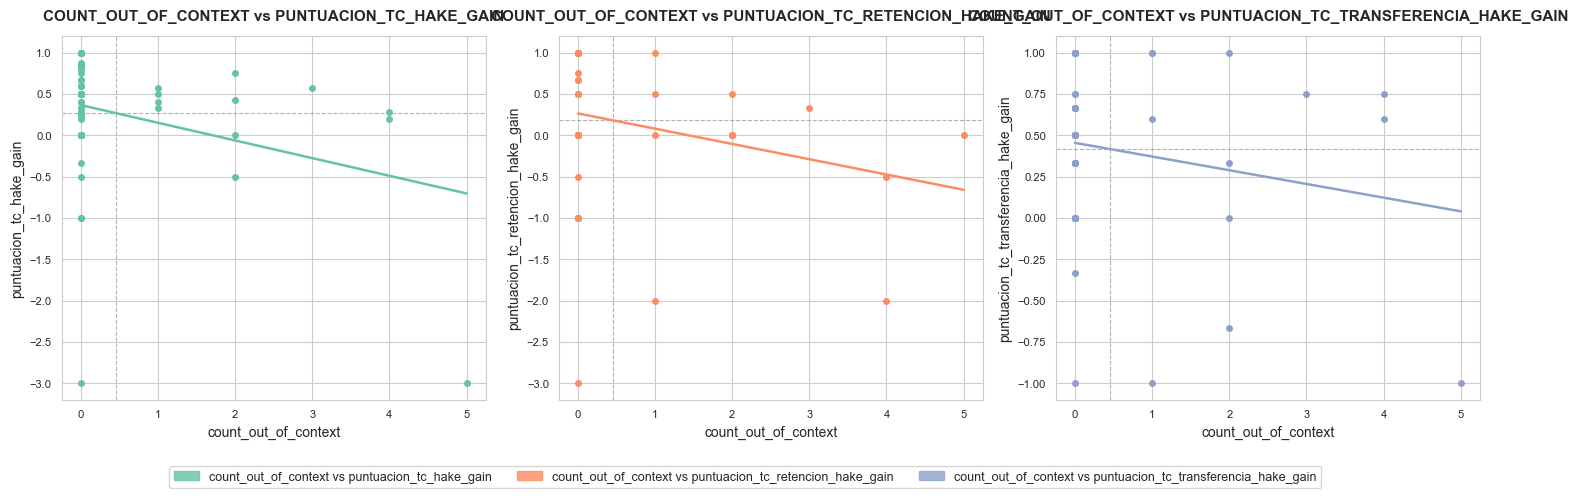

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("count_out_of_context", "puntuacion_tc_hake_gain"), 
                 ("count_out_of_context", "puntuacion_tc_retencion_hake_gain"),
                 ("count_out_of_context", "puntuacion_tc_transferencia_hake_gain")],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11)
)

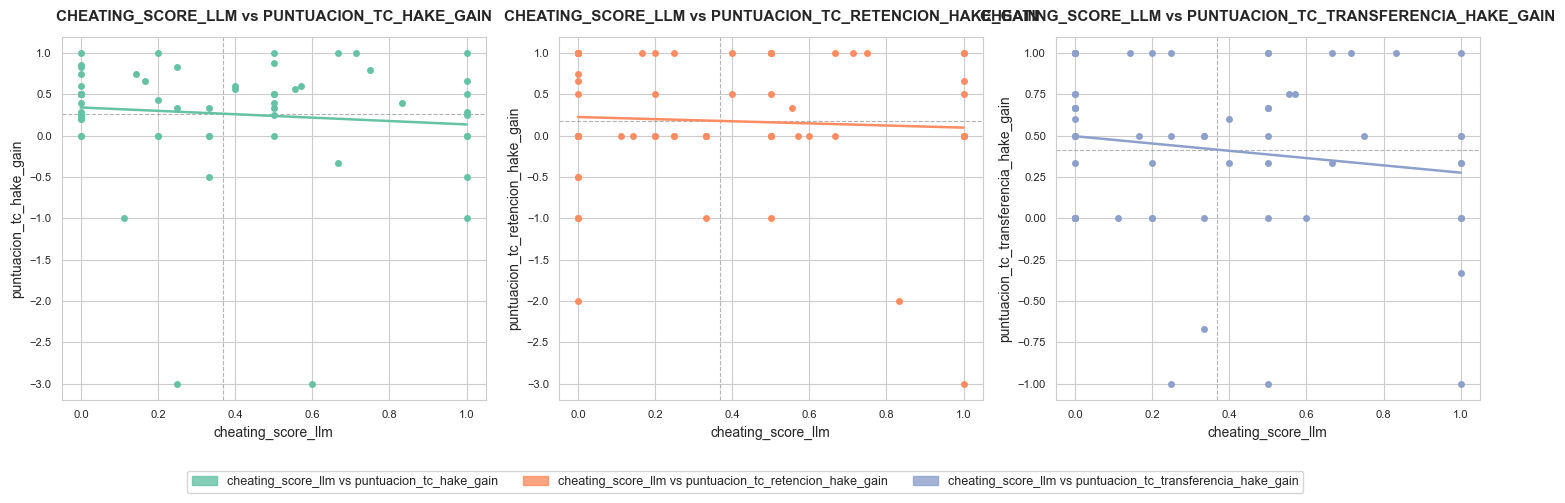

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("cheating_score_llm", "puntuacion_tc_hake_gain"),
        ("cheating_score_llm", "puntuacion_tc_retencion_hake_gain"),
        ("cheating_score_llm", "puntuacion_tc_transferencia_hake_gain"),
    ],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.12),    
)

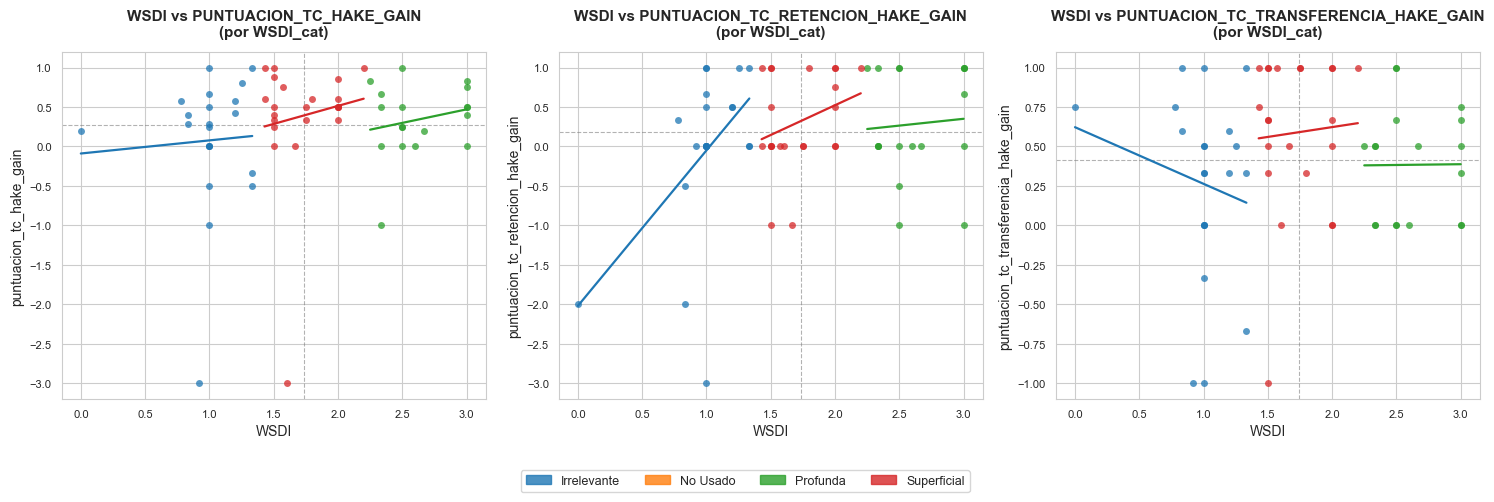

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="WSDI_cat",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

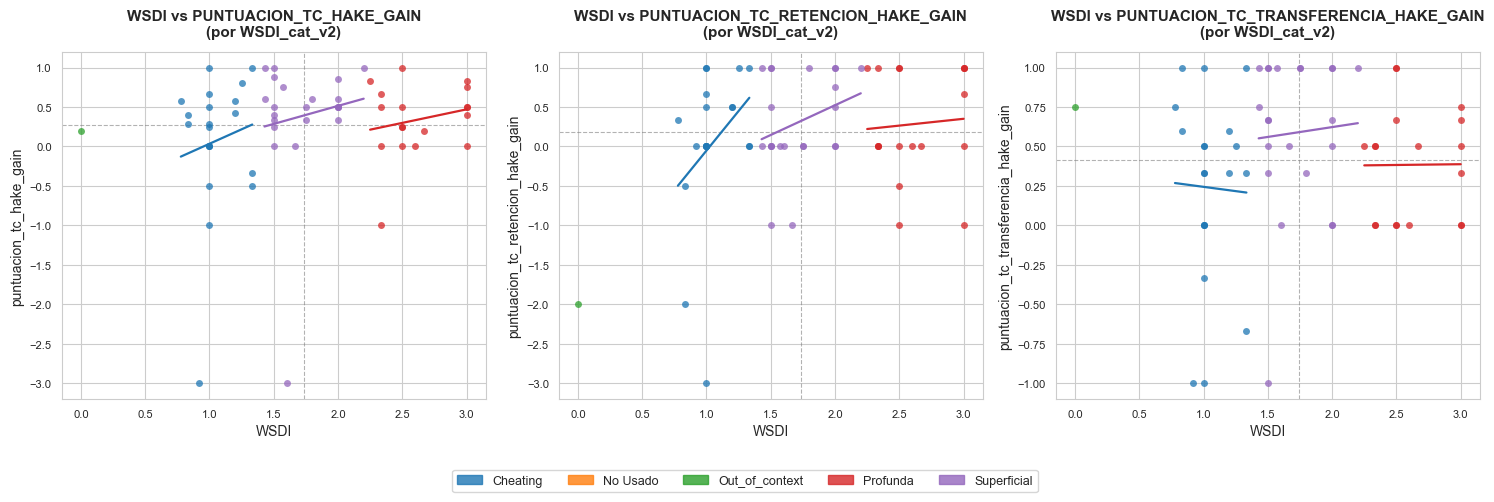

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="WSDI_cat_v2",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

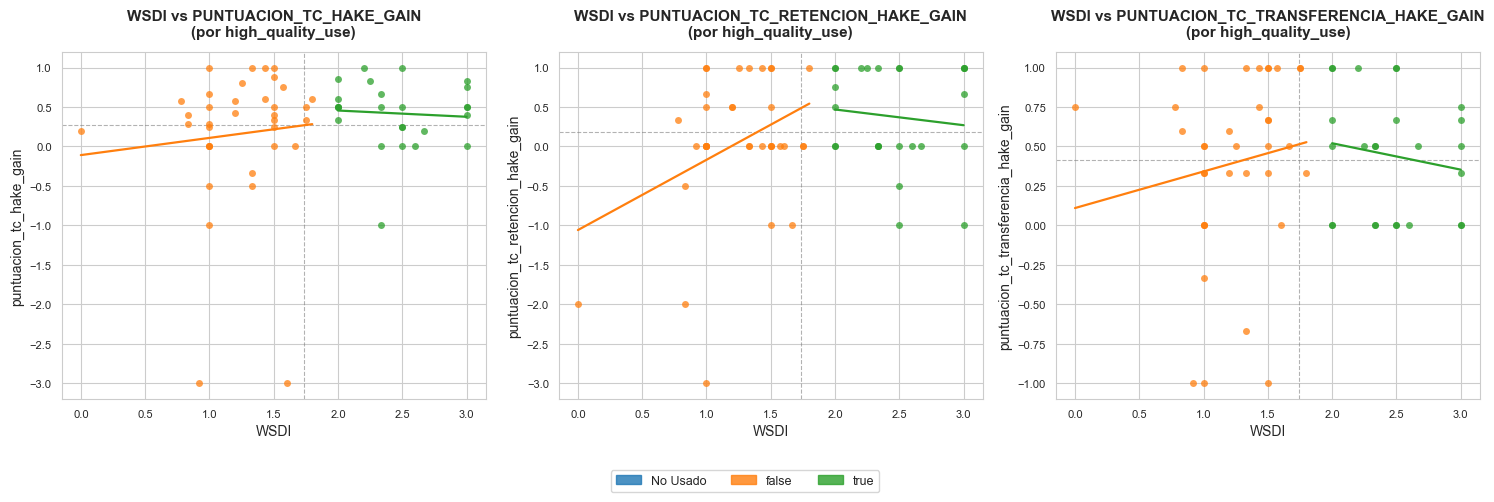

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="high_quality_use",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

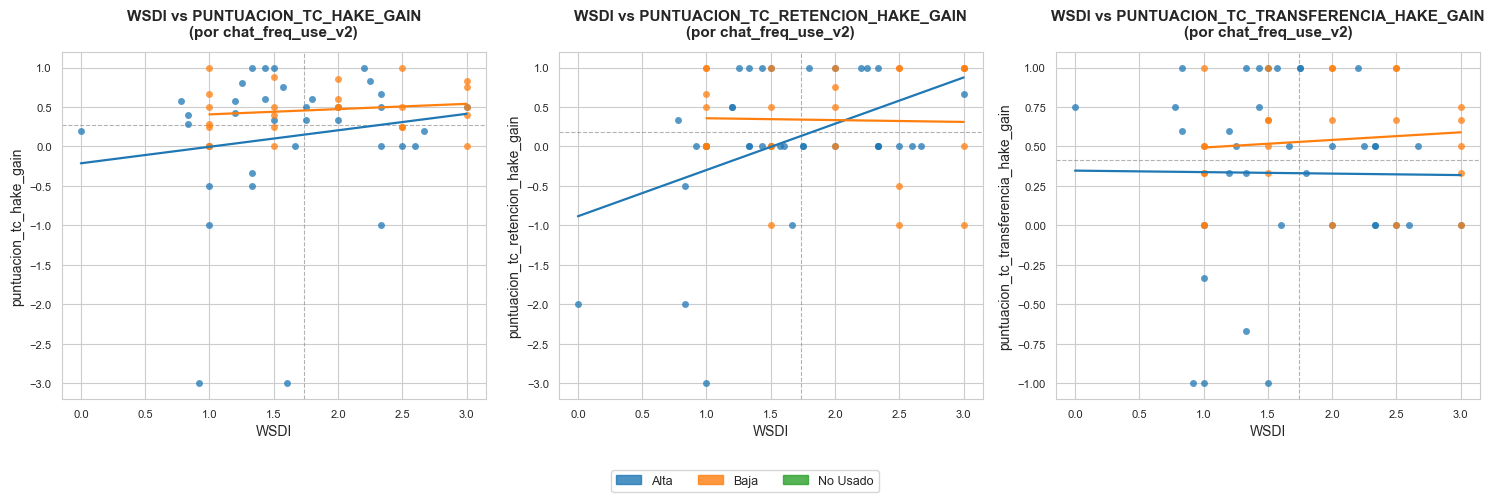

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="chat_freq_use_v2",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

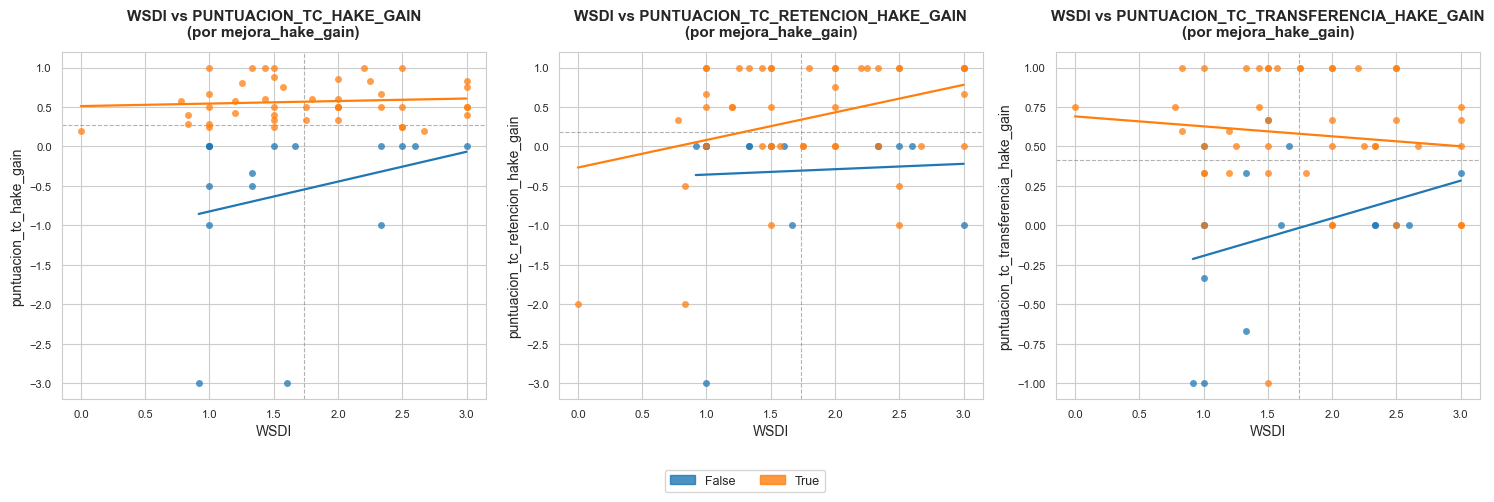

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="mejora_hake_gain",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

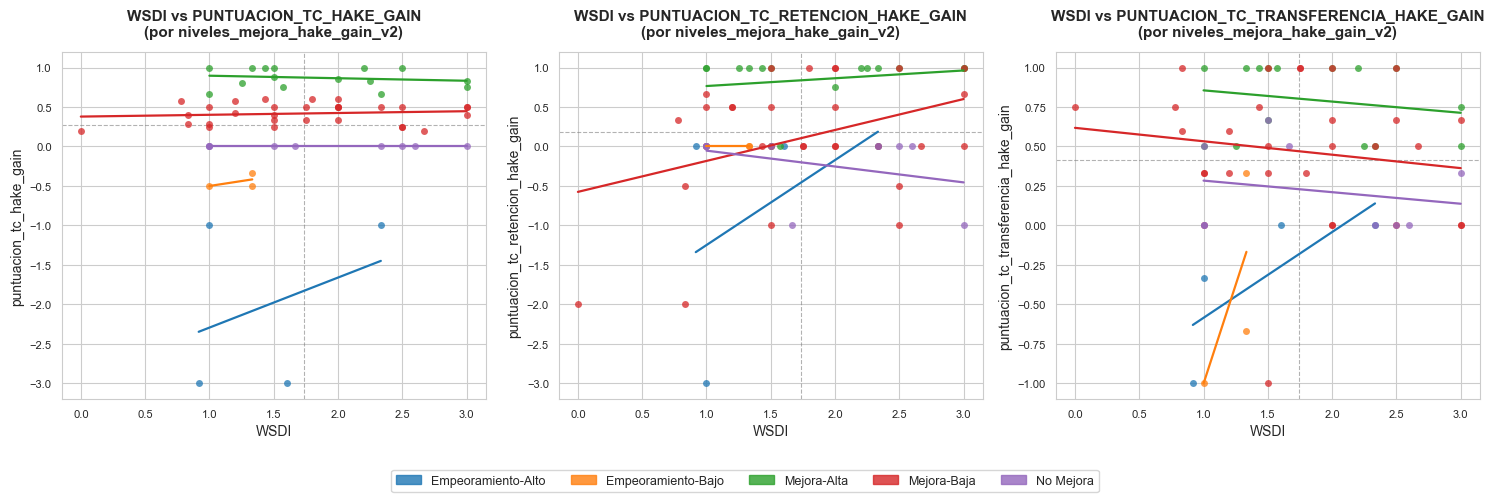

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="niveles_mejora_hake_gain_v2",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

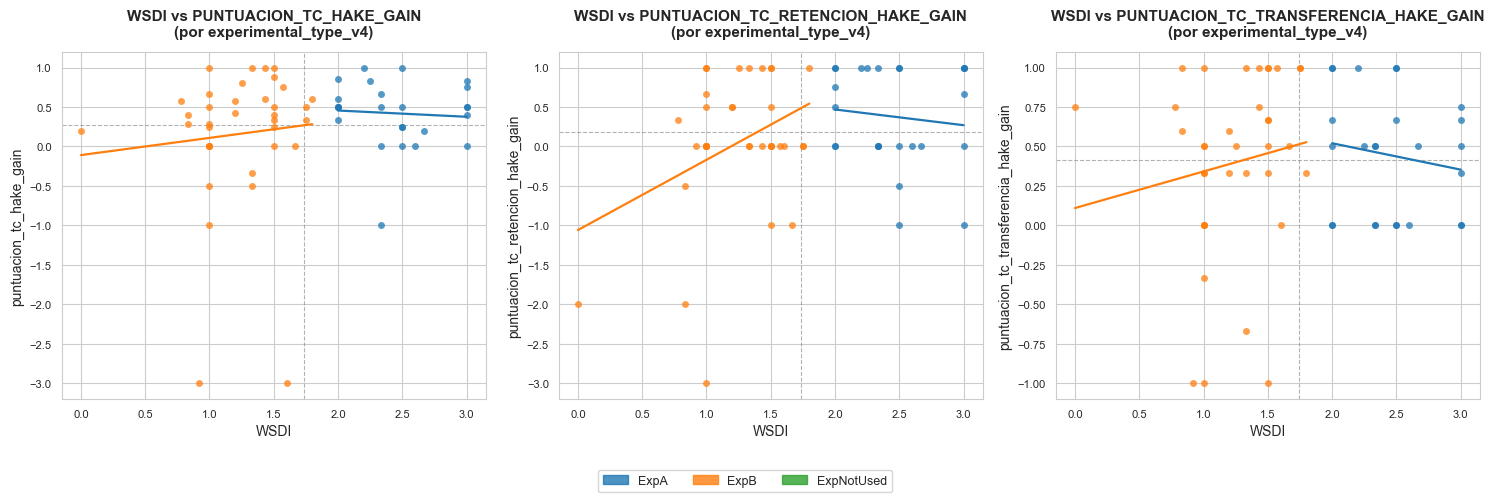

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="experimental_type_v4",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

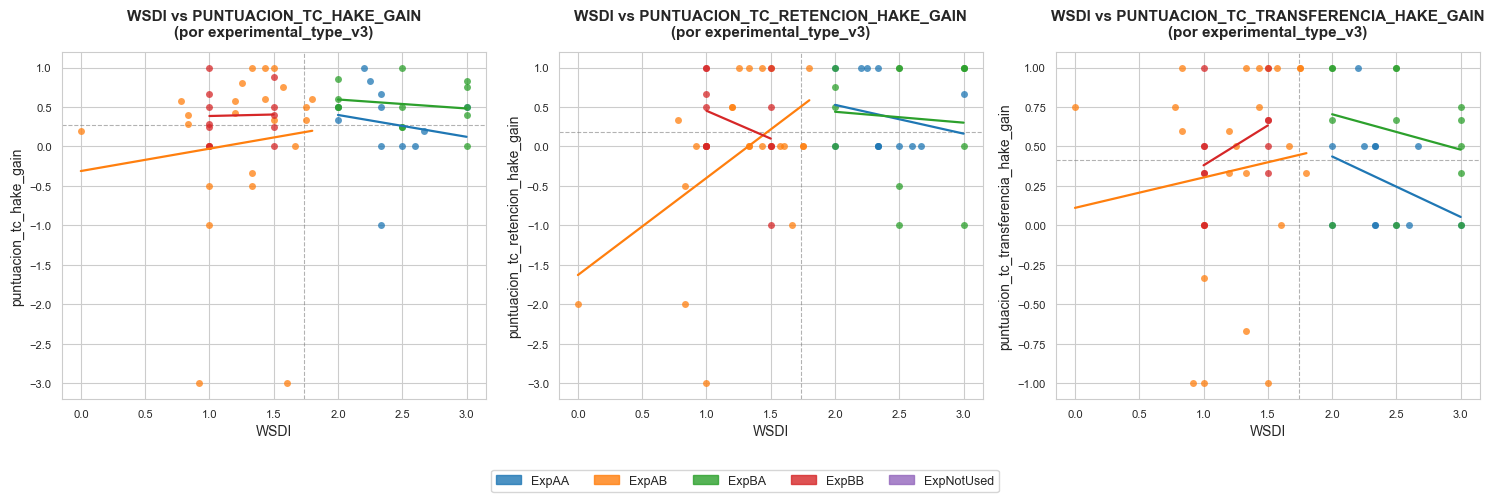

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="experimental_type_v3",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

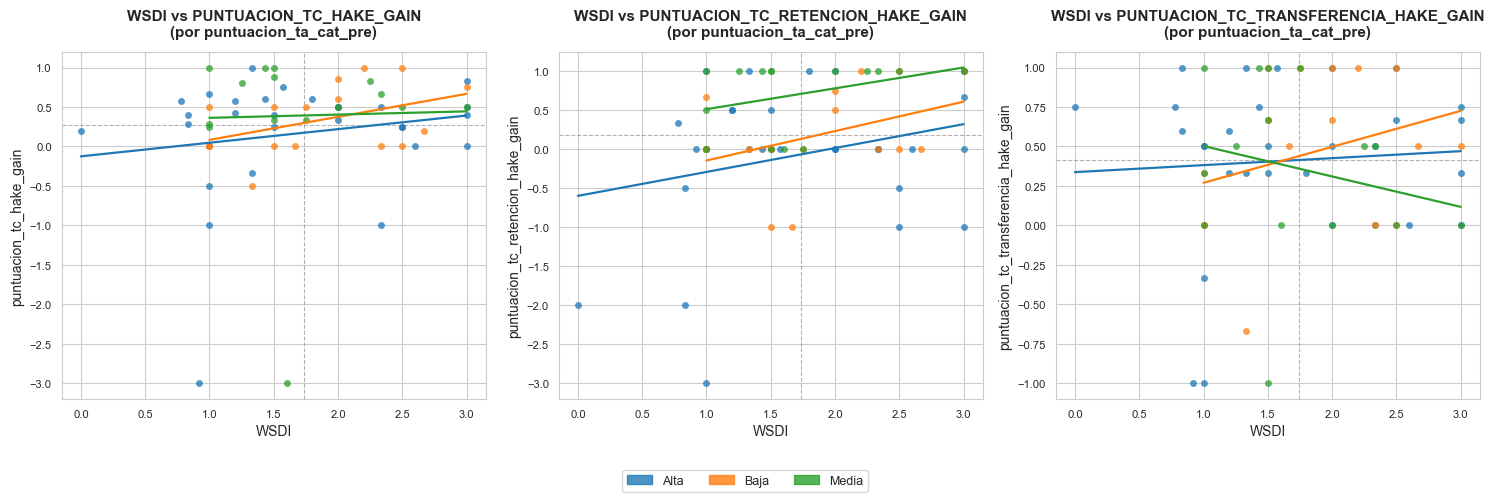

In [146]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="puntuacion_ta_cat_pre",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

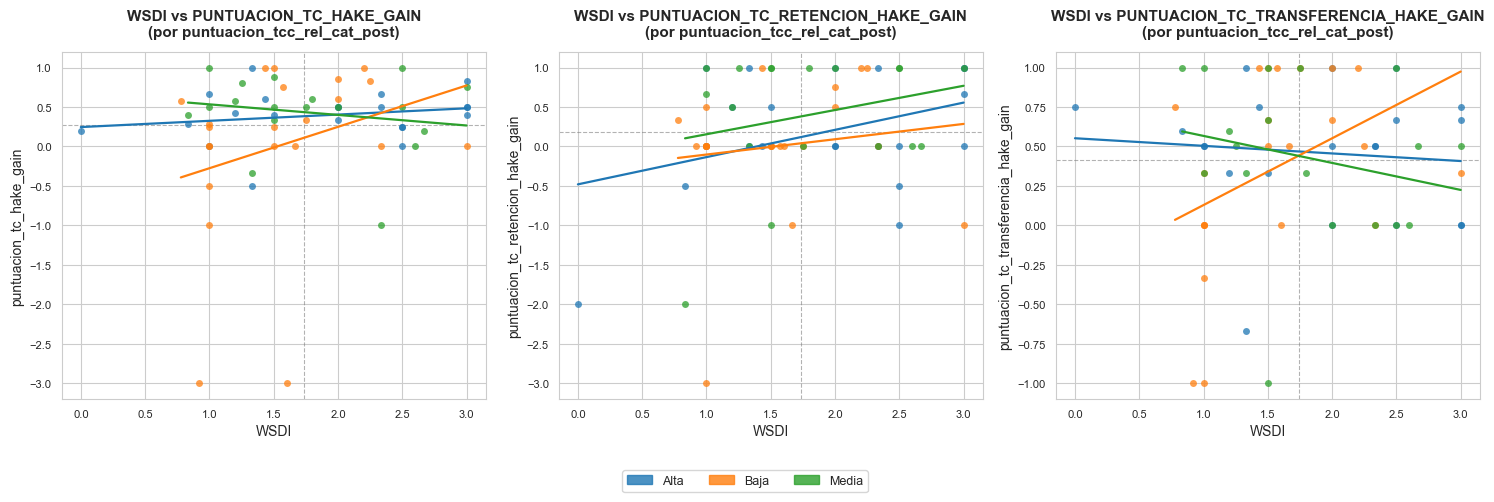

In [147]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="puntuacion_tcc_rel_cat_post",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

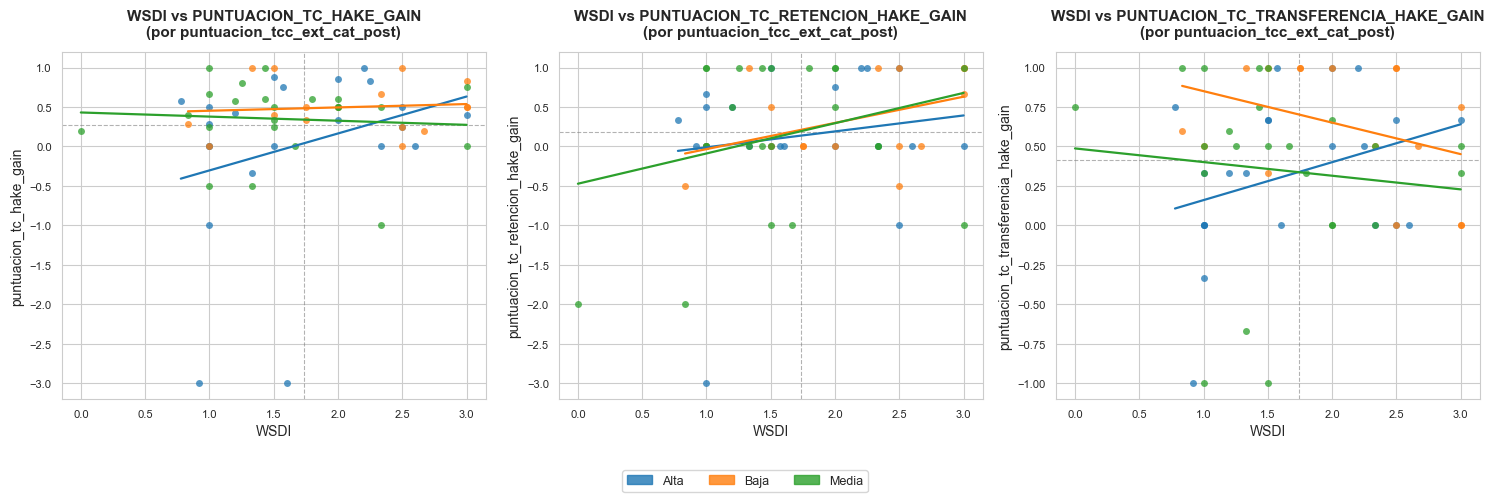

In [148]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="puntuacion_tcc_ext_cat_post",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

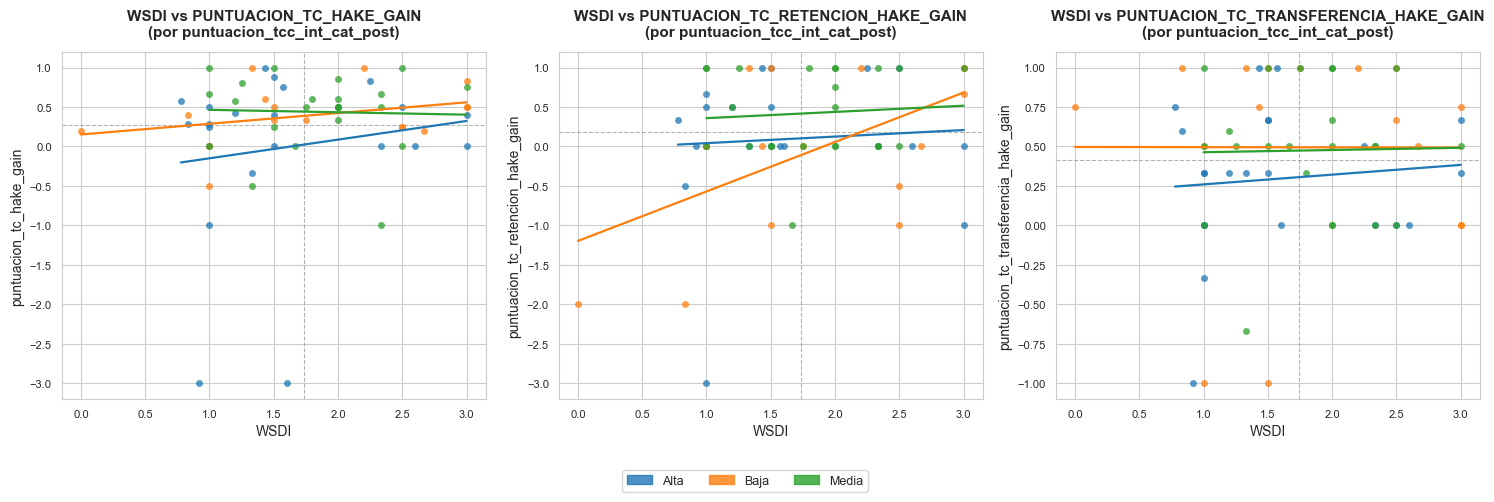

In [149]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[("WSDI", "puntuacion_tc_hake_gain"), 
                 ("WSDI", "puntuacion_tc_retencion_hake_gain"),
                 ("WSDI", "puntuacion_tc_transferencia_hake_gain")],
    group_by="puntuacion_tcc_int_cat_post",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

#### Tiempos

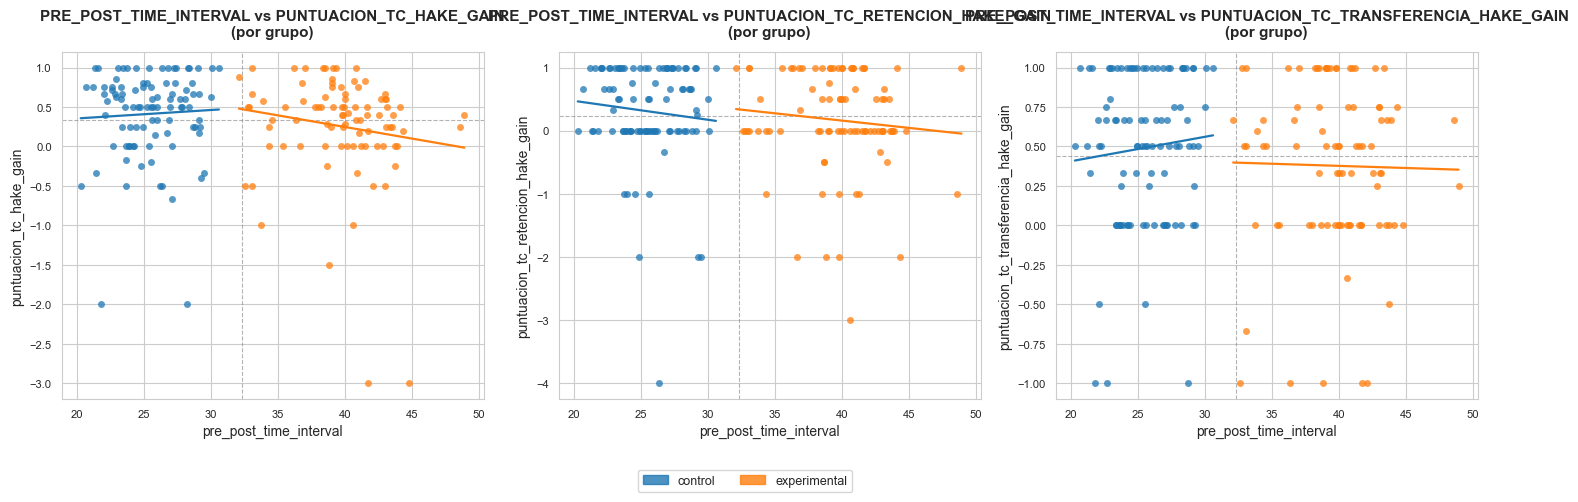

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("pre_post_time_interval", "puntuacion_tc_hake_gain"),
        ("pre_post_time_interval", "puntuacion_tc_retencion_hake_gain"),
        ("pre_post_time_interval", "puntuacion_tc_transferencia_hake_gain"),
    ],
    group_by="grupo",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

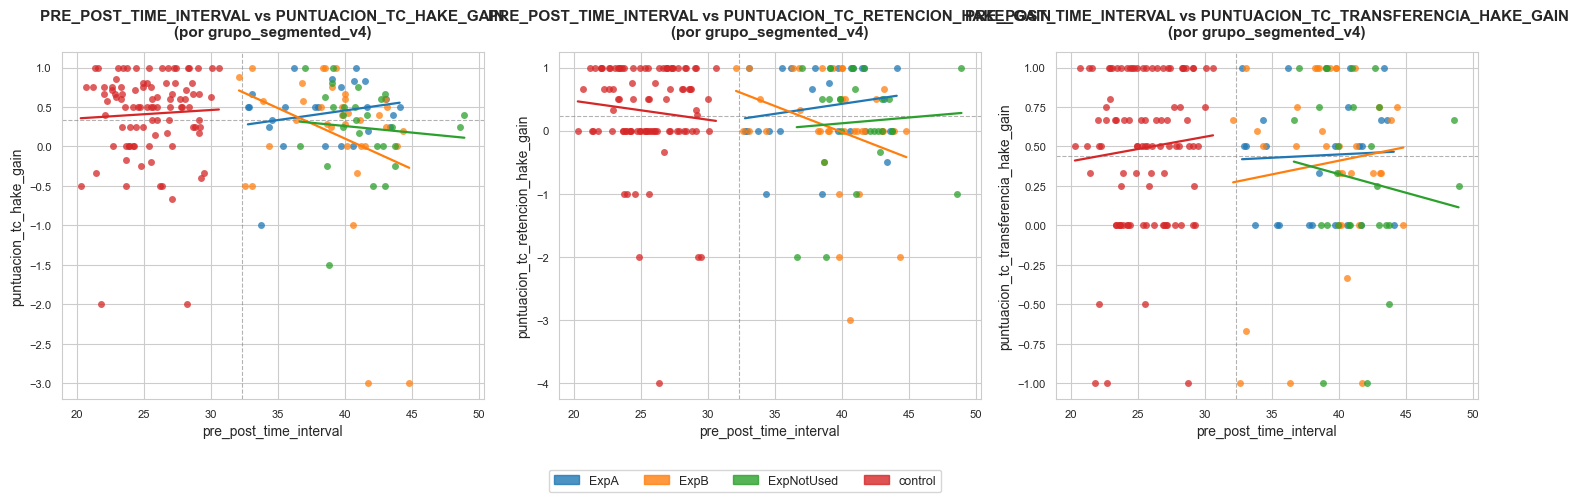

In [151]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("pre_post_time_interval", "puntuacion_tc_hake_gain"),
        ("pre_post_time_interval", "puntuacion_tc_retencion_hake_gain"),
        ("pre_post_time_interval", "puntuacion_tc_transferencia_hake_gain"),
    ],
    group_by="grupo_segmented_v4",
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False
)

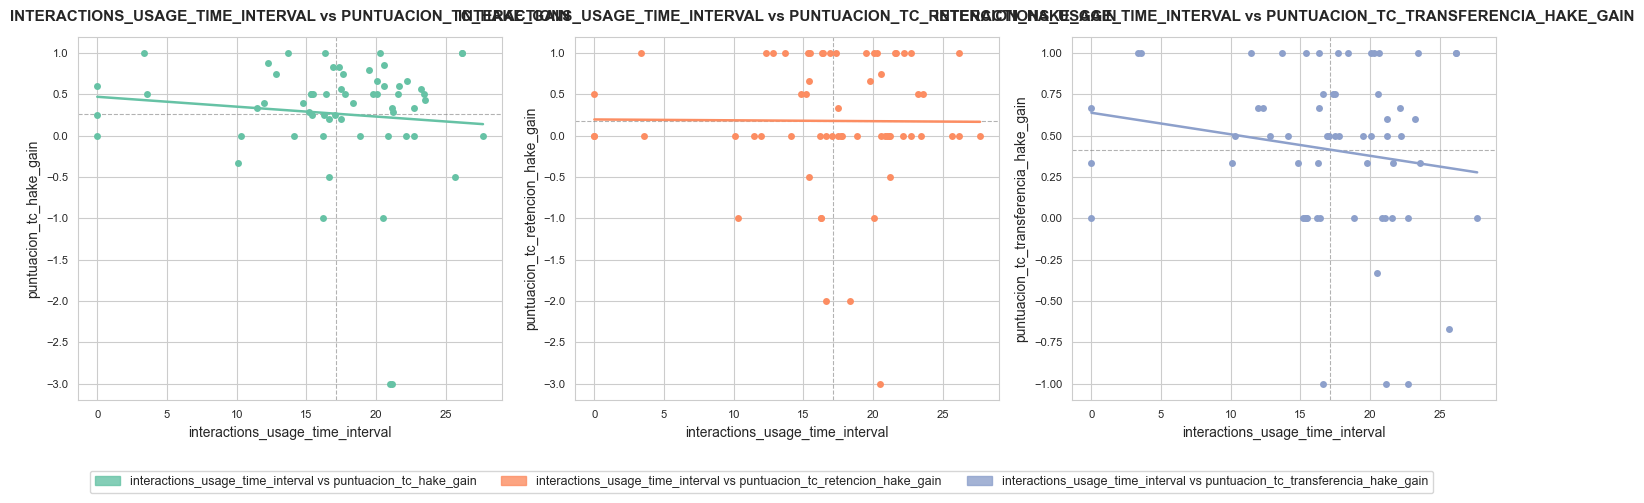

In [152]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("interactions_usage_time_interval", "puntuacion_tc_hake_gain"),
        ("interactions_usage_time_interval", "puntuacion_tc_retencion_hake_gain"),
        ("interactions_usage_time_interval", "puntuacion_tc_transferencia_hake_gain"),
    ],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.12),    
)

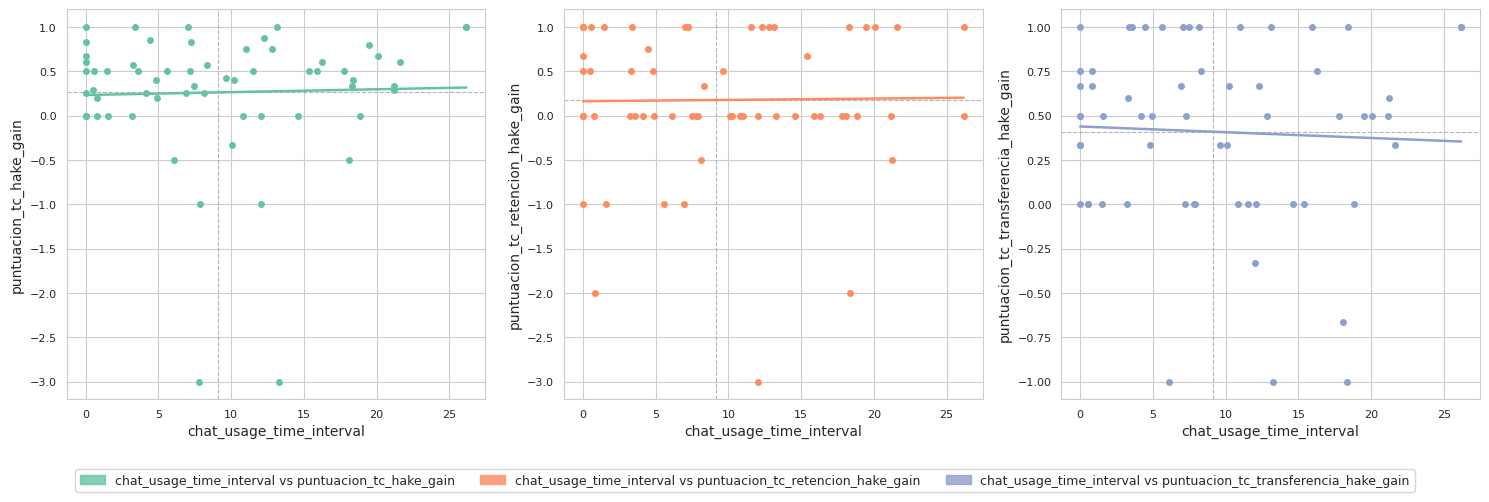

In [325]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("chat_usage_time_interval", "puntuacion_tc_hake_gain"),
        ("chat_usage_time_interval", "puntuacion_tc_retencion_hake_gain"),
        ("chat_usage_time_interval", "puntuacion_tc_transferencia_hake_gain"),
    ],
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.12),    
)

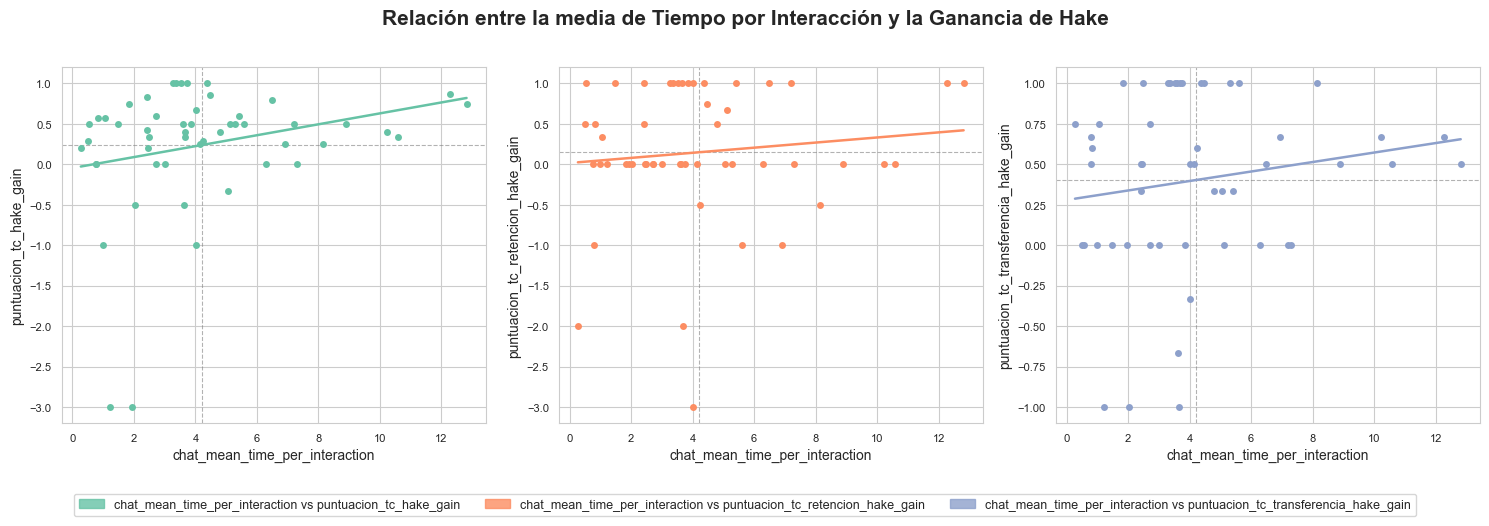

In [155]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("chat_mean_time_per_interaction", "puntuacion_tc_hake_gain"),
        ("chat_mean_time_per_interaction", "puntuacion_tc_retencion_hake_gain"),
        ("chat_mean_time_per_interaction", "puntuacion_tc_transferencia_hake_gain"),
    ],
    corr_annotation=False,
    title="Relación entre la media de Tiempo por Interacción y la Ganancia de Hake",
    subplots_title=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.12),    
)

- Cuanto más tiempo medio entre interacciones transcurre, mayor la ganancia de conocimiento. Este efecto se puede asociar a un mayor mantenimiento de la atención a lo largo de la vida del experimento.

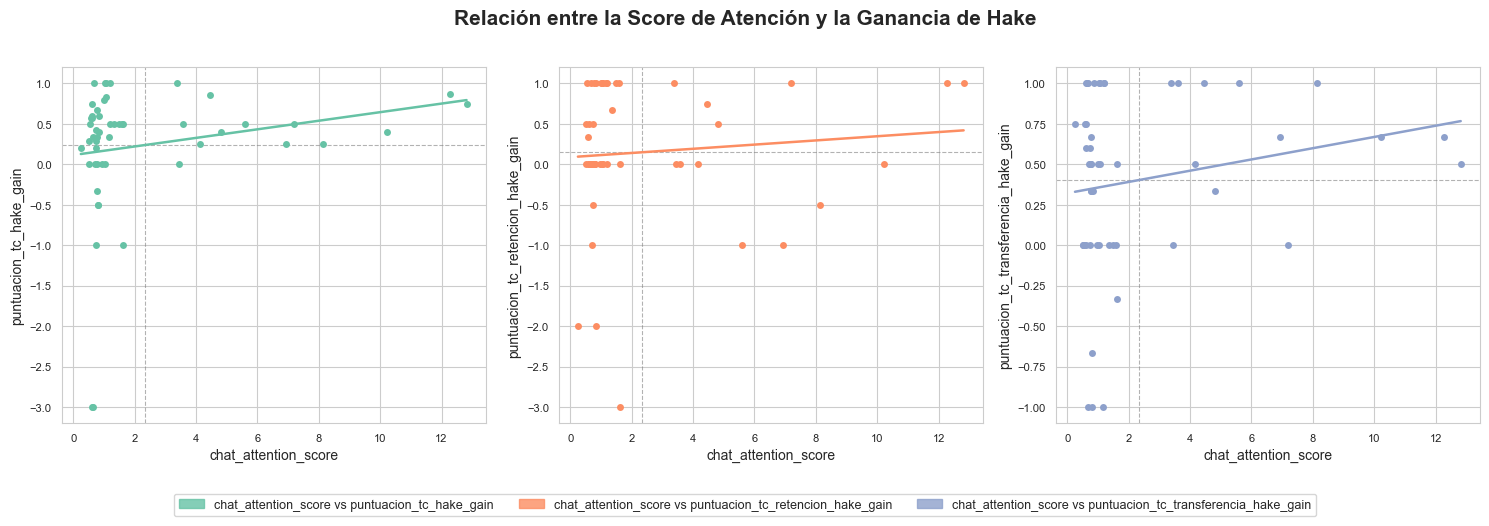

In [ ]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("tool_usage_score", "puntuacion_tc_hake_gain"),
        ("tool_usage_score", "puntuacion_tc_retencion_hake_gain"),
        ("tool_usage_score", "puntuacion_tc_transferencia_hake_gain"),
    ],
    corr_annotation=False,
    title="Relación entre la Score de Atención y la Ganancia de Hake",
    subplots_title=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.12),    
)

#### Score Uso Herramienta

In [ ]:
tool_usage_score_df = forms_interactions_df.filter(
    pl.col("tool_usage_score") > 0
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("tool_usage_score", "puntuacion_tc_hake_gain"),
        ("tool_usage_score", "puntuacion_tc_retencion_hake_gain"),
        ("tool_usage_score", "puntuacion_tc_transferencia_hake_gain"),
    ],
    corr_annotation=False,
    title="Relación entre la Score de Uso de la Herramienta y la Ganancia de Hake por Mejora",
    subplots_title=False,
    group_by="mejora_hake_gain",
    alpha=1,
    bbox_to_anchor=(0.5, -0.12),
)